Analyzing dataset: LDT Model 1
Dataset 1 shape: (104, 25)
Dataset 2 shape: (104, 25)
Using identifier column: ID
Merged data shape: (104, 15)
Using k values: [3, 5, 7, 10, 10] (data-driven k = 10)
Found 7 valid parameter pairs

Analyzing v1_mean across k values...
Parameters: v1_mean_s1 - v1_mean_s2, k=3
MI: 0.8320 bits (p=0.0010)
----------------------------------------
Parameters: v1_mean_s1 - v1_mean_s2, k=5
MI: 0.8416 bits (p=0.0010)
----------------------------------------
Parameters: v1_mean_s1 - v1_mean_s2, k=7
MI: 0.8047 bits (p=0.0010)
----------------------------------------
Parameters: v1_mean_s1 - v1_mean_s2, k=10
MI: 0.8547 bits (p=0.0010)
----------------------------------------
Parameters: v1_mean_s1 - v1_mean_s2, k=10
MI: 0.8547 bits (p=0.0010)
----------------------------------------
Correlation for v1_mean: r = 0.7454 (p=0.0000), R² = 0.5555

Analyzing v2_mean across k values...
Parameters: v2_mean_s1 - v2_mean_s2, k=3
MI: 1.0834 bits (p=0.0010)
----------------------

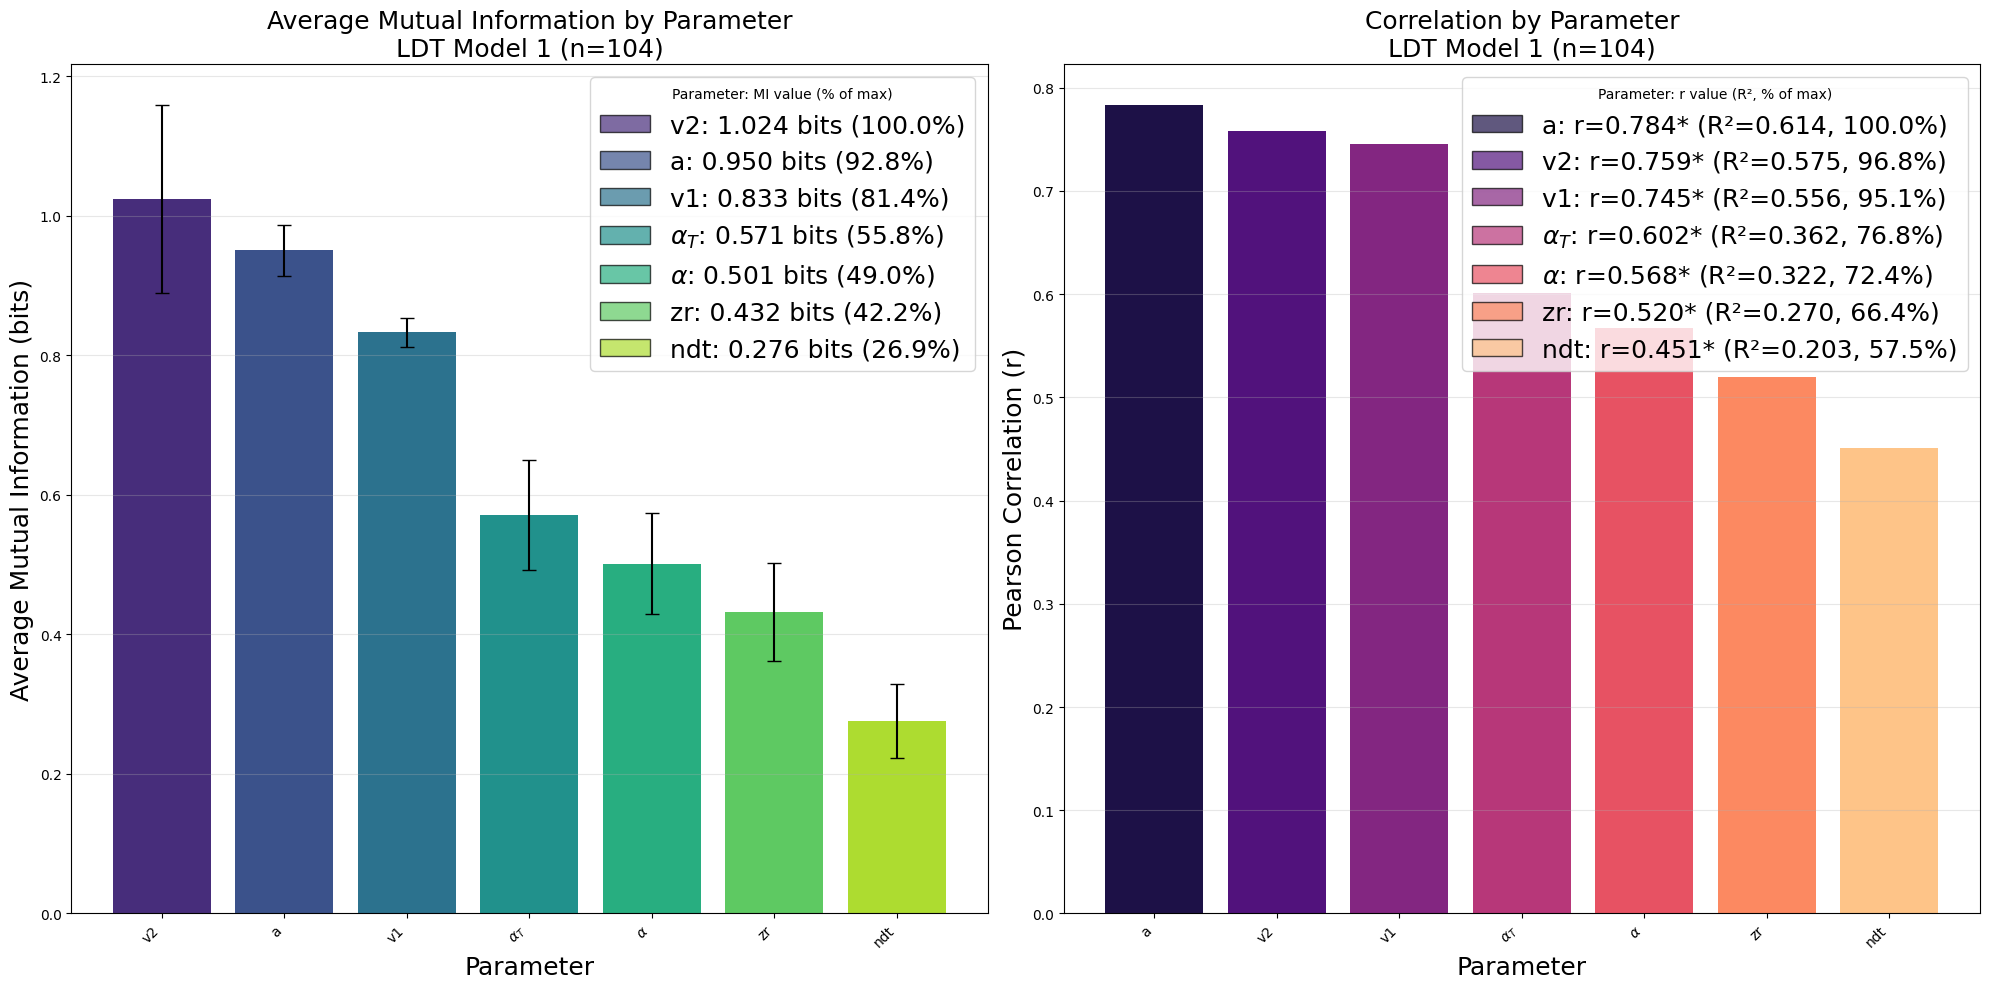


Comparison of MI and Correlation for LDT Model 1:


,Average MI (bits),MI Ratio (%),Correlation (r),R-squared,Corr Ratio (%),MI p-value,Corr p-value
v2_mean,1.024082,100.000000,0.758575,0.575436,96.794352,0.000999,1.093102e-20
a_mean,0.950280,92.793345,0.783697,0.614182,100.000000,0.000999,8.042086e-23
v1_mean,0.833231,81.363674,0.745350,0.555547,95.106900,0.000999,1.148280e-19
alpha_mean_boxcox_after_arcsin,0.570941,55.751524,0.601514,0.361820,76.753410,0.000999,1.453318e-11
alpha_mean,0.501407,48.961586,0.567702,0.322285,72.438866,0.000999,3.292098e-10
zr_mean,0.431789,42.163504,0.520040,0.270442,66.357249,0.000999,1.534525e-08
ndt_mean,0.275855,26.936758,0.450722,0.203151,57.512310,0.000999,1.576751e-06



Results exported to results_LDT_Model_1 directory


/var/folders/pp/fzhfbv9573q1s621tfds29800000gn/T/ipykernel_58448/2033374015.py:315: RuntimeWarning: divide by zero encountered in log
  theoretical_mi = -0.5 * np.log(1 - r_range**2) / np.log(2)


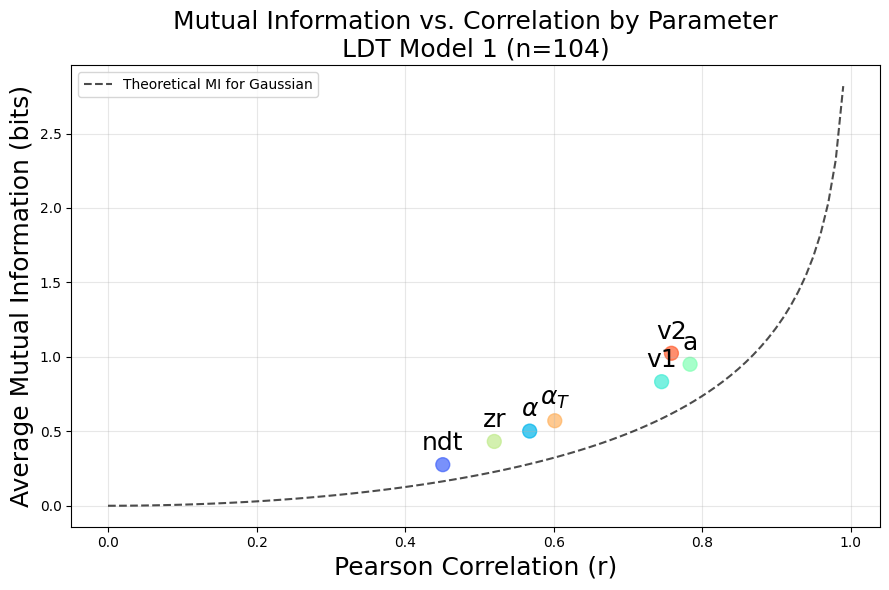

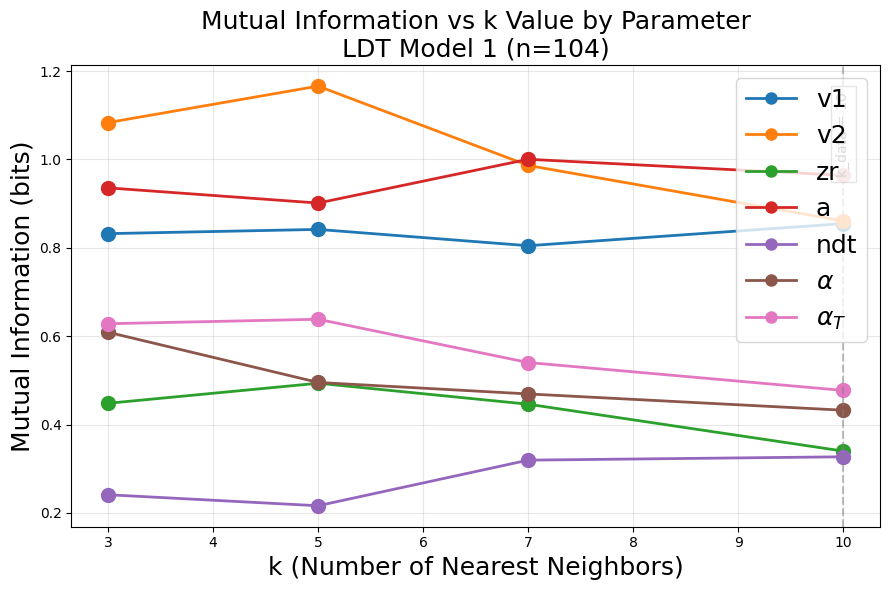

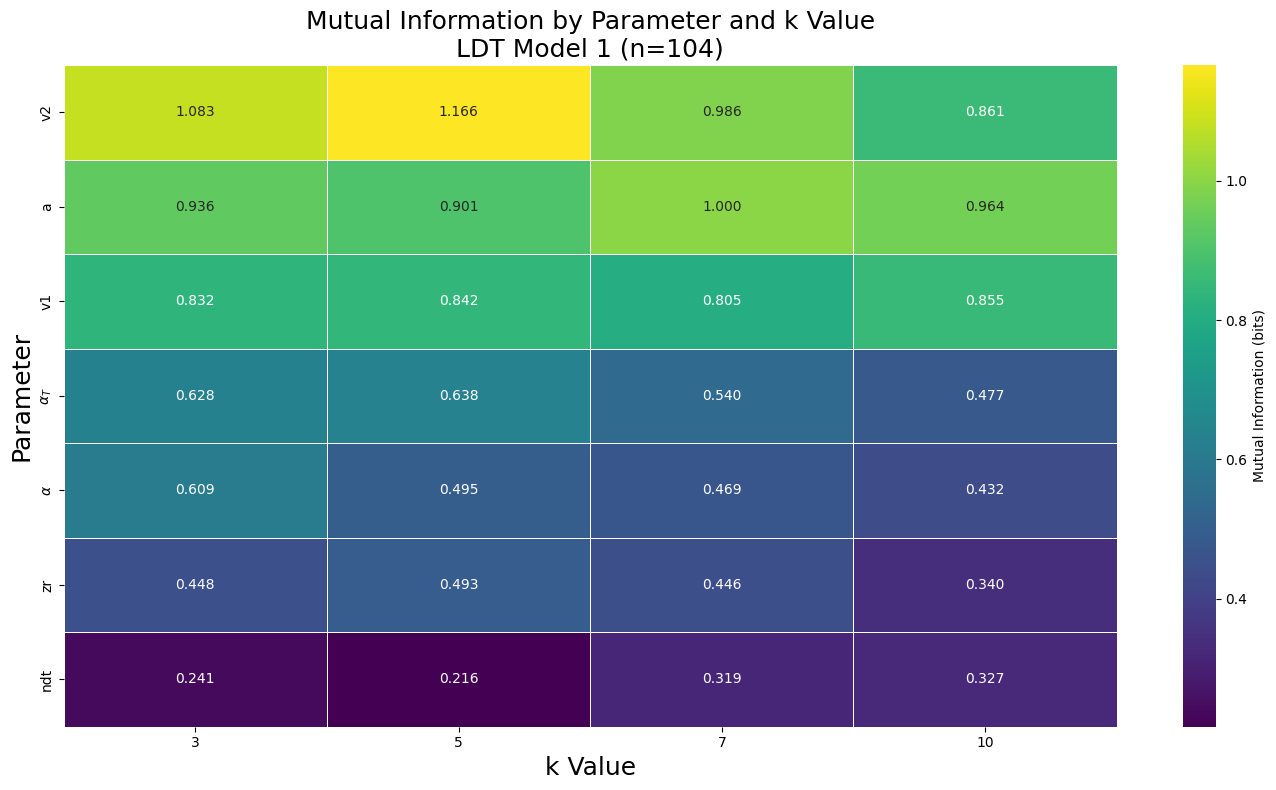

All analyses complete for LDT Model 1. Results saved to results_LDT_Model_1


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#plt.rcParams.update({'font.size': 16}) 

from matplotlib.patches import Patch
from KSG_MI_First_reliability import KSGMutualInformationAnalyzer
from scipy import stats
import os

Data_Name = "LDT Model 1"

# Define paths to your data files
session1_path = 'Model1 LDT RMT/ldt_session_1_data_transformed.csv'
session2_path = 'Model1 LDT RMT/ldt_session_2_data_transformed.csv'

# Create a clean name for file paths (replace spaces with underscores)
file_name_prefix = Data_Name.replace(' ', '_')

# Create output directory
output_dir = f"results_{file_name_prefix}"
os.makedirs(output_dir, exist_ok=True)

# Read the CSV files
df1 = pd.read_csv(session1_path)
df2 = pd.read_csv(session2_path)

print(f"Analyzing dataset: {Data_Name}")
print("Dataset 1 shape:", df1.shape)
print("Dataset 2 shape:", df2.shape)

# List the parameters to analyze
parameters = [
    'v1_mean',
    'v2_mean',
    'zr_mean',
    'a_mean',
    'ndt_mean',
    # 'sndt_mean',
    'alpha_mean',
    'alpha_mean_boxcox_after_arcsin'
]

display_names = {
    'v1_mean': 'v1',
    'v2_mean': 'v2',
    'zr_mean': 'zr',
    'a_mean': 'a',
    'ndt_mean': 'ndt',
    # 'sndt_mean',
    'alpha_mean': r'$\alpha$',
    'alpha_mean_boxcox_after_arcsin': r'$\alpha_T$',
    # Add other replacements if needed
}

# Function to apply display names
def get_display_name(param_name):
    return display_names.get(param_name, param_name)

# Find the common ID column
id_col = next((col for col in ['ID', 'participant', 'participant_ID' ] 
              if col in df1.columns and col in df2.columns), None)

print(f"Using identifier column: {id_col}")

# Create a new merged dataframe with only the columns we need
columns_to_keep1 = [id_col] + parameters
columns_to_keep2 = [id_col] + parameters

# Only keep columns that actually exist in the dataframes
columns_to_keep1 = [col for col in columns_to_keep1 if col in df1.columns]
columns_to_keep2 = [col for col in columns_to_keep2 if col in df2.columns]

# Create new dataframes with only needed columns
df1_subset = df1[columns_to_keep1].copy()
df2_subset = df2[columns_to_keep2].copy()

# Rename columns to add session suffix
for col in df1_subset.columns:
    if col != id_col:
        df1_subset = df1_subset.rename(columns={col: f"{col}_s1"})

for col in df2_subset.columns:
    if col != id_col:
        df2_subset = df2_subset.rename(columns={col: f"{col}_s2"})

# Merge the datasets
merged_df = pd.merge(df1_subset, df2_subset, on=id_col, how='inner')
print(f"Merged data shape: {merged_df.shape}")

# Define k values to analyze

# Calculate data-driven k (sqrt of sample size)
k_data_driven = int(np.sqrt(len(merged_df)))
k_values = [3, 5, 7, 10, k_data_driven]

if k_data_driven not in k_values:
    k_values.append(k_data_driven)
    k_values.sort()
    
print(f"Using k values: {k_values} (data-driven k = {k_data_driven})")

# Initialize the analyzer
analyzer = KSGMutualInformationAnalyzer(merged_df)

# Create parameter pairs
param_pairs = []
for param in parameters:
    s1 = f"{param}_s1"
    s2 = f"{param}_s2"
    if s1 in merged_df.columns and s2 in merged_df.columns:
        param_pairs.append((s1, s2, param))
    else:
        if s1 not in merged_df.columns:
            print(f"Warning: {s1} not found in merged dataset")
        if s2 not in merged_df.columns:
            print(f"Warning: {s2} not found in merged dataset")

print(f"Found {len(param_pairs)} valid parameter pairs")

# Calculate MI across k values and correlation for each parameter
all_mi_results = {}
correlation_results = {}

for s1, s2, param_name in param_pairs:
    print(f"\nAnalyzing {param_name} across k values...")
    
    # Calculate MI for different k values
    mi_results = analyzer.analyze_across_k_values(
        param1=s1,
        param2=s2,
        k_values=k_values,
        n_permutations=1000  # Reduced for faster results
    )
    all_mi_results[param_name] = mi_results
    
    # Calculate correlation (Pearson's r)
    if s1 in merged_df.columns and s2 in merged_df.columns:
        x = merged_df[s1].values
        y = merged_df[s2].values
        
        # Skip if any NaN values
        if np.isnan(x).any() or np.isnan(y).any():
            print(f"Skipping correlation for {param_name} due to NaN values")
            continue
            
        r, p_value = stats.pearsonr(x, y)
        correlation_results[param_name] = {
            'r': r,
            'p_value': p_value,
            'r_squared': r**2  # R-squared value
        }
        
        print(f"Correlation for {param_name}: r = {r:.4f} (p={p_value:.4f}), R² = {r**2:.4f}")

# Create a detailed DataFrame with all MI values
mi_data = {}
for param_name, results in all_mi_results.items():
    mi_data[param_name] = {k: results[k]['mi'] for k in k_values if k in results}

# Convert to DataFrame
mi_df = pd.DataFrame(mi_data).T

# Add average MI column
mi_df['Average'] = mi_df.mean(axis=1)

# Create correlation DataFrame
corr_df = pd.DataFrame({
    'r': {k: v['r'] for k, v in correlation_results.items()},
    'p_value': {k: v['p_value'] for k, v in correlation_results.items()},
    'r_squared': {k: v['r_squared'] for k, v in correlation_results.items()}
})

# Sort DataFrames by their respective metrics
mi_df = mi_df.sort_values('Average', ascending=False)
corr_df = corr_df.sort_values('r', ascending=False)

# Find maximum values
max_avg_mi = mi_df['Average'].max()
max_corr = corr_df['r'].max()

# Calculate ratios to maximum
mi_df['Ratio to Max'] = mi_df['Average'] / max_avg_mi * 100
corr_df['Ratio to Max'] = corr_df['r'] / max_corr * 100

# Create a figure with two subplots side by side
plt.figure(figsize=(20, 10))

# Plot 1: MI bar chart (left)
plt.subplot(1, 2, 1)
mi_colors = sns.color_palette("viridis", len(mi_df))
mi_bars = plt.bar(range(len(mi_df)), mi_df['Average'], color=mi_colors)

# Add error bars showing standard deviation across k values
for i, param in enumerate(mi_df.index):
    std_dev = mi_df.loc[param, k_values].std()
    plt.errorbar(i, mi_df.loc[param, 'Average'], yerr=std_dev, 
                 fmt='none', color='black', capsize=5)

# Customize MI plot
plt.xlabel('Parameter', fontsize=18)
plt.ylabel('Average Mutual Information (bits)', fontsize=18)
plt.title(f'Average Mutual Information by Parameter\n{Data_Name} (n={len(merged_df)})', fontsize=18)
# Use display names for x-axis labels
plt.xticks(range(len(mi_df)), [get_display_name(param) for param in mi_df.index], rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Create MI legend
mi_legend_elements = []
mi_legend_labels = []

for i, param in enumerate(mi_df.index):
    avg = mi_df.loc[param, 'Average']
    ratio = mi_df.loc[param, 'Ratio to Max']
    
    # Create color patch for legend
    mi_legend_elements.append(Patch(facecolor=mi_colors[i], edgecolor='black', alpha=0.7))
    
    # Create label with display parameter name, MI value and percentage
    mi_legend_labels.append(f"{get_display_name(param)}: {avg:.3f} bits ({ratio:.1f}%)")

# Add MI legend
plt.legend(mi_legend_elements, mi_legend_labels, 
           title="Parameter: MI value (% of max)",
           loc='upper right',
           frameon=True,
           fontsize=18)

# Plot 2: Correlation bar chart (right)
plt.subplot(1, 2, 2)
corr_colors = sns.color_palette("magma", len(corr_df))
corr_bars = plt.bar(range(len(corr_df)), corr_df['r'], color=corr_colors)

# Customize correlation plot
plt.xlabel('Parameter', fontsize=18)
plt.ylabel('Pearson Correlation (r)', fontsize=18)
plt.title(f'Correlation by Parameter\n{Data_Name} (n={len(merged_df)})', fontsize=18)
# Use display names for x-axis labels
plt.xticks(range(len(corr_df)), [get_display_name(param) for param in corr_df.index], rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Create correlation legend
corr_legend_elements = []
corr_legend_labels = []

for i, param in enumerate(corr_df.index):
    r = corr_df.loc[param, 'r']
    r_squared = corr_df.loc[param, 'r_squared']
    ratio = corr_df.loc[param, 'Ratio to Max']
    sig = '*' if corr_df.loc[param, 'p_value'] < 0.05 else ''
    
    # Create color patch for legend
    corr_legend_elements.append(Patch(facecolor=corr_colors[i], edgecolor='black', alpha=0.7))
    
    # Create label with display parameter name, r value, R² and percentage
    corr_legend_labels.append(f"{get_display_name(param)}: r={r:.3f}{sig} (R²={r_squared:.3f}, {ratio:.1f}%)")

# Add correlation legend
plt.legend(corr_legend_elements, corr_legend_labels, 
           title="Parameter: r value (R², % of max)",
           loc='upper right',
           frameon=True,
           fontsize=18)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, f'{file_name_prefix}_mi_vs_correlation_comparison.png'), bbox_inches='tight')
plt.show()

# Create a comparison DataFrame with both MI and correlation
comparison_df = pd.DataFrame({
    'Average MI (bits)': mi_df['Average'],
    'MI Ratio (%)': mi_df['Ratio to Max'],
    'Correlation (r)': corr_df['r'],
    'R-squared': corr_df['r_squared'],
    'Corr Ratio (%)': corr_df['Ratio to Max'],
    'MI p-value': {param: all_mi_results[param][k_data_driven]['p_value'] 
                   if param in all_mi_results and k_data_driven in all_mi_results[param] 
                   else np.nan 
                   for param in mi_df.index},
    'Corr p-value': corr_df['p_value']
})

# Sort by MI descending
comparison_df = comparison_df.sort_values('Average MI (bits)', ascending=False)

# Display the comparison table
print(f"\nComparison of MI and Correlation for {Data_Name}:")
display(comparison_df)

# Export results to CSV
comparison_df.to_csv(os.path.join(output_dir, f'{file_name_prefix}_mi_and_correlation_comparison.csv'))
print(f"\nResults exported to {output_dir} directory")

# Create a scatter plot of MI vs correlation
plt.figure(figsize=(9, 6))

# Extract correlation and MI values
params = list(set(mi_df.index) & set(corr_df.index))
mi_values = [mi_df.loc[param, 'Average'] for param in params]
corr_values = [corr_df.loc[param, 'r'] for param in params]
colors = sns.color_palette("rainbow", len(params))

# Create scatter plot with parameter labels
plt.scatter(corr_values, mi_values, s=100, c=colors, alpha=0.7)

# Use display names for annotation labels
for i, param in enumerate(params):
    plt.annotate(get_display_name(param), (corr_values[i], mi_values[i]), 
                 fontsize=18, ha='center', va='bottom',
                 xytext=(0, 7), textcoords='offset points')

# Add reference line for theoretical MI of Gaussian variables
r_range = np.linspace(0, 1, 100)
theoretical_mi = -0.5 * np.log(1 - r_range**2) / np.log(2)
plt.plot(r_range, theoretical_mi, 'k--', alpha=0.7, label='Theoretical MI for Gaussian')

plt.xlabel('Pearson Correlation (r)', fontsize=18)
plt.ylabel('Average Mutual Information (bits)', fontsize=18)
plt.title(f'Mutual Information vs. Correlation by Parameter\n{Data_Name} (n={len(merged_df)})', fontsize=18)
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.savefig(os.path.join(output_dir, f'{file_name_prefix}_mi_vs_correlation_scatter.png'))
plt.show()

# Create line plot of MI across k values
plt.figure(figsize=(9, 6))

for param_name, results in all_mi_results.items():
    k_vals = list(results.keys())
    mi_vals = [results[k]['mi'] for k in k_vals]
    p_vals = [results[k]['p_value'] for k in k_vals]
    
    # Plot line with display parameter name
    line, = plt.plot(k_vals, mi_vals, marker='o', linewidth=2, markersize=8, label=get_display_name(param_name))
    
    # Mark significant points with filled markers
    for i, (k, p) in enumerate(zip(k_vals, p_vals)):
        if p < 0.05:
            plt.plot(k, mi_vals[i], marker='o', markersize=10, color=line.get_color(), markerfacecolor=line.get_color())
        else:
            plt.plot(k, mi_vals[i], marker='o', markersize=8, color=line.get_color(), markerfacecolor='white')

# Add data-driven k line
plt.axvline(x=k_data_driven, color='gray', linestyle='--', alpha=0.5)
plt.text(k_data_driven, plt.ylim()[1]*0.95, f'k_data = {k_data_driven}', 
         ha='center', va='top', rotation=90, alpha=0.7,
         bbox=dict(facecolor='white', alpha=0.5))

plt.xlabel('k (Number of Nearest Neighbors)', fontsize=18)
plt.ylabel('Mutual Information (bits)', fontsize=18)
plt.title(f'Mutual Information vs k Value by Parameter\n{Data_Name} (n={len(merged_df)})', fontsize=18)
plt.grid(True, alpha=0.3)
plt.legend(loc='best', fontsize=18)
plt.tight_layout()

# Save the plot
plt.savefig(os.path.join(output_dir, f'{file_name_prefix}_mi_vs_k_all_parameters.png'))
plt.show()

# Create a heatmap of MI values by k
plt.figure(figsize=(14, 8))
k_cols = [col for col in mi_df.columns if isinstance(col, (int, float))]

# Create a copy of the DataFrame with display names for the index
heatmap_df = mi_df[k_cols].copy()
heatmap_df.index = [get_display_name(param) for param in heatmap_df.index]

# Use the modified DataFrame for the heatmap
sns.heatmap(heatmap_df, annot=True, fmt='.3f', cmap='viridis', 
            linewidths=0.5, cbar_kws={'label': 'Mutual Information (bits)'})
plt.title(f'Mutual Information by Parameter and k Value\n{Data_Name} (n={len(merged_df)})', fontsize=18)
plt.xlabel('k Value', fontsize=18)
plt.ylabel('Parameter', fontsize=18)
plt.tight_layout()

# Save the heatmap
plt.savefig(os.path.join(output_dir, f'{file_name_prefix}_mi_heatmap_by_parameter.png'))
plt.show()

print(f"All analyses complete for {Data_Name}. Results saved to {output_dir}")

Analyzing dataset: RMT Model 2
Dataset 1 shape: (103, 27)
Dataset 2 shape: (103, 27)
Using identifier column: participant_ID
Merged data shape: (103, 13)
Using k values: [3, 5, 7, 10, 10] (data-driven k = 10)
Found 6 valid parameter pairs

Analyzing v1_mean across k values...
Parameters: v1_mean_s1 - v1_mean_s2, k=3
MI: 0.7628 bits (p=0.0010)
----------------------------------------
Parameters: v1_mean_s1 - v1_mean_s2, k=5
MI: 0.9645 bits (p=0.0010)
----------------------------------------
Parameters: v1_mean_s1 - v1_mean_s2, k=7
MI: 0.9217 bits (p=0.0010)
----------------------------------------
Parameters: v1_mean_s1 - v1_mean_s2, k=10
MI: 0.8658 bits (p=0.0010)
----------------------------------------
Parameters: v1_mean_s1 - v1_mean_s2, k=10
MI: 0.8658 bits (p=0.0010)
----------------------------------------
Correlation for v1_mean: r = 0.7565 (p=0.0000), R² = 0.5723

Analyzing v2_mean across k values...
Parameters: v2_mean_s1 - v2_mean_s2, k=3
MI: 0.4943 bits (p=0.0020)
----------

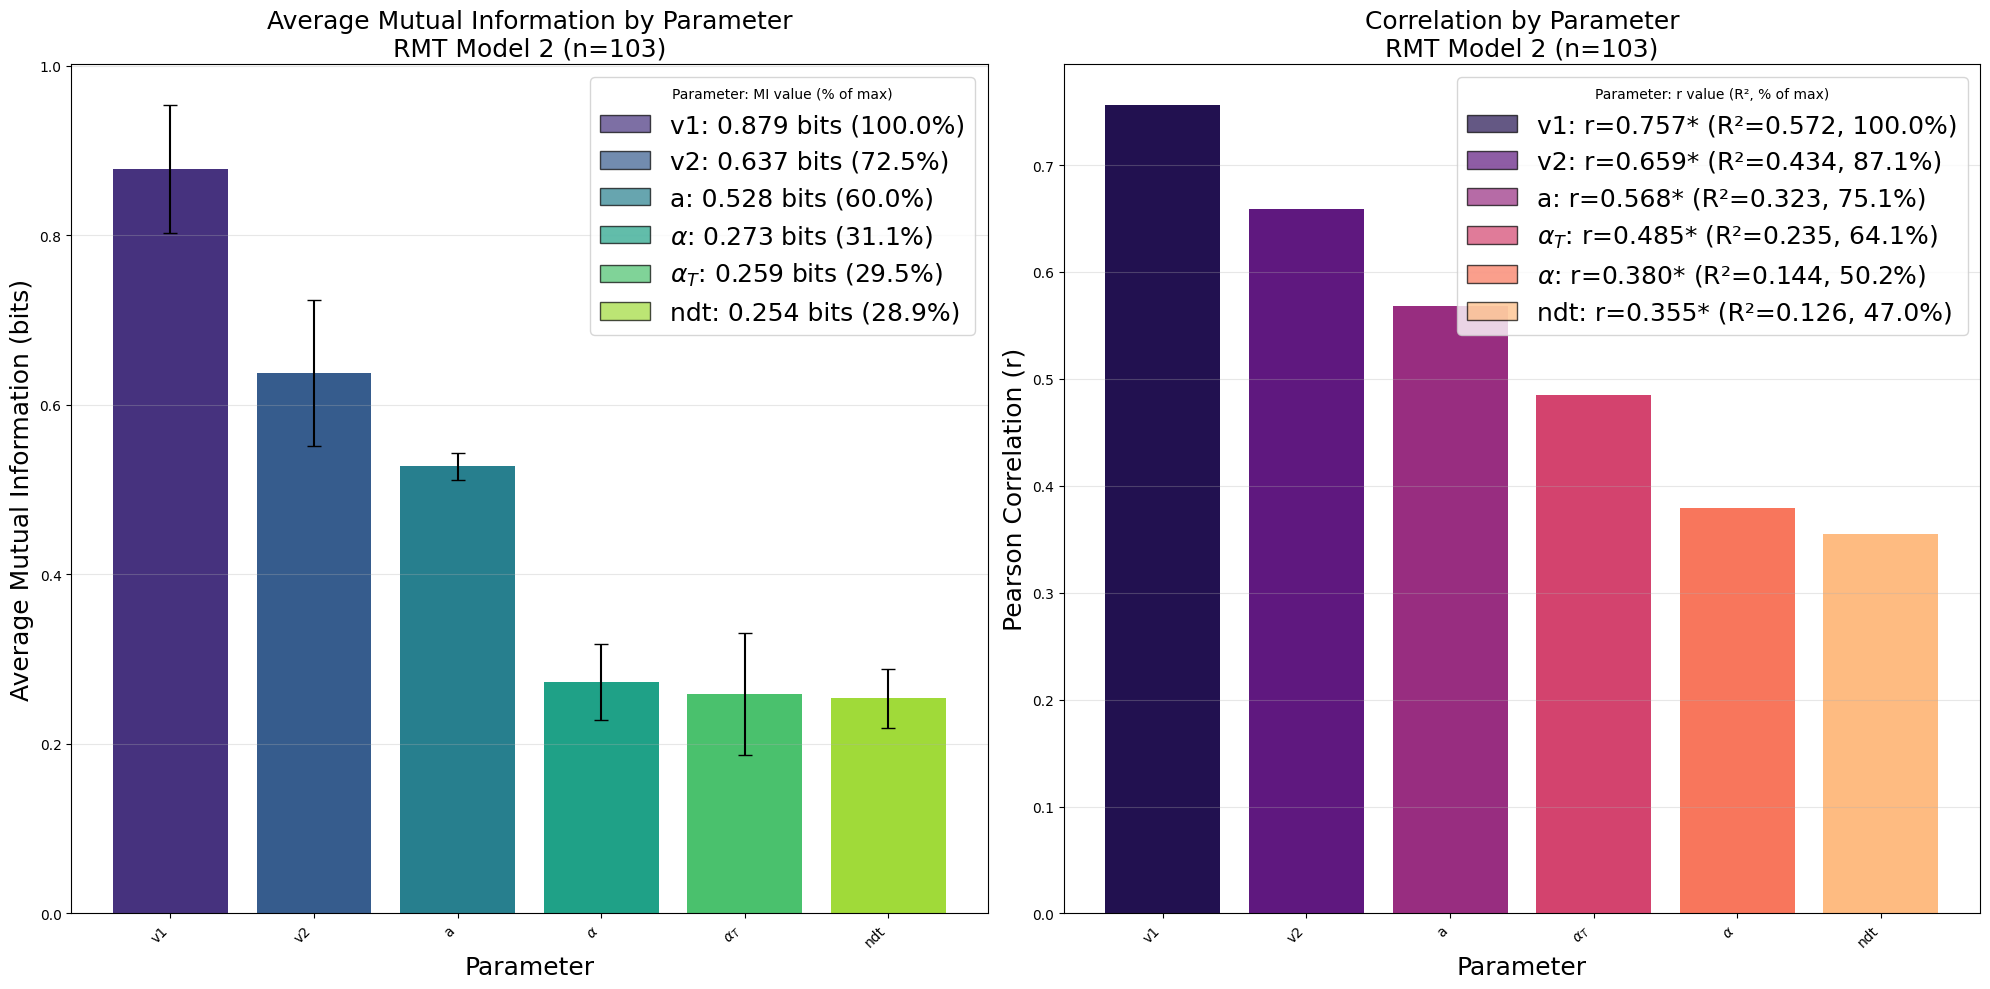


Comparison of MI and Correlation for RMT Model 2:


,Average MI (bits),MI Ratio (%),Correlation (r),R-squared,Corr Ratio (%),MI p-value,Corr p-value
v1_mean,0.878714,100.000000,0.756512,0.572311,100.000000,0.000999,2.447743e-20
v2_mean,0.637410,72.538963,0.659023,0.434312,87.113370,0.000999,3.798538e-14
a_mean,0.527629,60.045630,0.568396,0.323074,75.133784,0.000999,3.783888e-10
alpha_mean,0.273036,31.072279,0.379565,0.144070,50.173039,0.002997,7.679414e-05
alpha_mean_boxcox_after_arcsin,0.259295,29.508418,0.484787,0.235018,64.081835,0.008991,2.112183e-07
ndt_mean,0.253708,28.872619,0.355277,0.126222,46.962517,0.001998,2.309004e-04



Results exported to results_RMT_Model_2 directory


/var/folders/pp/fzhfbv9573q1s621tfds29800000gn/T/ipykernel_58448/1852563062.py:315: RuntimeWarning: divide by zero encountered in log
  theoretical_mi = -0.5 * np.log(1 - r_range**2) / np.log(2)


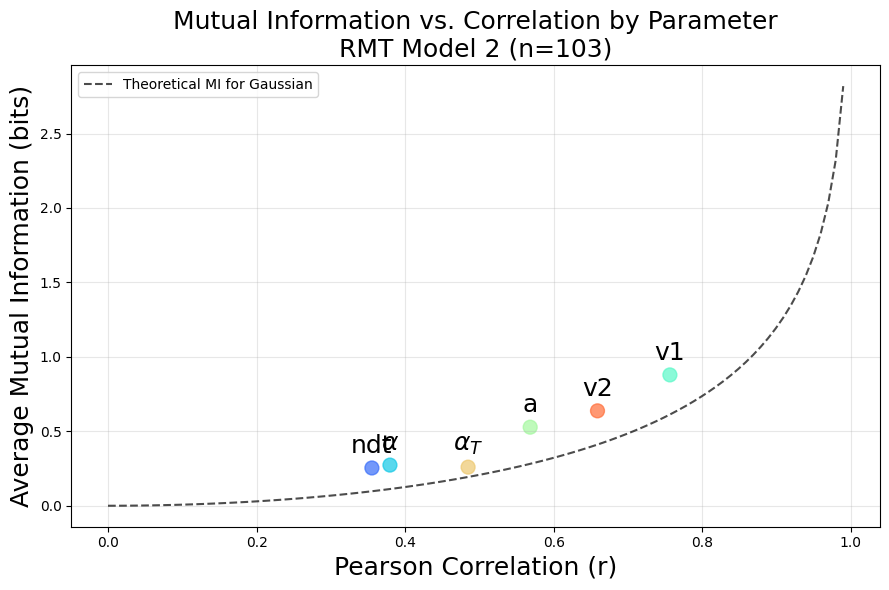

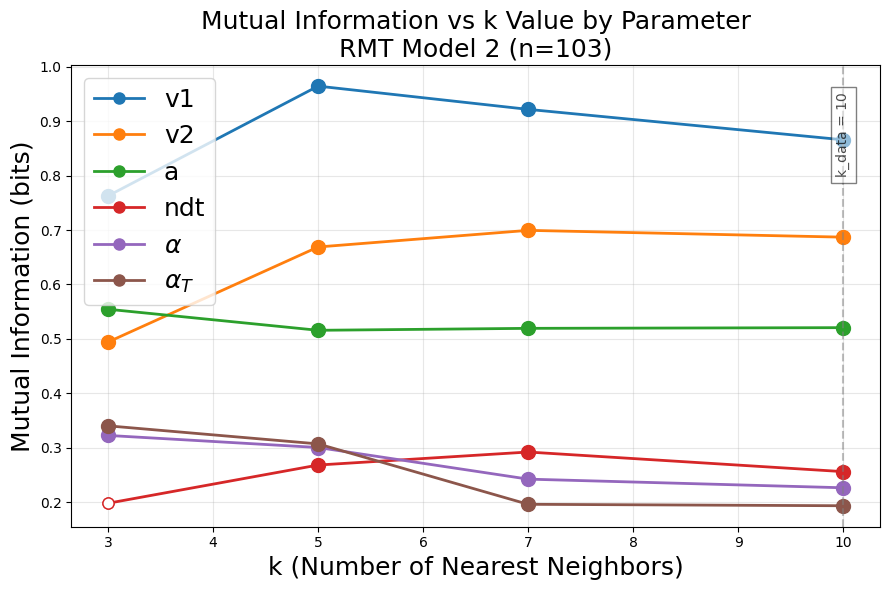

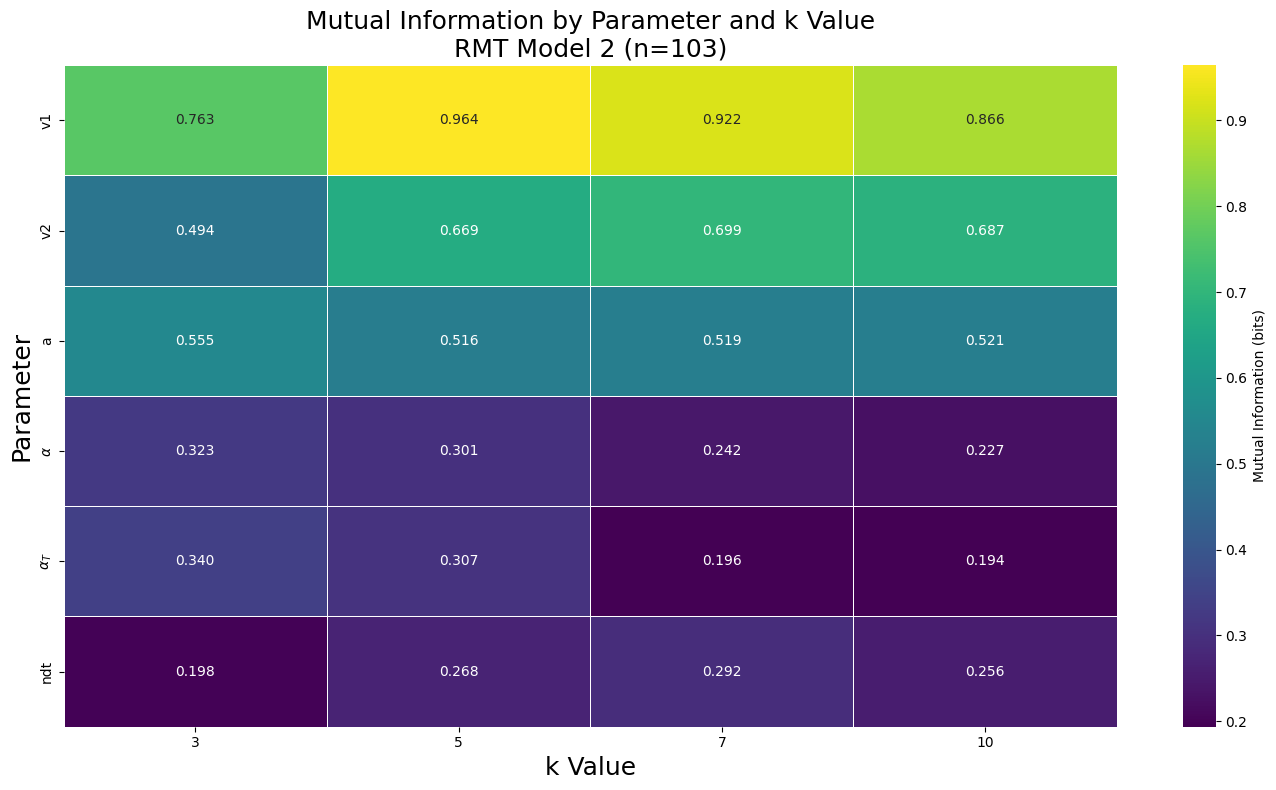

All analyses complete for RMT Model 2. Results saved to results_RMT_Model_2


In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#plt.rcParams.update({'font.size': 16})  # 🔥 Add this line

from matplotlib.patches import Patch
from KSG_MI_First_reliability import KSGMutualInformationAnalyzer
from scipy import stats
import os

Data_Name = "RMT Model 2"

# Define paths to your data files
# Define paths to your data files
session1_path = 'Model2 LDT RMT/EZ_recognition_memory_part1_transformed.csv'  # replace with your actual path
session2_path = 'Model2 LDT RMT/EZ_recognition_memory_part2_transformed.csv'
# Create a clean name for file paths (replace spaces with underscores)
file_name_prefix = Data_Name.replace(' ', '_')

# Create output directory
output_dir = f"results_{file_name_prefix}"
os.makedirs(output_dir, exist_ok=True)

# Read the CSV files
df1 = pd.read_csv(session1_path)
df2 = pd.read_csv(session2_path)

print(f"Analyzing dataset: {Data_Name}")
print("Dataset 1 shape:", df1.shape)
print("Dataset 2 shape:", df2.shape)

# List the parameters to analyze
parameters = [
    'v1_mean',
    'v2_mean',
    'zr_mean',
    'a_mean',
    'ndt_mean',
    # 'sndt_mean',
    'alpha_mean',
    'alpha_mean_boxcox_after_arcsin'
]

display_names = {
    'v1_mean': 'v1',
    'v2_mean': 'v2',
    'zr_mean': 'zr',
    'a_mean': 'a',
    'ndt_mean': 'ndt',
    # 'sndt_mean',
    'alpha_mean': r'$\alpha$',
    'alpha_mean_boxcox_after_arcsin': r'$\alpha_T$',
    # Add other replacements if needed
}

# Function to apply display names
def get_display_name(param_name):
    return display_names.get(param_name, param_name)

# Find the common ID column
id_col = next((col for col in ['ID', 'participant', 'participant_ID' ] 
              if col in df1.columns and col in df2.columns), None)

print(f"Using identifier column: {id_col}")

# Create a new merged dataframe with only the columns we need
columns_to_keep1 = [id_col] + parameters
columns_to_keep2 = [id_col] + parameters

# Only keep columns that actually exist in the dataframes
columns_to_keep1 = [col for col in columns_to_keep1 if col in df1.columns]
columns_to_keep2 = [col for col in columns_to_keep2 if col in df2.columns]

# Create new dataframes with only needed columns
df1_subset = df1[columns_to_keep1].copy()
df2_subset = df2[columns_to_keep2].copy()

# Rename columns to add session suffix
for col in df1_subset.columns:
    if col != id_col:
        df1_subset = df1_subset.rename(columns={col: f"{col}_s1"})

for col in df2_subset.columns:
    if col != id_col:
        df2_subset = df2_subset.rename(columns={col: f"{col}_s2"})

# Merge the datasets
merged_df = pd.merge(df1_subset, df2_subset, on=id_col, how='inner')
print(f"Merged data shape: {merged_df.shape}")

# Define k values to analyze

# Calculate data-driven k (sqrt of sample size)
k_data_driven = int(np.sqrt(len(merged_df)))
k_values = [3, 5, 7, 10, k_data_driven]

if k_data_driven not in k_values:
    k_values.append(k_data_driven)
    k_values.sort()
    
print(f"Using k values: {k_values} (data-driven k = {k_data_driven})")

# Initialize the analyzer
analyzer = KSGMutualInformationAnalyzer(merged_df)

# Create parameter pairs
param_pairs = []
for param in parameters:
    s1 = f"{param}_s1"
    s2 = f"{param}_s2"
    if s1 in merged_df.columns and s2 in merged_df.columns:
        param_pairs.append((s1, s2, param))
    else:
        if s1 not in merged_df.columns:
            print(f"Warning: {s1} not found in merged dataset")
        if s2 not in merged_df.columns:
            print(f"Warning: {s2} not found in merged dataset")

print(f"Found {len(param_pairs)} valid parameter pairs")

# Calculate MI across k values and correlation for each parameter
all_mi_results = {}
correlation_results = {}

for s1, s2, param_name in param_pairs:
    print(f"\nAnalyzing {param_name} across k values...")
    
    # Calculate MI for different k values
    mi_results = analyzer.analyze_across_k_values(
        param1=s1,
        param2=s2,
        k_values=k_values,
        n_permutations=1000  # Reduced for faster results
    )
    all_mi_results[param_name] = mi_results
    
    # Calculate correlation (Pearson's r)
    if s1 in merged_df.columns and s2 in merged_df.columns:
        x = merged_df[s1].values
        y = merged_df[s2].values
        
        # Skip if any NaN values
        if np.isnan(x).any() or np.isnan(y).any():
            print(f"Skipping correlation for {param_name} due to NaN values")
            continue
            
        r, p_value = stats.pearsonr(x, y)
        correlation_results[param_name] = {
            'r': r,
            'p_value': p_value,
            'r_squared': r**2  # R-squared value
        }
        
        print(f"Correlation for {param_name}: r = {r:.4f} (p={p_value:.4f}), R² = {r**2:.4f}")

# Create a detailed DataFrame with all MI values
mi_data = {}
for param_name, results in all_mi_results.items():
    mi_data[param_name] = {k: results[k]['mi'] for k in k_values if k in results}

# Convert to DataFrame
mi_df = pd.DataFrame(mi_data).T

# Add average MI column
mi_df['Average'] = mi_df.mean(axis=1)

# Create correlation DataFrame
corr_df = pd.DataFrame({
    'r': {k: v['r'] for k, v in correlation_results.items()},
    'p_value': {k: v['p_value'] for k, v in correlation_results.items()},
    'r_squared': {k: v['r_squared'] for k, v in correlation_results.items()}
})

# Sort DataFrames by their respective metrics
mi_df = mi_df.sort_values('Average', ascending=False)
corr_df = corr_df.sort_values('r', ascending=False)

# Find maximum values
max_avg_mi = mi_df['Average'].max()
max_corr = corr_df['r'].max()

# Calculate ratios to maximum
mi_df['Ratio to Max'] = mi_df['Average'] / max_avg_mi * 100
corr_df['Ratio to Max'] = corr_df['r'] / max_corr * 100

# Create a figure with two subplots side by side
plt.figure(figsize=(20, 10))

# Plot 1: MI bar chart (left)
plt.subplot(1, 2, 1)
mi_colors = sns.color_palette("viridis", len(mi_df))
mi_bars = plt.bar(range(len(mi_df)), mi_df['Average'], color=mi_colors)

# Add error bars showing standard deviation across k values
for i, param in enumerate(mi_df.index):
    std_dev = mi_df.loc[param, k_values].std()
    plt.errorbar(i, mi_df.loc[param, 'Average'], yerr=std_dev, 
                 fmt='none', color='black', capsize=5)

# Customize MI plot
plt.xlabel('Parameter', fontsize=18)
plt.ylabel('Average Mutual Information (bits)', fontsize=18)
plt.title(f'Average Mutual Information by Parameter\n{Data_Name} (n={len(merged_df)})', fontsize=18)
# Use display names for x-axis labels
plt.xticks(range(len(mi_df)), [get_display_name(param) for param in mi_df.index], rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Create MI legend
mi_legend_elements = []
mi_legend_labels = []

for i, param in enumerate(mi_df.index):
    avg = mi_df.loc[param, 'Average']
    ratio = mi_df.loc[param, 'Ratio to Max']
    
    # Create color patch for legend
    mi_legend_elements.append(Patch(facecolor=mi_colors[i], edgecolor='black', alpha=0.7))
    
    # Create label with display parameter name, MI value and percentage
    mi_legend_labels.append(f"{get_display_name(param)}: {avg:.3f} bits ({ratio:.1f}%)")

# Add MI legend
plt.legend(mi_legend_elements, mi_legend_labels, 
           title="Parameter: MI value (% of max)",
           loc='upper right',
           frameon=True,
           fontsize=18)

# Plot 2: Correlation bar chart (right)
plt.subplot(1, 2, 2)
corr_colors = sns.color_palette("magma", len(corr_df))
corr_bars = plt.bar(range(len(corr_df)), corr_df['r'], color=corr_colors)

# Customize correlation plot
plt.xlabel('Parameter', fontsize=18)
plt.ylabel('Pearson Correlation (r)', fontsize=18)
plt.title(f'Correlation by Parameter\n{Data_Name} (n={len(merged_df)})', fontsize=18)
# Use display names for x-axis labels
plt.xticks(range(len(corr_df)), [get_display_name(param) for param in corr_df.index], rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Create correlation legend
corr_legend_elements = []
corr_legend_labels = []

for i, param in enumerate(corr_df.index):
    r = corr_df.loc[param, 'r']
    r_squared = corr_df.loc[param, 'r_squared']
    ratio = corr_df.loc[param, 'Ratio to Max']
    sig = '*' if corr_df.loc[param, 'p_value'] < 0.05 else ''
    
    # Create color patch for legend
    corr_legend_elements.append(Patch(facecolor=corr_colors[i], edgecolor='black', alpha=0.7))
    
    # Create label with display parameter name, r value, R² and percentage
    corr_legend_labels.append(f"{get_display_name(param)}: r={r:.3f}{sig} (R²={r_squared:.3f}, {ratio:.1f}%)")

# Add correlation legend
plt.legend(corr_legend_elements, corr_legend_labels, 
           title="Parameter: r value (R², % of max)",
           loc='upper right',
           frameon=True,
           fontsize=18)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, f'{file_name_prefix}_mi_vs_correlation_comparison.png'), bbox_inches='tight')
plt.show()

# Create a comparison DataFrame with both MI and correlation
comparison_df = pd.DataFrame({
    'Average MI (bits)': mi_df['Average'],
    'MI Ratio (%)': mi_df['Ratio to Max'],
    'Correlation (r)': corr_df['r'],
    'R-squared': corr_df['r_squared'],
    'Corr Ratio (%)': corr_df['Ratio to Max'],
    'MI p-value': {param: all_mi_results[param][k_data_driven]['p_value'] 
                   if param in all_mi_results and k_data_driven in all_mi_results[param] 
                   else np.nan 
                   for param in mi_df.index},
    'Corr p-value': corr_df['p_value']
})

# Sort by MI descending
comparison_df = comparison_df.sort_values('Average MI (bits)', ascending=False)

# Display the comparison table
print(f"\nComparison of MI and Correlation for {Data_Name}:")
display(comparison_df)

# Export results to CSV
comparison_df.to_csv(os.path.join(output_dir, f'{file_name_prefix}_mi_and_correlation_comparison.csv'))
print(f"\nResults exported to {output_dir} directory")

# Create a scatter plot of MI vs correlation
plt.figure(figsize=(9, 6))

# Extract correlation and MI values
params = list(set(mi_df.index) & set(corr_df.index))
mi_values = [mi_df.loc[param, 'Average'] for param in params]
corr_values = [corr_df.loc[param, 'r'] for param in params]
colors = sns.color_palette("rainbow", len(params))

# Create scatter plot with parameter labels
plt.scatter(corr_values, mi_values, s=100, c=colors, alpha=0.7)

# Use display names for annotation labels
for i, param in enumerate(params):
    plt.annotate(get_display_name(param), (corr_values[i], mi_values[i]), 
                 fontsize=18, ha='center', va='bottom',
                 xytext=(0, 7), textcoords='offset points')

# Add reference line for theoretical MI of Gaussian variables
r_range = np.linspace(0, 1, 100)
theoretical_mi = -0.5 * np.log(1 - r_range**2) / np.log(2)
plt.plot(r_range, theoretical_mi, 'k--', alpha=0.7, label='Theoretical MI for Gaussian')

plt.xlabel('Pearson Correlation (r)', fontsize=18)
plt.ylabel('Average Mutual Information (bits)', fontsize=18)
plt.title(f'Mutual Information vs. Correlation by Parameter\n{Data_Name} (n={len(merged_df)})', fontsize=18)
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.savefig(os.path.join(output_dir, f'{file_name_prefix}_mi_vs_correlation_scatter.png'))
plt.show()

# Create line plot of MI across k values
plt.figure(figsize=(9, 6))

for param_name, results in all_mi_results.items():
    k_vals = list(results.keys())
    mi_vals = [results[k]['mi'] for k in k_vals]
    p_vals = [results[k]['p_value'] for k in k_vals]
    
    # Plot line with display parameter name
    line, = plt.plot(k_vals, mi_vals, marker='o', linewidth=2, markersize=8, label=get_display_name(param_name))
    
    # Mark significant points with filled markers
    for i, (k, p) in enumerate(zip(k_vals, p_vals)):
        if p < 0.05:
            plt.plot(k, mi_vals[i], marker='o', markersize=10, color=line.get_color(), markerfacecolor=line.get_color())
        else:
            plt.plot(k, mi_vals[i], marker='o', markersize=8, color=line.get_color(), markerfacecolor='white')

# Add data-driven k line
plt.axvline(x=k_data_driven, color='gray', linestyle='--', alpha=0.5)
plt.text(k_data_driven, plt.ylim()[1]*0.95, f'k_data = {k_data_driven}', 
         ha='center', va='top', rotation=90, alpha=0.7,
         bbox=dict(facecolor='white', alpha=0.5))

plt.xlabel('k (Number of Nearest Neighbors)', fontsize=18)
plt.ylabel('Mutual Information (bits)', fontsize=18)
plt.title(f'Mutual Information vs k Value by Parameter\n{Data_Name} (n={len(merged_df)})', fontsize=18)
plt.grid(True, alpha=0.3)
plt.legend(loc='best', fontsize=18)
plt.tight_layout()

# Save the plot
plt.savefig(os.path.join(output_dir, f'{file_name_prefix}_mi_vs_k_all_parameters.png'))
plt.show()

# Create a heatmap of MI values by k
plt.figure(figsize=(14, 8))
k_cols = [col for col in mi_df.columns if isinstance(col, (int, float))]

# Create a copy of the DataFrame with display names for the index
heatmap_df = mi_df[k_cols].copy()
heatmap_df.index = [get_display_name(param) for param in heatmap_df.index]

# Use the modified DataFrame for the heatmap
sns.heatmap(heatmap_df, annot=True, fmt='.3f', cmap='viridis', 
            linewidths=0.5, cbar_kws={'label': 'Mutual Information (bits)'})
plt.title(f'Mutual Information by Parameter and k Value\n{Data_Name} (n={len(merged_df)})', fontsize=18)
plt.xlabel('k Value', fontsize=18)
plt.ylabel('Parameter', fontsize=18)
plt.tight_layout()

# Save the heatmap
plt.savefig(os.path.join(output_dir, f'{file_name_prefix}_mi_heatmap_by_parameter.png'))
plt.show()

print(f"All analyses complete for {Data_Name}. Results saved to {output_dir}")

Analyzing dataset: RMT Model 1
Dataset 1 shape: (103, 25)
Dataset 2 shape: (103, 25)
Using identifier column: ID
Merged data shape: (103, 15)
Using k values: [3, 5, 7, 10, 10] (data-driven k = 10)
Found 7 valid parameter pairs

Analyzing v1_mean across k values...
Parameters: v1_mean_s1 - v1_mean_s2, k=3
MI: 1.0258 bits (p=0.0010)
----------------------------------------
Parameters: v1_mean_s1 - v1_mean_s2, k=5
MI: 0.9243 bits (p=0.0010)
----------------------------------------
Parameters: v1_mean_s1 - v1_mean_s2, k=7
MI: 0.8963 bits (p=0.0010)
----------------------------------------
Parameters: v1_mean_s1 - v1_mean_s2, k=10
MI: 0.8635 bits (p=0.0010)
----------------------------------------
Parameters: v1_mean_s1 - v1_mean_s2, k=10
MI: 0.8635 bits (p=0.0010)
----------------------------------------
Correlation for v1_mean: r = 0.7199 (p=0.0000), R² = 0.5182

Analyzing v2_mean across k values...
Parameters: v2_mean_s1 - v2_mean_s2, k=3
MI: 0.9800 bits (p=0.0010)
----------------------

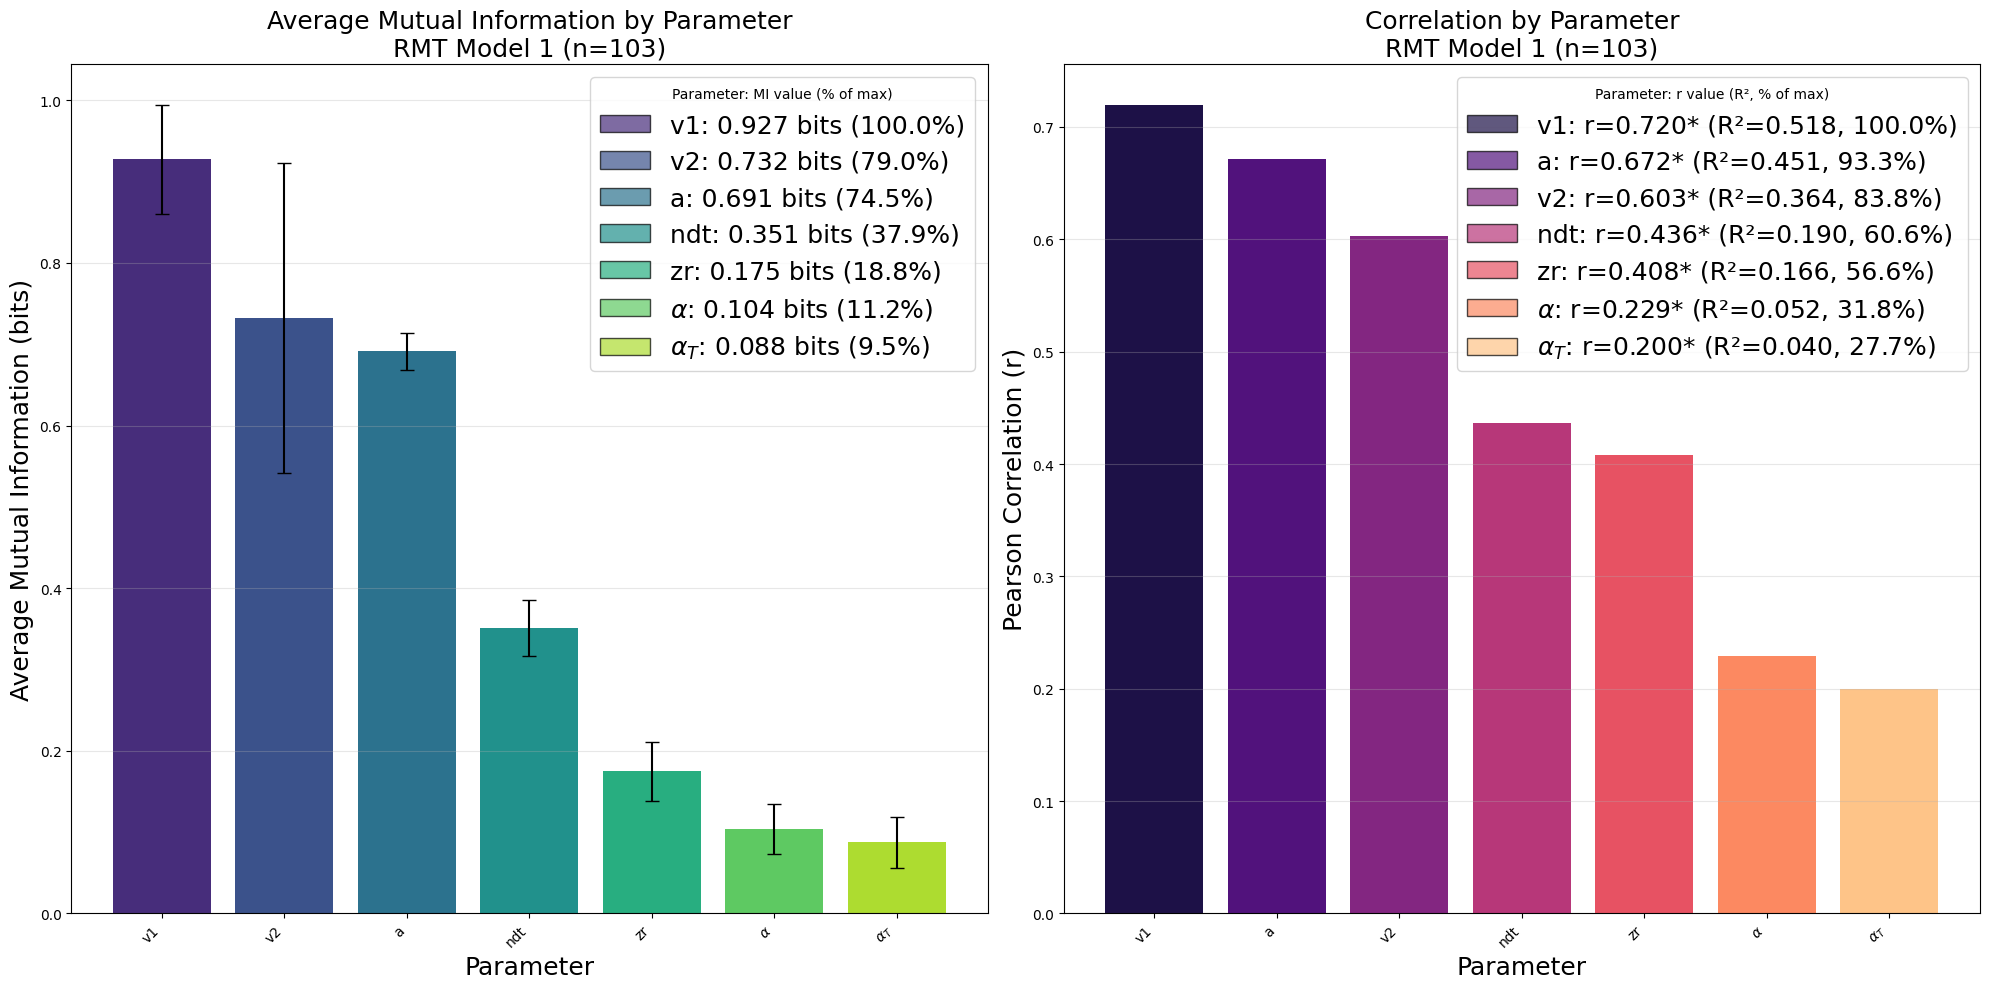


Comparison of MI and Correlation for RMT Model 1:


,Average MI (bits),MI Ratio (%),Correlation (r),R-squared,Corr Ratio (%),MI p-value,Corr p-value
v1_mean,0.927493,100.000000,0.719869,0.518211,100.000000,0.000999,1.051679e-17
v2_mean,0.732392,78.964695,0.603290,0.363959,83.805592,0.000999,1.538454e-11
a_mean,0.691290,74.533100,0.671814,0.451334,93.324473,0.000999,7.971452e-15
ndt_mean,0.351192,37.864660,0.436092,0.190176,60.579385,0.000999,4.134503e-06
zr_mean,0.174739,18.839934,0.407656,0.166183,56.629210,0.001998,1.920394e-05
alpha_mean,0.103537,11.163151,0.228730,0.052318,31.773875,0.037962,2.012948e-02
alpha_mean_boxcox_after_arcsin,0.087662,9.451483,0.199647,0.039859,27.733736,0.029970,4.319020e-02



Results exported to results_RMT_Model_1 directory


/var/folders/pp/fzhfbv9573q1s621tfds29800000gn/T/ipykernel_58448/3491649515.py:315: RuntimeWarning: divide by zero encountered in log
  theoretical_mi = -0.5 * np.log(1 - r_range**2) / np.log(2)


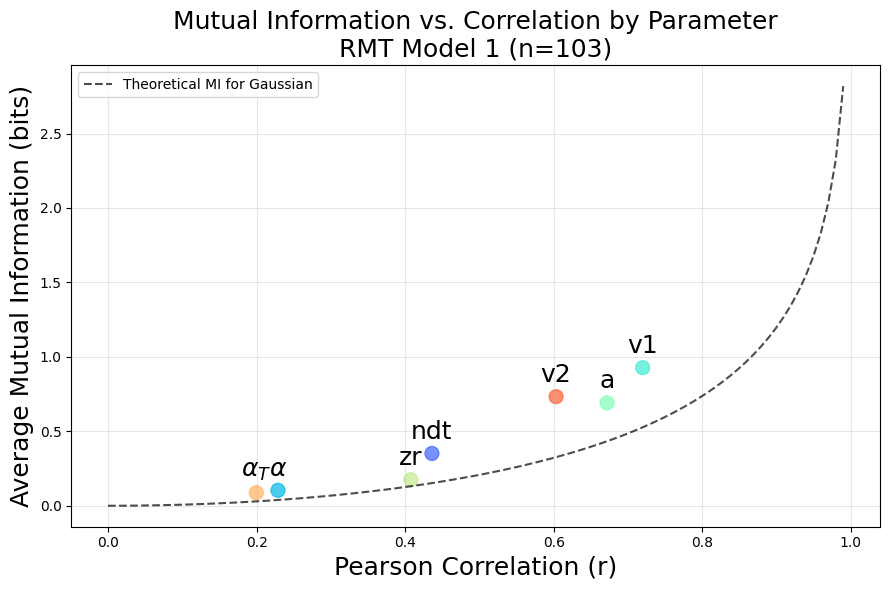

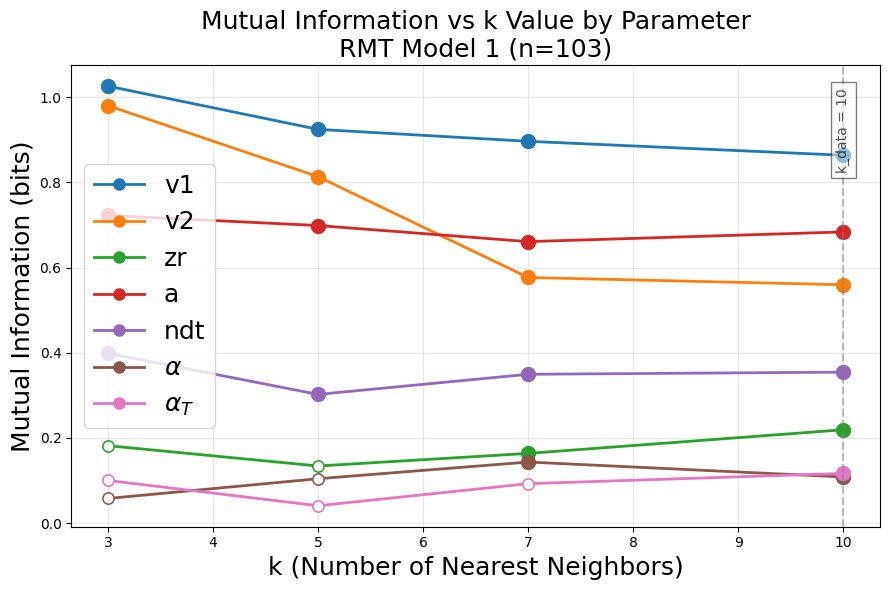

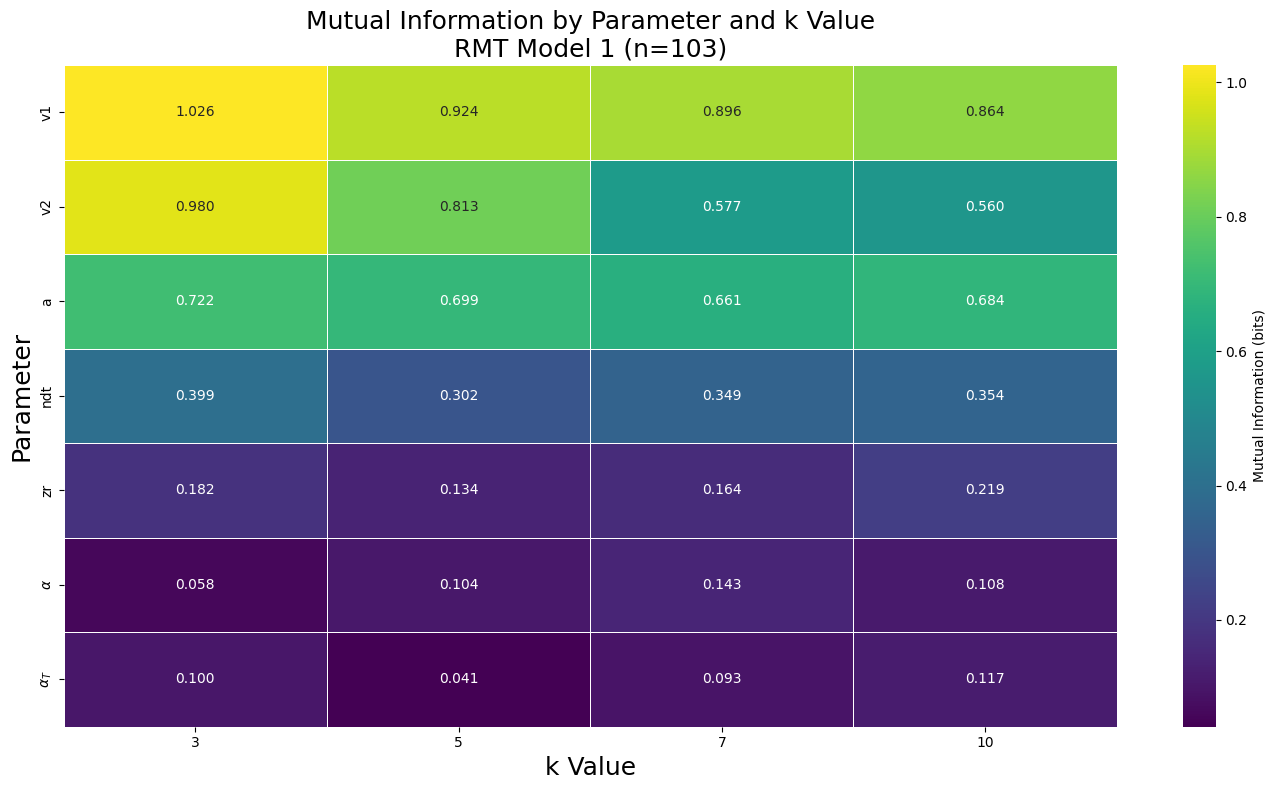

All analyses complete for RMT Model 1. Results saved to results_RMT_Model_1


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#plt.rcParams.update({'font.size': 16})  # 🔥 Add this line

from matplotlib.patches import Patch
from KSG_MI_First_reliability import KSGMutualInformationAnalyzer
from scipy import stats
import os

# Define the dataset name (modify this for different datasets)
Data_Name = "RMT Model 1"

# Define paths to your data files
session1_path = 'Model1 LDT RMT/rmt_session_1_data_transformed.csv'  # replace with your actual path
session2_path = 'Model1 LDT RMT/rmt_session_2_data_transformed.csv'
# Create a clean name for file paths (replace spaces with underscores)
file_name_prefix = Data_Name.replace(' ', '_')

# Create output directory
output_dir = f"results_{file_name_prefix}"
os.makedirs(output_dir, exist_ok=True)

# Read the CSV files
df1 = pd.read_csv(session1_path)
df2 = pd.read_csv(session2_path)

print(f"Analyzing dataset: {Data_Name}")
print("Dataset 1 shape:", df1.shape)
print("Dataset 2 shape:", df2.shape)

# List the parameters to analyze
parameters = [
    'v1_mean',
    'v2_mean',
    'zr_mean',
    'a_mean',
    'ndt_mean',
    # 'sndt_mean',
    'alpha_mean',
    'alpha_mean_boxcox_after_arcsin'
]

display_names = {
    'v1_mean': 'v1',
    'v2_mean': 'v2',
    'zr_mean': 'zr',
    'a_mean': 'a',
    'ndt_mean': 'ndt',
    # 'sndt_mean',
    'alpha_mean': r'$\alpha$',
    'alpha_mean_boxcox_after_arcsin': r'$\alpha_T$',
    # Add other replacements if needed
}

# Function to apply display names
def get_display_name(param_name):
    return display_names.get(param_name, param_name)

# Find the common ID column
id_col = next((col for col in ['ID', 'participant', 'participant_ID' ] 
              if col in df1.columns and col in df2.columns), None)

print(f"Using identifier column: {id_col}")

# Create a new merged dataframe with only the columns we need
columns_to_keep1 = [id_col] + parameters
columns_to_keep2 = [id_col] + parameters

# Only keep columns that actually exist in the dataframes
columns_to_keep1 = [col for col in columns_to_keep1 if col in df1.columns]
columns_to_keep2 = [col for col in columns_to_keep2 if col in df2.columns]

# Create new dataframes with only needed columns
df1_subset = df1[columns_to_keep1].copy()
df2_subset = df2[columns_to_keep2].copy()

# Rename columns to add session suffix
for col in df1_subset.columns:
    if col != id_col:
        df1_subset = df1_subset.rename(columns={col: f"{col}_s1"})

for col in df2_subset.columns:
    if col != id_col:
        df2_subset = df2_subset.rename(columns={col: f"{col}_s2"})

# Merge the datasets
merged_df = pd.merge(df1_subset, df2_subset, on=id_col, how='inner')
print(f"Merged data shape: {merged_df.shape}")

# Define k values to analyze

# Calculate data-driven k (sqrt of sample size)
k_data_driven = int(np.sqrt(len(merged_df)))
k_values = [3, 5, 7, 10, k_data_driven]

if k_data_driven not in k_values:
    k_values.append(k_data_driven)
    k_values.sort()
    
print(f"Using k values: {k_values} (data-driven k = {k_data_driven})")

# Initialize the analyzer
analyzer = KSGMutualInformationAnalyzer(merged_df)

# Create parameter pairs
param_pairs = []
for param in parameters:
    s1 = f"{param}_s1"
    s2 = f"{param}_s2"
    if s1 in merged_df.columns and s2 in merged_df.columns:
        param_pairs.append((s1, s2, param))
    else:
        if s1 not in merged_df.columns:
            print(f"Warning: {s1} not found in merged dataset")
        if s2 not in merged_df.columns:
            print(f"Warning: {s2} not found in merged dataset")

print(f"Found {len(param_pairs)} valid parameter pairs")

# Calculate MI across k values and correlation for each parameter
all_mi_results = {}
correlation_results = {}

for s1, s2, param_name in param_pairs:
    print(f"\nAnalyzing {param_name} across k values...")
    
    # Calculate MI for different k values
    mi_results = analyzer.analyze_across_k_values(
        param1=s1,
        param2=s2,
        k_values=k_values,
        n_permutations=1000  # Reduced for faster results
    )
    all_mi_results[param_name] = mi_results
    
    # Calculate correlation (Pearson's r)
    if s1 in merged_df.columns and s2 in merged_df.columns:
        x = merged_df[s1].values
        y = merged_df[s2].values
        
        # Skip if any NaN values
        if np.isnan(x).any() or np.isnan(y).any():
            print(f"Skipping correlation for {param_name} due to NaN values")
            continue
            
        r, p_value = stats.pearsonr(x, y)
        correlation_results[param_name] = {
            'r': r,
            'p_value': p_value,
            'r_squared': r**2  # R-squared value
        }
        
        print(f"Correlation for {param_name}: r = {r:.4f} (p={p_value:.4f}), R² = {r**2:.4f}")

# Create a detailed DataFrame with all MI values
mi_data = {}
for param_name, results in all_mi_results.items():
    mi_data[param_name] = {k: results[k]['mi'] for k in k_values if k in results}

# Convert to DataFrame
mi_df = pd.DataFrame(mi_data).T

# Add average MI column
mi_df['Average'] = mi_df.mean(axis=1)

# Create correlation DataFrame
corr_df = pd.DataFrame({
    'r': {k: v['r'] for k, v in correlation_results.items()},
    'p_value': {k: v['p_value'] for k, v in correlation_results.items()},
    'r_squared': {k: v['r_squared'] for k, v in correlation_results.items()}
})

# Sort DataFrames by their respective metrics
mi_df = mi_df.sort_values('Average', ascending=False)
corr_df = corr_df.sort_values('r', ascending=False)

# Find maximum values
max_avg_mi = mi_df['Average'].max()
max_corr = corr_df['r'].max()

# Calculate ratios to maximum
mi_df['Ratio to Max'] = mi_df['Average'] / max_avg_mi * 100
corr_df['Ratio to Max'] = corr_df['r'] / max_corr * 100

# Create a figure with two subplots side by side
plt.figure(figsize=(20, 10))

# Plot 1: MI bar chart (left)
plt.subplot(1, 2, 1)
mi_colors = sns.color_palette("viridis", len(mi_df))
mi_bars = plt.bar(range(len(mi_df)), mi_df['Average'], color=mi_colors)

# Add error bars showing standard deviation across k values
for i, param in enumerate(mi_df.index):
    std_dev = mi_df.loc[param, k_values].std()
    plt.errorbar(i, mi_df.loc[param, 'Average'], yerr=std_dev, 
                 fmt='none', color='black', capsize=5)

# Customize MI plot
plt.xlabel('Parameter', fontsize=18)
plt.ylabel('Average Mutual Information (bits)', fontsize=18)
plt.title(f'Average Mutual Information by Parameter\n{Data_Name} (n={len(merged_df)})', fontsize=18)
# Use display names for x-axis labels
plt.xticks(range(len(mi_df)), [get_display_name(param) for param in mi_df.index], rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Create MI legend
mi_legend_elements = []
mi_legend_labels = []

for i, param in enumerate(mi_df.index):
    avg = mi_df.loc[param, 'Average']
    ratio = mi_df.loc[param, 'Ratio to Max']
    
    # Create color patch for legend
    mi_legend_elements.append(Patch(facecolor=mi_colors[i], edgecolor='black', alpha=0.7))
    
    # Create label with display parameter name, MI value and percentage
    mi_legend_labels.append(f"{get_display_name(param)}: {avg:.3f} bits ({ratio:.1f}%)")

# Add MI legend
plt.legend(mi_legend_elements, mi_legend_labels, 
           title="Parameter: MI value (% of max)",
           loc='upper right',
           frameon=True,
           fontsize=18)

# Plot 2: Correlation bar chart (right)
plt.subplot(1, 2, 2)
corr_colors = sns.color_palette("magma", len(corr_df))
corr_bars = plt.bar(range(len(corr_df)), corr_df['r'], color=corr_colors)

# Customize correlation plot
plt.xlabel('Parameter', fontsize=18)
plt.ylabel('Pearson Correlation (r)', fontsize=18)
plt.title(f'Correlation by Parameter\n{Data_Name} (n={len(merged_df)})', fontsize=18)
# Use display names for x-axis labels
plt.xticks(range(len(corr_df)), [get_display_name(param) for param in corr_df.index], rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Create correlation legend
corr_legend_elements = []
corr_legend_labels = []

for i, param in enumerate(corr_df.index):
    r = corr_df.loc[param, 'r']
    r_squared = corr_df.loc[param, 'r_squared']
    ratio = corr_df.loc[param, 'Ratio to Max']
    sig = '*' if corr_df.loc[param, 'p_value'] < 0.05 else ''
    
    # Create color patch for legend
    corr_legend_elements.append(Patch(facecolor=corr_colors[i], edgecolor='black', alpha=0.7))
    
    # Create label with display parameter name, r value, R² and percentage
    corr_legend_labels.append(f"{get_display_name(param)}: r={r:.3f}{sig} (R²={r_squared:.3f}, {ratio:.1f}%)")

# Add correlation legend
plt.legend(corr_legend_elements, corr_legend_labels, 
           title="Parameter: r value (R², % of max)",
           loc='upper right',
           frameon=True,
           fontsize=18)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, f'{file_name_prefix}_mi_vs_correlation_comparison.png'), bbox_inches='tight')
plt.show()

# Create a comparison DataFrame with both MI and correlation
comparison_df = pd.DataFrame({
    'Average MI (bits)': mi_df['Average'],
    'MI Ratio (%)': mi_df['Ratio to Max'],
    'Correlation (r)': corr_df['r'],
    'R-squared': corr_df['r_squared'],
    'Corr Ratio (%)': corr_df['Ratio to Max'],
    'MI p-value': {param: all_mi_results[param][k_data_driven]['p_value'] 
                   if param in all_mi_results and k_data_driven in all_mi_results[param] 
                   else np.nan 
                   for param in mi_df.index},
    'Corr p-value': corr_df['p_value']
})

# Sort by MI descending
comparison_df = comparison_df.sort_values('Average MI (bits)', ascending=False)

# Display the comparison table
print(f"\nComparison of MI and Correlation for {Data_Name}:")
display(comparison_df)

# Export results to CSV
comparison_df.to_csv(os.path.join(output_dir, f'{file_name_prefix}_mi_and_correlation_comparison.csv'))
print(f"\nResults exported to {output_dir} directory")

# Create a scatter plot of MI vs correlation
plt.figure(figsize=(9, 6))

# Extract correlation and MI values
params = list(set(mi_df.index) & set(corr_df.index))
mi_values = [mi_df.loc[param, 'Average'] for param in params]
corr_values = [corr_df.loc[param, 'r'] for param in params]
colors = sns.color_palette("rainbow", len(params))

# Create scatter plot with parameter labels
plt.scatter(corr_values, mi_values, s=100, c=colors, alpha=0.7)

# Use display names for annotation labels
for i, param in enumerate(params):
    plt.annotate(get_display_name(param), (corr_values[i], mi_values[i]), 
                 fontsize=18, ha='center', va='bottom',
                 xytext=(0, 7), textcoords='offset points')

# Add reference line for theoretical MI of Gaussian variables
r_range = np.linspace(0, 1, 100)
theoretical_mi = -0.5 * np.log(1 - r_range**2) / np.log(2)
plt.plot(r_range, theoretical_mi, 'k--', alpha=0.7, label='Theoretical MI for Gaussian')

plt.xlabel('Pearson Correlation (r)', fontsize=18)
plt.ylabel('Average Mutual Information (bits)', fontsize=18)
plt.title(f'Mutual Information vs. Correlation by Parameter\n{Data_Name} (n={len(merged_df)})', fontsize=18)
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.savefig(os.path.join(output_dir, f'{file_name_prefix}_mi_vs_correlation_scatter.png'))
plt.show()

# Create line plot of MI across k values
plt.figure(figsize=(9, 6))

for param_name, results in all_mi_results.items():
    k_vals = list(results.keys())
    mi_vals = [results[k]['mi'] for k in k_vals]
    p_vals = [results[k]['p_value'] for k in k_vals]
    
    # Plot line with display parameter name
    line, = plt.plot(k_vals, mi_vals, marker='o', linewidth=2, markersize=8, label=get_display_name(param_name))
    
    # Mark significant points with filled markers
    for i, (k, p) in enumerate(zip(k_vals, p_vals)):
        if p < 0.05:
            plt.plot(k, mi_vals[i], marker='o', markersize=10, color=line.get_color(), markerfacecolor=line.get_color())
        else:
            plt.plot(k, mi_vals[i], marker='o', markersize=8, color=line.get_color(), markerfacecolor='white')

# Add data-driven k line
plt.axvline(x=k_data_driven, color='gray', linestyle='--', alpha=0.5)
plt.text(k_data_driven, plt.ylim()[1]*0.95, f'k_data = {k_data_driven}', 
         ha='center', va='top', rotation=90, alpha=0.7,
         bbox=dict(facecolor='white', alpha=0.5))

plt.xlabel('k (Number of Nearest Neighbors)', fontsize=18)
plt.ylabel('Mutual Information (bits)', fontsize=18)
plt.title(f'Mutual Information vs k Value by Parameter\n{Data_Name} (n={len(merged_df)})', fontsize=18)
plt.grid(True, alpha=0.3)
plt.legend(loc='best', fontsize=18)
plt.tight_layout()

# Save the plot
plt.savefig(os.path.join(output_dir, f'{file_name_prefix}_mi_vs_k_all_parameters.png'))
plt.show()

# Create a heatmap of MI values by k
plt.figure(figsize=(14, 8))
k_cols = [col for col in mi_df.columns if isinstance(col, (int, float))]

# Create a copy of the DataFrame with display names for the index
heatmap_df = mi_df[k_cols].copy()
heatmap_df.index = [get_display_name(param) for param in heatmap_df.index]

# Use the modified DataFrame for the heatmap
sns.heatmap(heatmap_df, annot=True, fmt='.3f', cmap='viridis', 
            linewidths=0.5, cbar_kws={'label': 'Mutual Information (bits)'})
plt.title(f'Mutual Information by Parameter and k Value\n{Data_Name} (n={len(merged_df)})', fontsize=18)
plt.xlabel('k Value', fontsize=18)
plt.ylabel('Parameter', fontsize=18)
plt.tight_layout()

# Save the heatmap
plt.savefig(os.path.join(output_dir, f'{file_name_prefix}_mi_heatmap_by_parameter.png'))
plt.show()

print(f"All analyses complete for {Data_Name}. Results saved to {output_dir}")

Analyzing dataset: LDT Model 2
Dataset 1 shape: (104, 27)
Dataset 2 shape: (104, 27)
Using identifier column: participant_ID
Merged data shape: (104, 13)
Using k values: [3, 5, 7, 10, 10] (data-driven k = 10)
Found 6 valid parameter pairs

Analyzing v1_mean across k values...
Parameters: v1_mean_s1 - v1_mean_s2, k=3
MI: 0.9504 bits (p=0.0010)
----------------------------------------
Parameters: v1_mean_s1 - v1_mean_s2, k=5
MI: 0.7559 bits (p=0.0010)
----------------------------------------
Parameters: v1_mean_s1 - v1_mean_s2, k=7
MI: 0.8182 bits (p=0.0010)
----------------------------------------
Parameters: v1_mean_s1 - v1_mean_s2, k=10
MI: 0.7768 bits (p=0.0010)
----------------------------------------
Parameters: v1_mean_s1 - v1_mean_s2, k=10
MI: 0.7768 bits (p=0.0010)
----------------------------------------
Correlation for v1_mean: r = 0.8009 (p=0.0000), R² = 0.6414

Analyzing v2_mean across k values...
Parameters: v2_mean_s1 - v2_mean_s2, k=3
MI: 1.3117 bits (p=0.0010)
----------

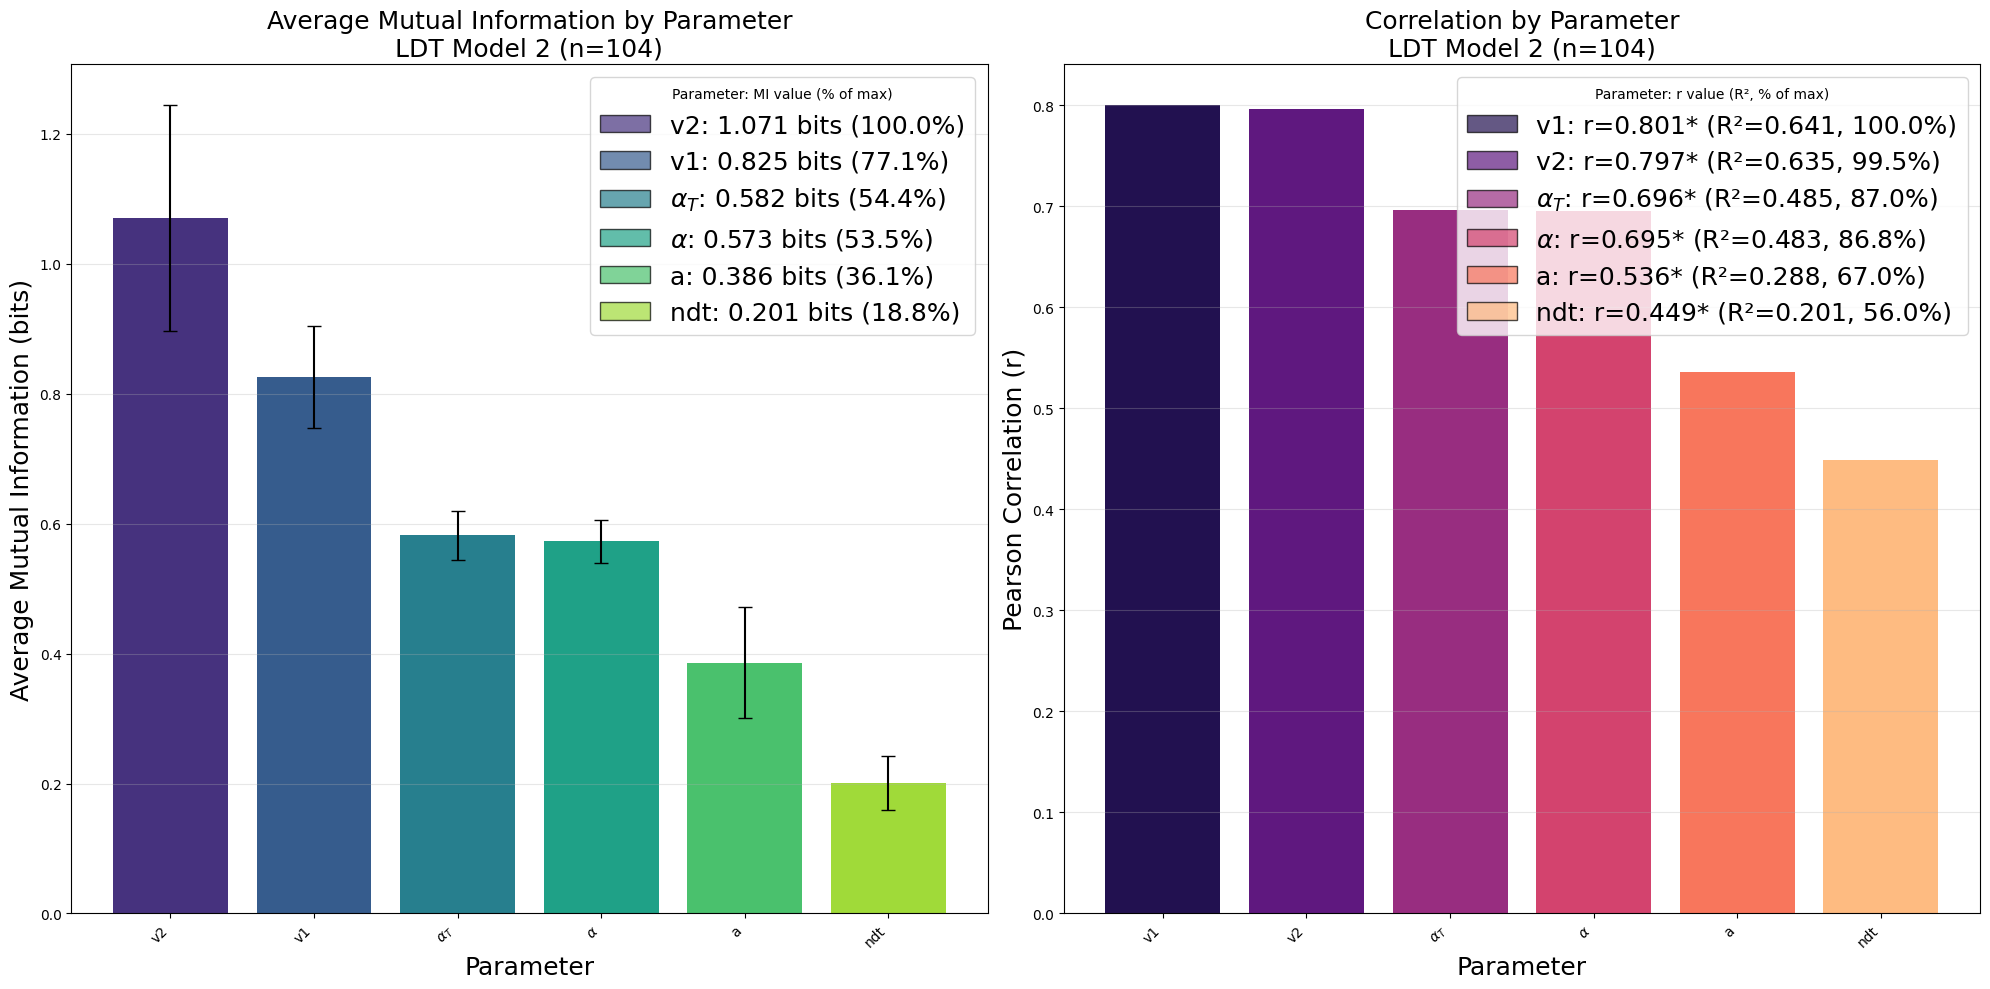


Comparison of MI and Correlation for LDT Model 2:


,Average MI (bits),MI Ratio (%),Correlation (r),R-squared,Corr Ratio (%),MI p-value,Corr p-value
v2_mean,1.070733,100.000000,0.796937,0.635109,99.506952,0.000999,4.603912e-24
v1_mean,0.825314,77.079355,0.800886,0.641418,100.000000,0.000999,1.882395e-24
alpha_mean_boxcox_after_arcsin,0.582272,54.380685,0.696389,0.484958,86.952372,0.000999,2.256179e-16
alpha_mean,0.573069,53.521164,0.695281,0.483416,86.814008,0.000999,2.631840e-16
a_mean,0.386162,36.065253,0.536353,0.287674,66.969938,0.000999,4.404932e-09
ndt_mean,0.201110,18.782495,0.448551,0.201198,56.006909,0.007992,1.794292e-06



Results exported to results_LDT_Model_2 directory


/var/folders/pp/fzhfbv9573q1s621tfds29800000gn/T/ipykernel_58448/4242943786.py:314: RuntimeWarning: divide by zero encountered in log
  theoretical_mi = -0.5 * np.log(1 - r_range**2) / np.log(2)


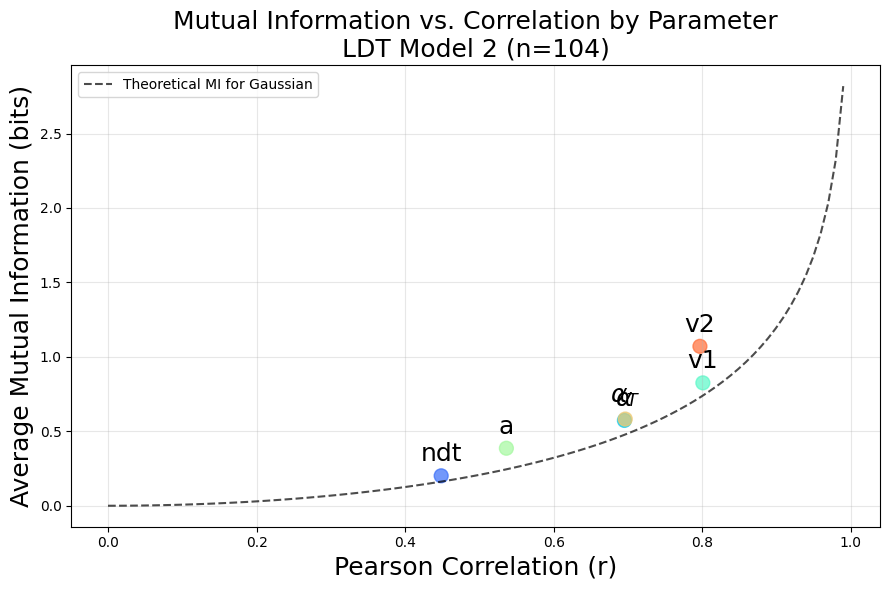

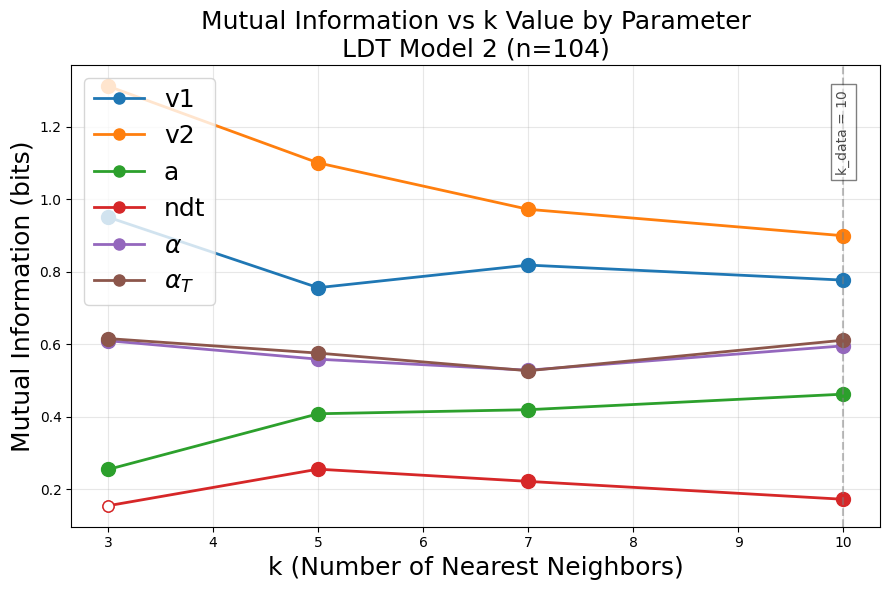

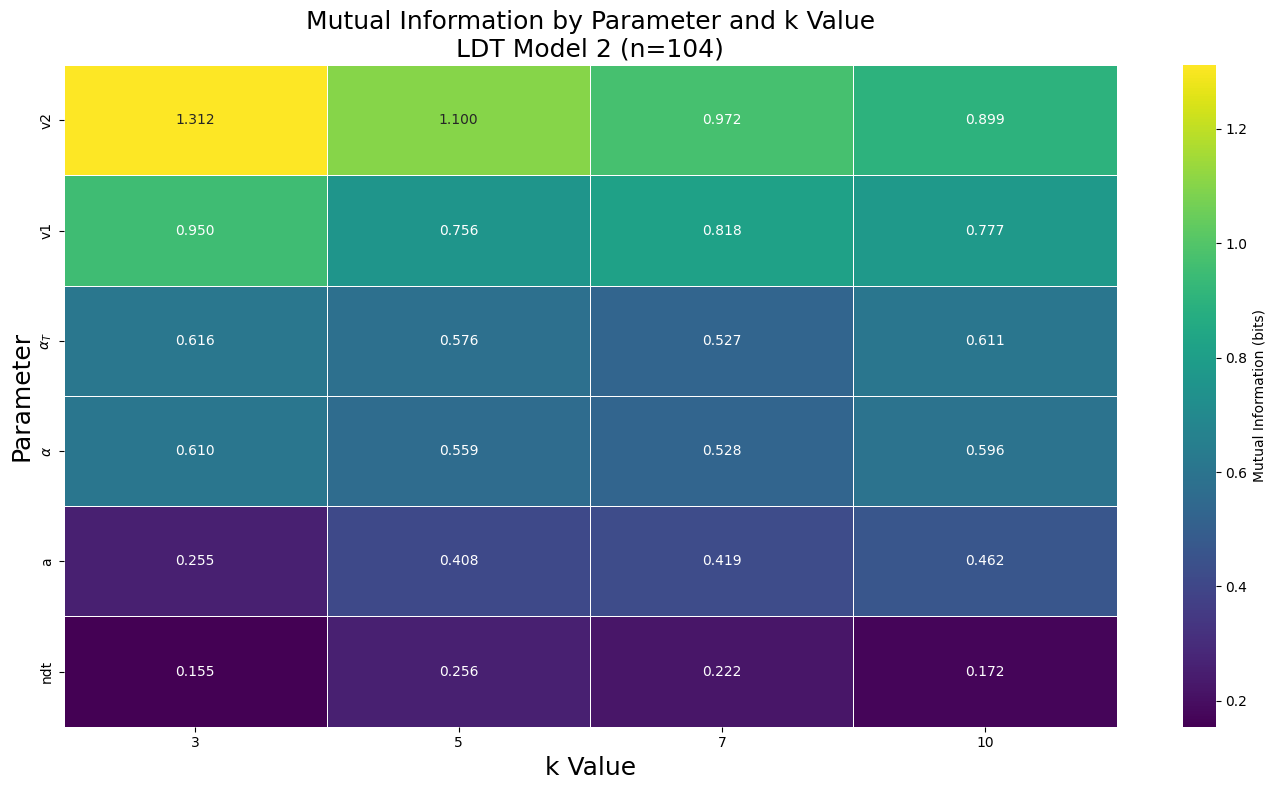

All analyses complete for LDT Model 2. Results saved to results_LDT_Model_2


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#plt.rcParams.update({'font.size': 16})  # 🔥 Add this line

from matplotlib.patches import Patch
from KSG_MI_First_reliability import KSGMutualInformationAnalyzer
from scipy import stats
import os

Data_Name = "LDT Model 2"

# Define paths to your data files
session1_path = 'Model2 LDT RMT/EZ_lexical_decision_part1_transformed.csv'  # replace with your actual path
session2_path = 'Model2 LDT RMT/EZ_lexical_decision_part2_transformed.csv'
# Create a clean name for file paths (replace spaces with underscores)
file_name_prefix = Data_Name.replace(' ', '_')

# Create output directory
output_dir = f"results_{file_name_prefix}"
os.makedirs(output_dir, exist_ok=True)

# Read the CSV files
df1 = pd.read_csv(session1_path)
df2 = pd.read_csv(session2_path)

print(f"Analyzing dataset: {Data_Name}")
print("Dataset 1 shape:", df1.shape)
print("Dataset 2 shape:", df2.shape)

# List the parameters to analyze
parameters = [
    'v1_mean',
    'v2_mean',
    'zr_mean',
    'a_mean',
    'ndt_mean',
    # 'sndt_mean',
    'alpha_mean',
    'alpha_mean_boxcox_after_arcsin'
]

display_names = {
    'v1_mean': 'v1',
    'v2_mean': 'v2',
    'zr_mean': 'zr',
    'a_mean': 'a',
    'ndt_mean': 'ndt',
    # 'sndt_mean',
    'alpha_mean': r'$\alpha$',
    'alpha_mean_boxcox_after_arcsin': r'$\alpha_T$',
    # Add other replacements if needed
}

# Function to apply display names
def get_display_name(param_name):
    return display_names.get(param_name, param_name)

# Find the common ID column
id_col = next((col for col in ['ID', 'participant', 'participant_ID' ] 
              if col in df1.columns and col in df2.columns), None)

print(f"Using identifier column: {id_col}")

# Create a new merged dataframe with only the columns we need
columns_to_keep1 = [id_col] + parameters
columns_to_keep2 = [id_col] + parameters

# Only keep columns that actually exist in the dataframes
columns_to_keep1 = [col for col in columns_to_keep1 if col in df1.columns]
columns_to_keep2 = [col for col in columns_to_keep2 if col in df2.columns]

# Create new dataframes with only needed columns
df1_subset = df1[columns_to_keep1].copy()
df2_subset = df2[columns_to_keep2].copy()

# Rename columns to add session suffix
for col in df1_subset.columns:
    if col != id_col:
        df1_subset = df1_subset.rename(columns={col: f"{col}_s1"})

for col in df2_subset.columns:
    if col != id_col:
        df2_subset = df2_subset.rename(columns={col: f"{col}_s2"})

# Merge the datasets
merged_df = pd.merge(df1_subset, df2_subset, on=id_col, how='inner')
print(f"Merged data shape: {merged_df.shape}")

# Define k values to analyze

# Calculate data-driven k (sqrt of sample size)
k_data_driven = int(np.sqrt(len(merged_df)))
k_values = [3, 5, 7, 10, k_data_driven]

if k_data_driven not in k_values:
    k_values.append(k_data_driven)
    k_values.sort()
    
print(f"Using k values: {k_values} (data-driven k = {k_data_driven})")

# Initialize the analyzer
analyzer = KSGMutualInformationAnalyzer(merged_df)

# Create parameter pairs
param_pairs = []
for param in parameters:
    s1 = f"{param}_s1"
    s2 = f"{param}_s2"
    if s1 in merged_df.columns and s2 in merged_df.columns:
        param_pairs.append((s1, s2, param))
    else:
        if s1 not in merged_df.columns:
            print(f"Warning: {s1} not found in merged dataset")
        if s2 not in merged_df.columns:
            print(f"Warning: {s2} not found in merged dataset")

print(f"Found {len(param_pairs)} valid parameter pairs")

# Calculate MI across k values and correlation for each parameter
all_mi_results = {}
correlation_results = {}

for s1, s2, param_name in param_pairs:
    print(f"\nAnalyzing {param_name} across k values...")
    
    # Calculate MI for different k values
    mi_results = analyzer.analyze_across_k_values(
        param1=s1,
        param2=s2,
        k_values=k_values,
        n_permutations=1000  # Reduced for faster results
    )
    all_mi_results[param_name] = mi_results
    
    # Calculate correlation (Pearson's r)
    if s1 in merged_df.columns and s2 in merged_df.columns:
        x = merged_df[s1].values
        y = merged_df[s2].values
        
        # Skip if any NaN values
        if np.isnan(x).any() or np.isnan(y).any():
            print(f"Skipping correlation for {param_name} due to NaN values")
            continue
            
        r, p_value = stats.pearsonr(x, y)
        correlation_results[param_name] = {
            'r': r,
            'p_value': p_value,
            'r_squared': r**2  # R-squared value
        }
        
        print(f"Correlation for {param_name}: r = {r:.4f} (p={p_value:.4f}), R² = {r**2:.4f}")

# Create a detailed DataFrame with all MI values
mi_data = {}
for param_name, results in all_mi_results.items():
    mi_data[param_name] = {k: results[k]['mi'] for k in k_values if k in results}

# Convert to DataFrame
mi_df = pd.DataFrame(mi_data).T

# Add average MI column
mi_df['Average'] = mi_df.mean(axis=1)

# Create correlation DataFrame
corr_df = pd.DataFrame({
    'r': {k: v['r'] for k, v in correlation_results.items()},
    'p_value': {k: v['p_value'] for k, v in correlation_results.items()},
    'r_squared': {k: v['r_squared'] for k, v in correlation_results.items()}
})

# Sort DataFrames by their respective metrics
mi_df = mi_df.sort_values('Average', ascending=False)
corr_df = corr_df.sort_values('r', ascending=False)

# Find maximum values
max_avg_mi = mi_df['Average'].max()
max_corr = corr_df['r'].max()

# Calculate ratios to maximum
mi_df['Ratio to Max'] = mi_df['Average'] / max_avg_mi * 100
corr_df['Ratio to Max'] = corr_df['r'] / max_corr * 100

# Create a figure with two subplots side by side
plt.figure(figsize=(20, 10))

# Plot 1: MI bar chart (left)
plt.subplot(1, 2, 1)
mi_colors = sns.color_palette("viridis", len(mi_df))
mi_bars = plt.bar(range(len(mi_df)), mi_df['Average'], color=mi_colors)

# Add error bars showing standard deviation across k values
for i, param in enumerate(mi_df.index):
    std_dev = mi_df.loc[param, k_values].std()
    plt.errorbar(i, mi_df.loc[param, 'Average'], yerr=std_dev, 
                 fmt='none', color='black', capsize=5)

# Customize MI plot
plt.xlabel('Parameter', fontsize=18)
plt.ylabel('Average Mutual Information (bits)', fontsize=18)
plt.title(f'Average Mutual Information by Parameter\n{Data_Name} (n={len(merged_df)})', fontsize=18)
# Use display names for x-axis labels
plt.xticks(range(len(mi_df)), [get_display_name(param) for param in mi_df.index], rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Create MI legend
mi_legend_elements = []
mi_legend_labels = []

for i, param in enumerate(mi_df.index):
    avg = mi_df.loc[param, 'Average']
    ratio = mi_df.loc[param, 'Ratio to Max']
    
    # Create color patch for legend
    mi_legend_elements.append(Patch(facecolor=mi_colors[i], edgecolor='black', alpha=0.7))
    
    # Create label with display parameter name, MI value and percentage
    mi_legend_labels.append(f"{get_display_name(param)}: {avg:.3f} bits ({ratio:.1f}%)")

# Add MI legend
plt.legend(mi_legend_elements, mi_legend_labels, 
           title="Parameter: MI value (% of max)",
           loc='upper right',
           frameon=True,
           fontsize=18)

# Plot 2: Correlation bar chart (right)
plt.subplot(1, 2, 2)
corr_colors = sns.color_palette("magma", len(corr_df))
corr_bars = plt.bar(range(len(corr_df)), corr_df['r'], color=corr_colors)

# Customize correlation plot
plt.xlabel('Parameter', fontsize=18)
plt.ylabel('Pearson Correlation (r)', fontsize=18)
plt.title(f'Correlation by Parameter\n{Data_Name} (n={len(merged_df)})', fontsize=18)
# Use display names for x-axis labels
plt.xticks(range(len(corr_df)), [get_display_name(param) for param in corr_df.index], rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Create correlation legend
corr_legend_elements = []
corr_legend_labels = []

for i, param in enumerate(corr_df.index):
    r = corr_df.loc[param, 'r']
    r_squared = corr_df.loc[param, 'r_squared']
    ratio = corr_df.loc[param, 'Ratio to Max']
    sig = '*' if corr_df.loc[param, 'p_value'] < 0.05 else ''
    
    # Create color patch for legend
    corr_legend_elements.append(Patch(facecolor=corr_colors[i], edgecolor='black', alpha=0.7))
    
    # Create label with display parameter name, r value, R² and percentage
    corr_legend_labels.append(f"{get_display_name(param)}: r={r:.3f}{sig} (R²={r_squared:.3f}, {ratio:.1f}%)")

# Add correlation legend
plt.legend(corr_legend_elements, corr_legend_labels, 
           title="Parameter: r value (R², % of max)",
           loc='upper right',
           frameon=True,
           fontsize=18)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, f'{file_name_prefix}_mi_vs_correlation_comparison.png'), bbox_inches='tight')
plt.show()

# Create a comparison DataFrame with both MI and correlation
comparison_df = pd.DataFrame({
    'Average MI (bits)': mi_df['Average'],
    'MI Ratio (%)': mi_df['Ratio to Max'],
    'Correlation (r)': corr_df['r'],
    'R-squared': corr_df['r_squared'],
    'Corr Ratio (%)': corr_df['Ratio to Max'],
    'MI p-value': {param: all_mi_results[param][k_data_driven]['p_value'] 
                   if param in all_mi_results and k_data_driven in all_mi_results[param] 
                   else np.nan 
                   for param in mi_df.index},
    'Corr p-value': corr_df['p_value']
})

# Sort by MI descending
comparison_df = comparison_df.sort_values('Average MI (bits)', ascending=False)

# Display the comparison table
print(f"\nComparison of MI and Correlation for {Data_Name}:")
display(comparison_df)

# Export results to CSV
comparison_df.to_csv(os.path.join(output_dir, f'{file_name_prefix}_mi_and_correlation_comparison.csv'))
print(f"\nResults exported to {output_dir} directory")

# Create a scatter plot of MI vs correlation
plt.figure(figsize=(9, 6))

# Extract correlation and MI values
params = list(set(mi_df.index) & set(corr_df.index))
mi_values = [mi_df.loc[param, 'Average'] for param in params]
corr_values = [corr_df.loc[param, 'r'] for param in params]
colors = sns.color_palette("rainbow", len(params))

# Create scatter plot with parameter labels
plt.scatter(corr_values, mi_values, s=100, c=colors, alpha=0.7)

# Use display names for annotation labels
for i, param in enumerate(params):
    plt.annotate(get_display_name(param), (corr_values[i], mi_values[i]), 
                 fontsize=18, ha='center', va='bottom',
                 xytext=(0, 7), textcoords='offset points')

# Add reference line for theoretical MI of Gaussian variables
r_range = np.linspace(0, 1, 100)
theoretical_mi = -0.5 * np.log(1 - r_range**2) / np.log(2)
plt.plot(r_range, theoretical_mi, 'k--', alpha=0.7, label='Theoretical MI for Gaussian')

plt.xlabel('Pearson Correlation (r)', fontsize=18)
plt.ylabel('Average Mutual Information (bits)', fontsize=18)
plt.title(f'Mutual Information vs. Correlation by Parameter\n{Data_Name} (n={len(merged_df)})', fontsize=18)
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.savefig(os.path.join(output_dir, f'{file_name_prefix}_mi_vs_correlation_scatter.png'))
plt.show()

# Create line plot of MI across k values
plt.figure(figsize=(9, 6))

for param_name, results in all_mi_results.items():
    k_vals = list(results.keys())
    mi_vals = [results[k]['mi'] for k in k_vals]
    p_vals = [results[k]['p_value'] for k in k_vals]
    
    # Plot line with display parameter name
    line, = plt.plot(k_vals, mi_vals, marker='o', linewidth=2, markersize=8, label=get_display_name(param_name))
    
    # Mark significant points with filled markers
    for i, (k, p) in enumerate(zip(k_vals, p_vals)):
        if p < 0.05:
            plt.plot(k, mi_vals[i], marker='o', markersize=10, color=line.get_color(), markerfacecolor=line.get_color())
        else:
            plt.plot(k, mi_vals[i], marker='o', markersize=8, color=line.get_color(), markerfacecolor='white')

# Add data-driven k line
plt.axvline(x=k_data_driven, color='gray', linestyle='--', alpha=0.5)
plt.text(k_data_driven, plt.ylim()[1]*0.95, f'k_data = {k_data_driven}', 
         ha='center', va='top', rotation=90, alpha=0.7,
         bbox=dict(facecolor='white', alpha=0.5))

plt.xlabel('k (Number of Nearest Neighbors)', fontsize=18)
plt.ylabel('Mutual Information (bits)', fontsize=18)
plt.title(f'Mutual Information vs k Value by Parameter\n{Data_Name} (n={len(merged_df)})', fontsize=18)
plt.grid(True, alpha=0.3)
plt.legend(loc='best', fontsize=18)
plt.tight_layout()

# Save the plot
plt.savefig(os.path.join(output_dir, f'{file_name_prefix}_mi_vs_k_all_parameters.png'))
plt.show()

# Create a heatmap of MI values by k
plt.figure(figsize=(14, 8))
k_cols = [col for col in mi_df.columns if isinstance(col, (int, float))]

# Create a copy of the DataFrame with display names for the index
heatmap_df = mi_df[k_cols].copy()
heatmap_df.index = [get_display_name(param) for param in heatmap_df.index]

# Use the modified DataFrame for the heatmap
sns.heatmap(heatmap_df, annot=True, fmt='.3f', cmap='viridis', 
            linewidths=0.5, cbar_kws={'label': 'Mutual Information (bits)'})
plt.title(f'Mutual Information by Parameter and k Value\n{Data_Name} (n={len(merged_df)})', fontsize=18)
plt.xlabel('k Value', fontsize=18)
plt.ylabel('Parameter', fontsize=18)
plt.tight_layout()

# Save the heatmap
plt.savefig(os.path.join(output_dir, f'{file_name_prefix}_mi_heatmap_by_parameter.png'))
plt.show()

print(f"All analyses complete for {Data_Name}. Results saved to {output_dir}")


Analyzing dataset: ELP Model 1
Dataset 1 shape: (806, 23)
Dataset 2 shape: (806, 23)
Using identifier column: participant
Merged data shape: (806, 13)
Using k values: [3, 5, 7, 10, 28] (data-driven k = 28)
Found 6 valid parameter pairs

Analyzing v1 across k values...
Parameters: v1_s1 - v1_s2, k=3
MI: 1.9792 bits (p=0.0010)
----------------------------------------
Parameters: v1_s1 - v1_s2, k=5
MI: 1.9948 bits (p=0.0010)
----------------------------------------
Parameters: v1_s1 - v1_s2, k=7
MI: 1.9743 bits (p=0.0010)
----------------------------------------
Parameters: v1_s1 - v1_s2, k=10
MI: 1.9941 bits (p=0.0010)
----------------------------------------
Parameters: v1_s1 - v1_s2, k=28
MI: 1.9395 bits (p=0.0010)
----------------------------------------
Correlation for v1: r = 0.9105 (p=0.0000), R² = 0.8291

Analyzing v2 across k values...
Parameters: v2_s1 - v2_s2, k=3
MI: 1.7922 bits (p=0.0010)
----------------------------------------
Parameters: v2_s1 - v2_s2, k=5
MI: 1.8400 bits 

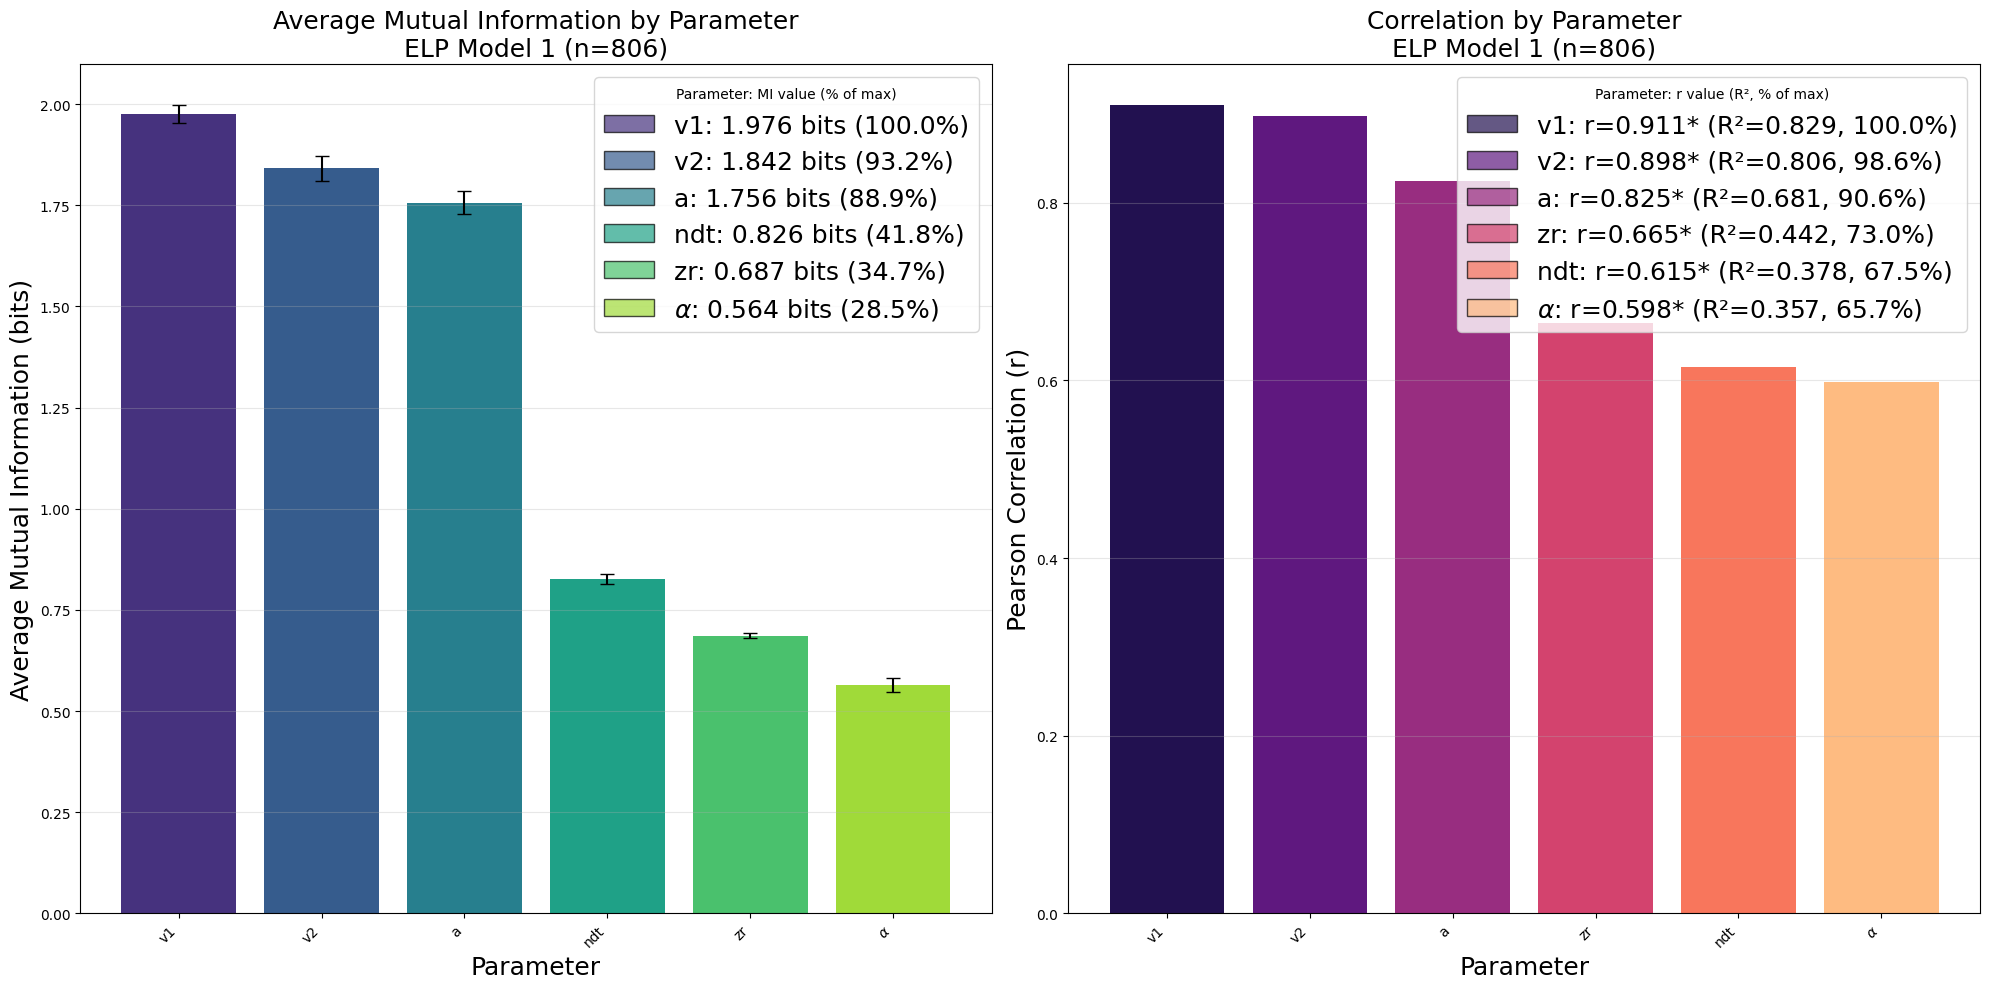


Comparison of MI and Correlation for ELP Model 1:


,Average MI (bits),MI Ratio (%),Correlation (r),R-squared,Corr Ratio (%),MI p-value,Corr p-value
v1,1.976387,100.000000,0.910543,0.829089,100.000000,0.000999,1.155752e-310
v2,1.841613,93.180770,0.897864,0.806159,98.607452,0.000999,1.118748e-288
a,1.756045,88.851250,0.825035,0.680683,90.609062,0.000999,1.697972e-201
ndt,0.825863,41.786514,0.615065,0.378305,67.549261,0.000999,4.757233e-85
zr,0.686610,34.740641,0.664740,0.441880,73.004805,0.000999,6.461902e-104
alpha,0.563831,28.528370,0.597826,0.357396,65.655993,0.000999,2.916054e-79



Results exported to results_ELP_Model_1 directory


/var/folders/pp/fzhfbv9573q1s621tfds29800000gn/T/ipykernel_58448/2131529323.py:315: RuntimeWarning: divide by zero encountered in log
  theoretical_mi = -0.5 * np.log(1 - r_range**2) / np.log(2)


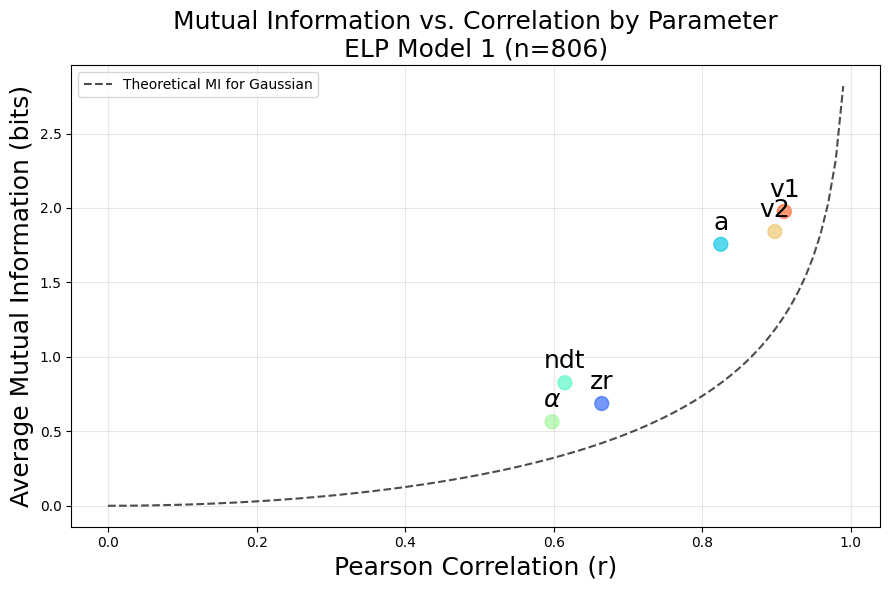

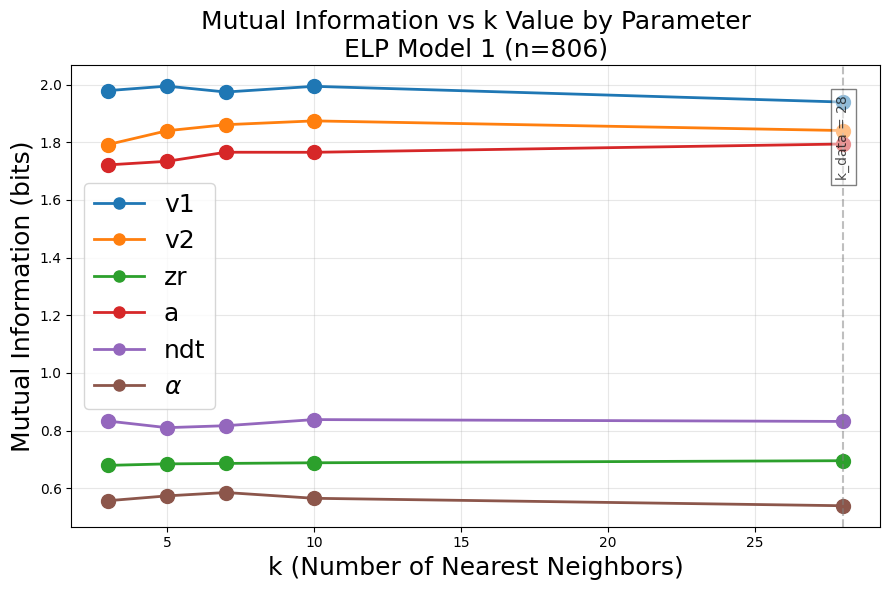

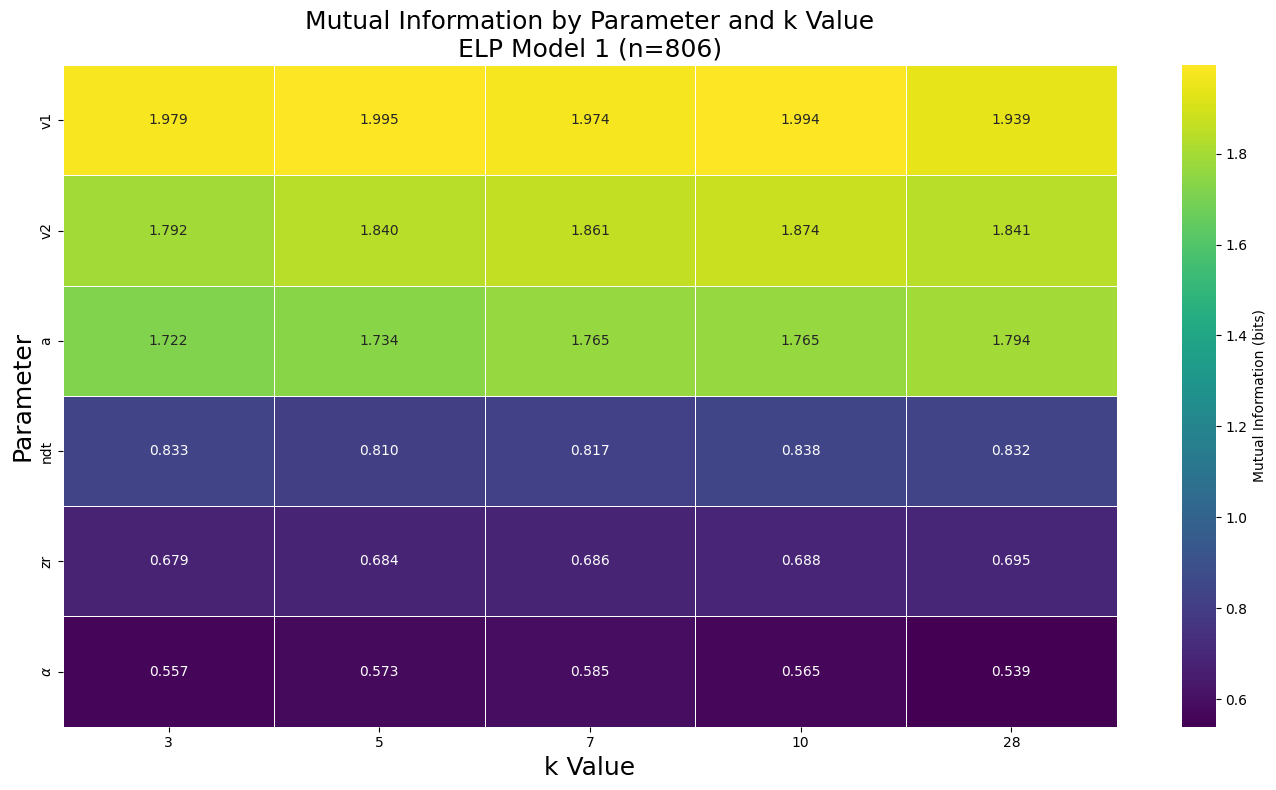

All analyses complete for ELP Model 1. Results saved to results_ELP_Model_1


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#plt.rcParams.update({'font.size': 16})  # 🔥 Add this line

from matplotlib.patches import Patch
from KSG_MI_First_reliability import KSGMutualInformationAnalyzer
from scipy import stats
import os

# Define the dataset name (modify this for different datasets)
Data_Name = "ELP Model 1"

# Define paths to your data files
session1_path = 'Model1 ELP/Transformed_recoverd_param_ELP_S1_second_100_2000_200_epoch_rt_acc_logAlphaSample.csv'
session2_path = 'Model1 ELP/Transformed_recoverd_param_ELP_S2_second_100_2000_200_epoch_rt_acc_logAlphaSample.csv'

# Create a clean name for file paths (replace spaces with underscores)
file_name_prefix = Data_Name.replace(' ', '_')
# Create output directory
output_dir = f"results_{file_name_prefix}"
os.makedirs(output_dir, exist_ok=True)

# Read the CSV files
df1 = pd.read_csv(session1_path)
df2 = pd.read_csv(session2_path)

print(f"Analyzing dataset: {Data_Name}")
print("Dataset 1 shape:", df1.shape)
print("Dataset 2 shape:", df2.shape)

# List the parameters to analyze
parameters = [
    'v1',
    'v2',
    'zr',
    'a',
    'ndt',
    # 'sndt_mean',
    'alpha',
    'alpha_mean_boxcox_after_arcsin'
]

display_names = {
    'v1': 'v1',
    'v2': 'v2',
    'zr': 'zr',
    'a': 'a',
    'ndt': 'ndt',
    # 'sndt_mean',
    'alpha': r'$\alpha$',
    'alpha_mean_boxcox_after_arcsin': r'$\alpha_T$',
    # Add other replacements if needed
}

# Function to apply display names
def get_display_name(param_name):
    return display_names.get(param_name, param_name)

# Find the common ID column
id_col = next((col for col in ['ID', 'participant', 'participant_ID' ] 
              if col in df1.columns and col in df2.columns), None)

print(f"Using identifier column: {id_col}")

# Create a new merged dataframe with only the columns we need
columns_to_keep1 = [id_col] + parameters
columns_to_keep2 = [id_col] + parameters

# Only keep columns that actually exist in the dataframes
columns_to_keep1 = [col for col in columns_to_keep1 if col in df1.columns]
columns_to_keep2 = [col for col in columns_to_keep2 if col in df2.columns]

# Create new dataframes with only needed columns
df1_subset = df1[columns_to_keep1].copy()
df2_subset = df2[columns_to_keep2].copy()

# Rename columns to add session suffix
for col in df1_subset.columns:
    if col != id_col:
        df1_subset = df1_subset.rename(columns={col: f"{col}_s1"})

for col in df2_subset.columns:
    if col != id_col:
        df2_subset = df2_subset.rename(columns={col: f"{col}_s2"})

# Merge the datasets
merged_df = pd.merge(df1_subset, df2_subset, on=id_col, how='inner')
print(f"Merged data shape: {merged_df.shape}")

# Define k values to analyze

# Calculate data-driven k (sqrt of sample size)
k_data_driven = int(np.sqrt(len(merged_df)))
k_values = [3, 5, 7, 10, k_data_driven]

if k_data_driven not in k_values:
    k_values.append(k_data_driven)
    k_values.sort()
    
print(f"Using k values: {k_values} (data-driven k = {k_data_driven})")

# Initialize the analyzer
analyzer = KSGMutualInformationAnalyzer(merged_df)

# Create parameter pairs
param_pairs = []
for param in parameters:
    s1 = f"{param}_s1"
    s2 = f"{param}_s2"
    if s1 in merged_df.columns and s2 in merged_df.columns:
        param_pairs.append((s1, s2, param))
    else:
        if s1 not in merged_df.columns:
            print(f"Warning: {s1} not found in merged dataset")
        if s2 not in merged_df.columns:
            print(f"Warning: {s2} not found in merged dataset")

print(f"Found {len(param_pairs)} valid parameter pairs")

# Calculate MI across k values and correlation for each parameter
all_mi_results = {}
correlation_results = {}

for s1, s2, param_name in param_pairs:
    print(f"\nAnalyzing {param_name} across k values...")
    
    # Calculate MI for different k values
    mi_results = analyzer.analyze_across_k_values(
        param1=s1,
        param2=s2,
        k_values=k_values,
        n_permutations=1000  # Reduced for faster results
    )
    all_mi_results[param_name] = mi_results
    
    # Calculate correlation (Pearson's r)
    if s1 in merged_df.columns and s2 in merged_df.columns:
        x = merged_df[s1].values
        y = merged_df[s2].values
        
        # Skip if any NaN values
        if np.isnan(x).any() or np.isnan(y).any():
            print(f"Skipping correlation for {param_name} due to NaN values")
            continue
            
        r, p_value = stats.pearsonr(x, y)
        correlation_results[param_name] = {
            'r': r,
            'p_value': p_value,
            'r_squared': r**2  # R-squared value
        }
        
        print(f"Correlation for {param_name}: r = {r:.4f} (p={p_value:.4f}), R² = {r**2:.4f}")

# Create a detailed DataFrame with all MI values
mi_data = {}
for param_name, results in all_mi_results.items():
    mi_data[param_name] = {k: results[k]['mi'] for k in k_values if k in results}

# Convert to DataFrame
mi_df = pd.DataFrame(mi_data).T

# Add average MI column
mi_df['Average'] = mi_df.mean(axis=1)

# Create correlation DataFrame
corr_df = pd.DataFrame({
    'r': {k: v['r'] for k, v in correlation_results.items()},
    'p_value': {k: v['p_value'] for k, v in correlation_results.items()},
    'r_squared': {k: v['r_squared'] for k, v in correlation_results.items()}
})

# Sort DataFrames by their respective metrics
mi_df = mi_df.sort_values('Average', ascending=False)
corr_df = corr_df.sort_values('r', ascending=False)

# Find maximum values
max_avg_mi = mi_df['Average'].max()
max_corr = corr_df['r'].max()

# Calculate ratios to maximum
mi_df['Ratio to Max'] = mi_df['Average'] / max_avg_mi * 100
corr_df['Ratio to Max'] = corr_df['r'] / max_corr * 100

# Create a figure with two subplots side by side
plt.figure(figsize=(20, 10))

# Plot 1: MI bar chart (left)
plt.subplot(1, 2, 1)
mi_colors = sns.color_palette("viridis", len(mi_df))
mi_bars = plt.bar(range(len(mi_df)), mi_df['Average'], color=mi_colors)

# Add error bars showing standard deviation across k values
for i, param in enumerate(mi_df.index):
    std_dev = mi_df.loc[param, k_values].std()
    plt.errorbar(i, mi_df.loc[param, 'Average'], yerr=std_dev, 
                 fmt='none', color='black', capsize=5)

# Customize MI plot
plt.xlabel('Parameter', fontsize=18)
plt.ylabel('Average Mutual Information (bits)', fontsize=18)
plt.title(f'Average Mutual Information by Parameter\n{Data_Name} (n={len(merged_df)})', fontsize=18)
# Use display names for x-axis labels
plt.xticks(range(len(mi_df)), [get_display_name(param) for param in mi_df.index], rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Create MI legend
mi_legend_elements = []
mi_legend_labels = []

for i, param in enumerate(mi_df.index):
    avg = mi_df.loc[param, 'Average']
    ratio = mi_df.loc[param, 'Ratio to Max']
    
    # Create color patch for legend
    mi_legend_elements.append(Patch(facecolor=mi_colors[i], edgecolor='black', alpha=0.7))
    
    # Create label with display parameter name, MI value and percentage
    mi_legend_labels.append(f"{get_display_name(param)}: {avg:.3f} bits ({ratio:.1f}%)")

# Add MI legend
plt.legend(mi_legend_elements, mi_legend_labels, 
           title="Parameter: MI value (% of max)",
           loc='upper right',
           frameon=True,
           fontsize=18)

# Plot 2: Correlation bar chart (right)
plt.subplot(1, 2, 2)
corr_colors = sns.color_palette("magma", len(corr_df))
corr_bars = plt.bar(range(len(corr_df)), corr_df['r'], color=corr_colors)

# Customize correlation plot
plt.xlabel('Parameter', fontsize=18)
plt.ylabel('Pearson Correlation (r)', fontsize=18)
plt.title(f'Correlation by Parameter\n{Data_Name} (n={len(merged_df)})', fontsize=18)
# Use display names for x-axis labels
plt.xticks(range(len(corr_df)), [get_display_name(param) for param in corr_df.index], rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Create correlation legend
corr_legend_elements = []
corr_legend_labels = []

for i, param in enumerate(corr_df.index):
    r = corr_df.loc[param, 'r']
    r_squared = corr_df.loc[param, 'r_squared']
    ratio = corr_df.loc[param, 'Ratio to Max']
    sig = '*' if corr_df.loc[param, 'p_value'] < 0.05 else ''
    
    # Create color patch for legend
    corr_legend_elements.append(Patch(facecolor=corr_colors[i], edgecolor='black', alpha=0.7))
    
    # Create label with display parameter name, r value, R² and percentage
    corr_legend_labels.append(f"{get_display_name(param)}: r={r:.3f}{sig} (R²={r_squared:.3f}, {ratio:.1f}%)")

# Add correlation legend
plt.legend(corr_legend_elements, corr_legend_labels, 
           title="Parameter: r value (R², % of max)",
           loc='upper right',
           frameon=True,
           fontsize=18)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, f'{file_name_prefix}_mi_vs_correlation_comparison.png'), bbox_inches='tight')
plt.show()

# Create a comparison DataFrame with both MI and correlation
comparison_df = pd.DataFrame({
    'Average MI (bits)': mi_df['Average'],
    'MI Ratio (%)': mi_df['Ratio to Max'],
    'Correlation (r)': corr_df['r'],
    'R-squared': corr_df['r_squared'],
    'Corr Ratio (%)': corr_df['Ratio to Max'],
    'MI p-value': {param: all_mi_results[param][k_data_driven]['p_value'] 
                   if param in all_mi_results and k_data_driven in all_mi_results[param] 
                   else np.nan 
                   for param in mi_df.index},
    'Corr p-value': corr_df['p_value']
})

# Sort by MI descending
comparison_df = comparison_df.sort_values('Average MI (bits)', ascending=False)

# Display the comparison table
print(f"\nComparison of MI and Correlation for {Data_Name}:")
display(comparison_df)

# Export results to CSV
comparison_df.to_csv(os.path.join(output_dir, f'{file_name_prefix}_mi_and_correlation_comparison.csv'))
print(f"\nResults exported to {output_dir} directory")

# Create a scatter plot of MI vs correlation
plt.figure(figsize=(9, 6))

# Extract correlation and MI values
params = list(set(mi_df.index) & set(corr_df.index))
mi_values = [mi_df.loc[param, 'Average'] for param in params]
corr_values = [corr_df.loc[param, 'r'] for param in params]
colors = sns.color_palette("rainbow", len(params))

# Create scatter plot with parameter labels
plt.scatter(corr_values, mi_values, s=100, c=colors, alpha=0.7)

# Use display names for annotation labels
for i, param in enumerate(params):
    plt.annotate(get_display_name(param), (corr_values[i], mi_values[i]), 
                 fontsize=18, ha='center', va='bottom',
                 xytext=(0, 7), textcoords='offset points')

# Add reference line for theoretical MI of Gaussian variables
r_range = np.linspace(0, 1, 100)
theoretical_mi = -0.5 * np.log(1 - r_range**2) / np.log(2)
plt.plot(r_range, theoretical_mi, 'k--', alpha=0.7, label='Theoretical MI for Gaussian')

plt.xlabel('Pearson Correlation (r)', fontsize=18)
plt.ylabel('Average Mutual Information (bits)', fontsize=18)
plt.title(f'Mutual Information vs. Correlation by Parameter\n{Data_Name} (n={len(merged_df)})', fontsize=18)
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.savefig(os.path.join(output_dir, f'{file_name_prefix}_mi_vs_correlation_scatter.png'))
plt.show()

# Create line plot of MI across k values
plt.figure(figsize=(9, 6))

for param_name, results in all_mi_results.items():
    k_vals = list(results.keys())
    mi_vals = [results[k]['mi'] for k in k_vals]
    p_vals = [results[k]['p_value'] for k in k_vals]
    
    # Plot line with display parameter name
    line, = plt.plot(k_vals, mi_vals, marker='o', linewidth=2, markersize=8, label=get_display_name(param_name))
    
    # Mark significant points with filled markers
    for i, (k, p) in enumerate(zip(k_vals, p_vals)):
        if p < 0.05:
            plt.plot(k, mi_vals[i], marker='o', markersize=10, color=line.get_color(), markerfacecolor=line.get_color())
        else:
            plt.plot(k, mi_vals[i], marker='o', markersize=8, color=line.get_color(), markerfacecolor='white')

# Add data-driven k line
plt.axvline(x=k_data_driven, color='gray', linestyle='--', alpha=0.5)
plt.text(k_data_driven, plt.ylim()[1]*0.95, f'k_data = {k_data_driven}', 
         ha='center', va='top', rotation=90, alpha=0.7,
         bbox=dict(facecolor='white', alpha=0.5))

plt.xlabel('k (Number of Nearest Neighbors)', fontsize=18)
plt.ylabel('Mutual Information (bits)', fontsize=18)
plt.title(f'Mutual Information vs k Value by Parameter\n{Data_Name} (n={len(merged_df)})', fontsize=18)
plt.grid(True, alpha=0.3)
plt.legend(loc='best', fontsize=18)
plt.tight_layout()

# Save the plot
plt.savefig(os.path.join(output_dir, f'{file_name_prefix}_mi_vs_k_all_parameters.png'))
plt.show()

# Create a heatmap of MI values by k
plt.figure(figsize=(14, 8))
k_cols = [col for col in mi_df.columns if isinstance(col, (int, float))]

# Create a copy of the DataFrame with display names for the index
heatmap_df = mi_df[k_cols].copy()
heatmap_df.index = [get_display_name(param) for param in heatmap_df.index]

# Use the modified DataFrame for the heatmap
sns.heatmap(heatmap_df, annot=True, fmt='.3f', cmap='viridis', 
            linewidths=0.5, cbar_kws={'label': 'Mutual Information (bits)'})
plt.title(f'Mutual Information by Parameter and k Value\n{Data_Name} (n={len(merged_df)})', fontsize=18)
plt.xlabel('k Value', fontsize=18)
plt.ylabel('Parameter', fontsize=18)
plt.tight_layout()

# Save the heatmap
plt.savefig(os.path.join(output_dir, f'{file_name_prefix}_mi_heatmap_by_parameter.png'))
plt.show()

print(f"All analyses complete for {Data_Name}. Results saved to {output_dir}")


Analyzing dataset: ELP Model 2
Dataset 1 shape: (806, 21)
Dataset 2 shape: (806, 21)
Using identifier column: participant
Merged data shape: (806, 11)
Using k values: [3, 5, 7, 10, 28] (data-driven k = 28)
Found 5 valid parameter pairs

Analyzing v1 across k values...
Parameters: v1_s1 - v1_s2, k=3
MI: 1.8298 bits (p=0.0010)
----------------------------------------
Parameters: v1_s1 - v1_s2, k=5
MI: 1.8977 bits (p=0.0010)
----------------------------------------
Parameters: v1_s1 - v1_s2, k=7
MI: 1.9277 bits (p=0.0010)
----------------------------------------
Parameters: v1_s1 - v1_s2, k=10
MI: 1.9459 bits (p=0.0010)
----------------------------------------
Parameters: v1_s1 - v1_s2, k=28
MI: 1.9820 bits (p=0.0010)
----------------------------------------
Correlation for v1: r = 0.8957 (p=0.0000), R² = 0.8022

Analyzing v2 across k values...
Parameters: v2_s1 - v2_s2, k=3
MI: 1.6405 bits (p=0.0010)
----------------------------------------
Parameters: v2_s1 - v2_s2, k=5
MI: 1.7065 bits 

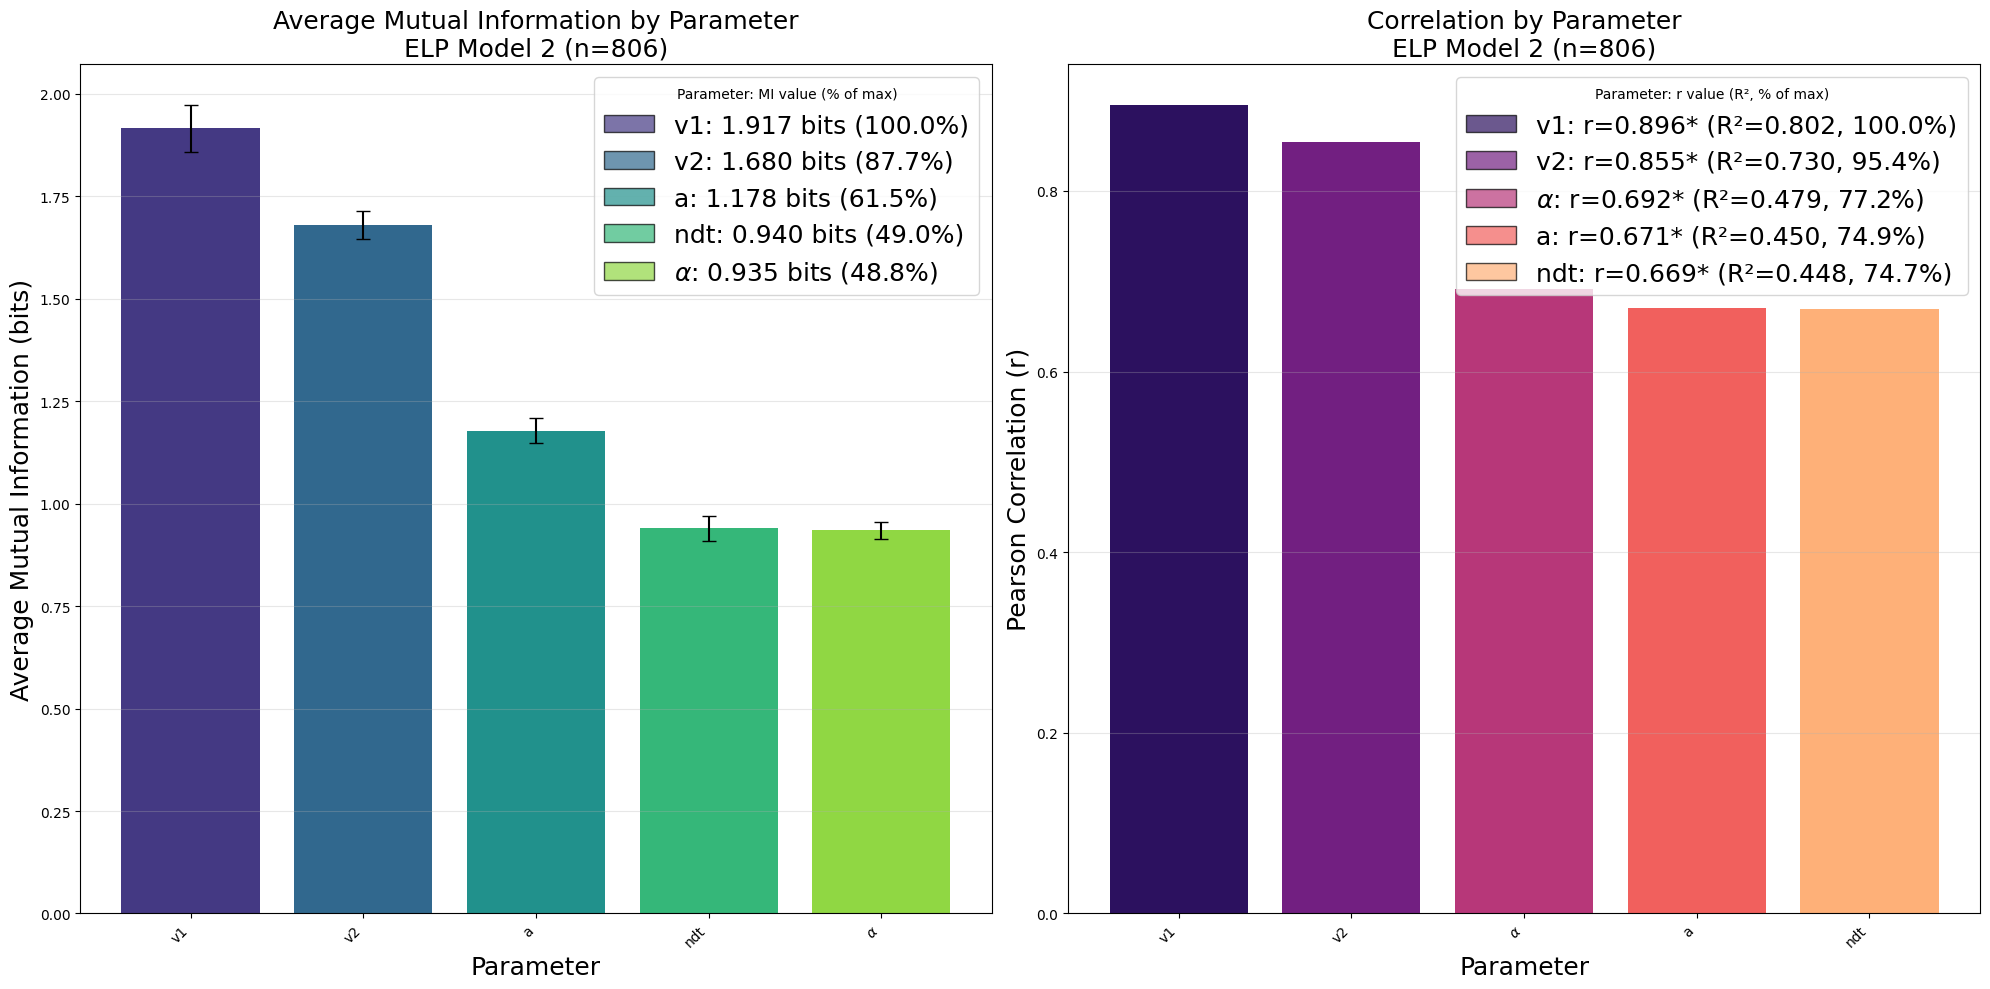


Comparison of MI and Correlation for ELP Model 2:


,Average MI (bits),MI Ratio (%),Correlation (r),R-squared,Corr Ratio (%),MI p-value,Corr p-value
v1,1.916622,100.000000,0.895668,0.802221,100.000000,0.000999,3.642562e-285
v2,1.680029,87.655715,0.854550,0.730256,95.409283,0.000999,5.751040e-231
a,1.178450,61.485781,0.670608,0.449715,74.872354,0.000999,2.179883e-106
ndt,0.939575,49.022435,0.669415,0.448116,74.739152,0.000999,7.009435e-106
alpha,0.934792,48.772868,0.691810,0.478601,77.239588,0.000999,8.145607e-116



Results exported to results_ELP_Model_2 directory


/var/folders/pp/fzhfbv9573q1s621tfds29800000gn/T/ipykernel_58448/2045540635.py:315: RuntimeWarning: divide by zero encountered in log
  theoretical_mi = -0.5 * np.log(1 - r_range**2) / np.log(2)


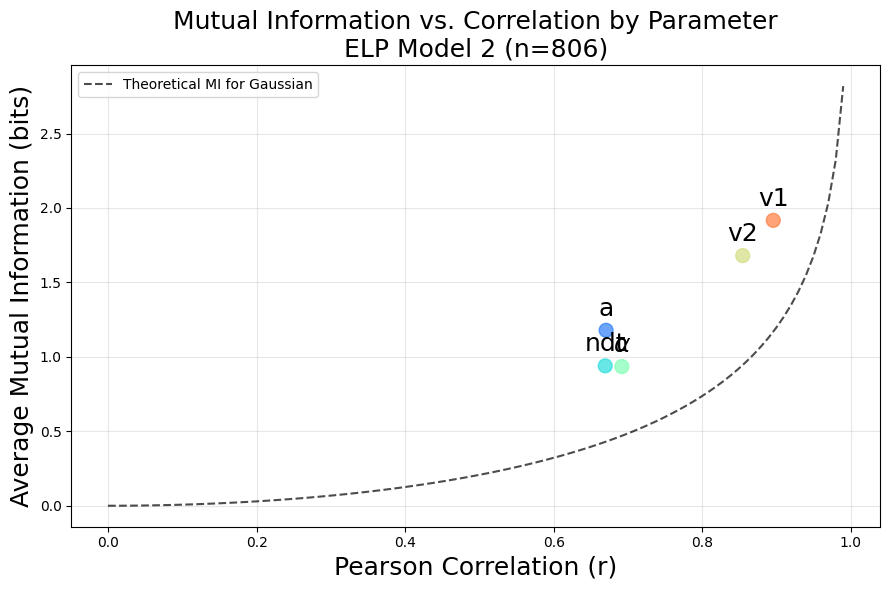

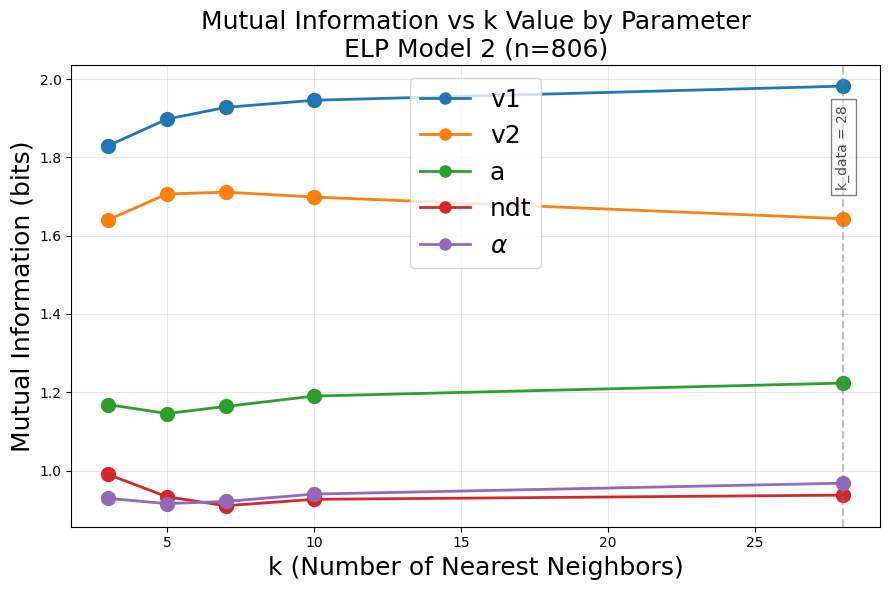

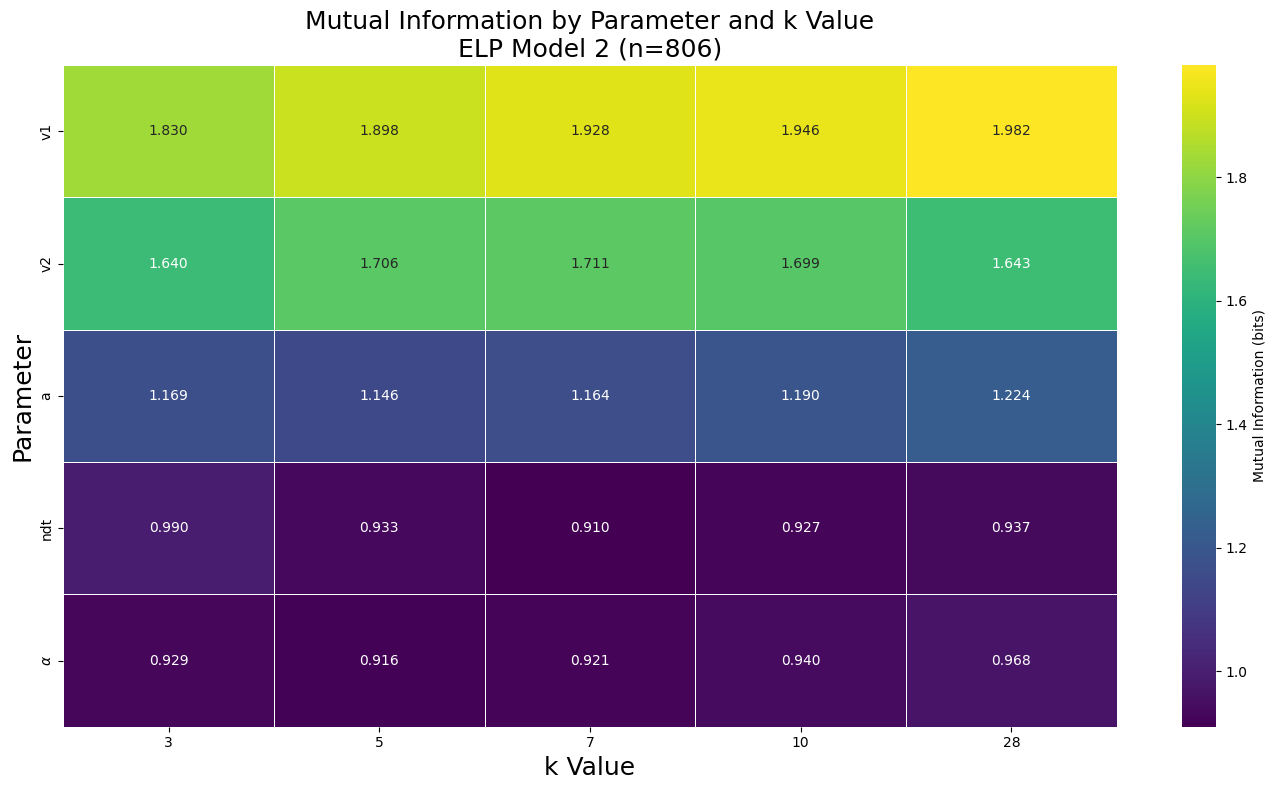

All analyses complete for ELP Model 2. Results saved to results_ELP_Model_2


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#plt.rcParams.update({'font.size': 16})  # 🔥 Add this line

from matplotlib.patches import Patch
from KSG_MI_First_reliability import KSGMutualInformationAnalyzer
from scipy import stats
import os

# Define the dataset name (modify this for different datasets)
Data_Name = "ELP Model 2"

# Define paths to your data files
session1_path = 'Model2 ELP/Transformed_recoverd_param_ELP_S1_second_100_2000_200_epoch_rt_acc_logAlphaSample.csv'
session2_path = 'Model2 ELP/Transformed_recoverd_param_ELP_S2_second_100_2000_200_epoch_rt_acc_logAlphaSample.csv'

# Create a clean name for file paths (replace spaces with underscores)
file_name_prefix = Data_Name.replace(' ', '_')
# Create output directory
output_dir = f"results_{file_name_prefix}"
os.makedirs(output_dir, exist_ok=True)

# Read the CSV files
df1 = pd.read_csv(session1_path)
df2 = pd.read_csv(session2_path)

print(f"Analyzing dataset: {Data_Name}")
print("Dataset 1 shape:", df1.shape)
print("Dataset 2 shape:", df2.shape)

# List the parameters to analyze
parameters = [
    'v1',
    'v2',
    'zr',
    'a',
    'ndt',
    # 'sndt_mean',
    'alpha',
    'alpha_mean_boxcox_after_arcsin'
]

display_names = {
    'v1': 'v1',
    'v2': 'v2',
    'zr': 'zr',
    'a': 'a',
    'ndt': 'ndt',
    # 'sndt_mean',
    'alpha': r'$\alpha$',
    'alpha_mean_boxcox_after_arcsin': r'$\alpha_T$',
    # Add other replacements if needed
}

# Function to apply display names
def get_display_name(param_name):
    return display_names.get(param_name, param_name)

# Find the common ID column
id_col = next((col for col in ['ID', 'participant', 'participant_ID' ] 
              if col in df1.columns and col in df2.columns), None)

print(f"Using identifier column: {id_col}")

# Create a new merged dataframe with only the columns we need
columns_to_keep1 = [id_col] + parameters
columns_to_keep2 = [id_col] + parameters

# Only keep columns that actually exist in the dataframes
columns_to_keep1 = [col for col in columns_to_keep1 if col in df1.columns]
columns_to_keep2 = [col for col in columns_to_keep2 if col in df2.columns]

# Create new dataframes with only needed columns
df1_subset = df1[columns_to_keep1].copy()
df2_subset = df2[columns_to_keep2].copy()

# Rename columns to add session suffix
for col in df1_subset.columns:
    if col != id_col:
        df1_subset = df1_subset.rename(columns={col: f"{col}_s1"})

for col in df2_subset.columns:
    if col != id_col:
        df2_subset = df2_subset.rename(columns={col: f"{col}_s2"})

# Merge the datasets
merged_df = pd.merge(df1_subset, df2_subset, on=id_col, how='inner')
print(f"Merged data shape: {merged_df.shape}")

# Define k values to analyze

# Calculate data-driven k (sqrt of sample size)
k_data_driven = int(np.sqrt(len(merged_df)))
k_values = [3, 5, 7, 10, k_data_driven]

if k_data_driven not in k_values:
    k_values.append(k_data_driven)
    k_values.sort()
    
print(f"Using k values: {k_values} (data-driven k = {k_data_driven})")

# Initialize the analyzer
analyzer = KSGMutualInformationAnalyzer(merged_df)

# Create parameter pairs
param_pairs = []
for param in parameters:
    s1 = f"{param}_s1"
    s2 = f"{param}_s2"
    if s1 in merged_df.columns and s2 in merged_df.columns:
        param_pairs.append((s1, s2, param))
    else:
        if s1 not in merged_df.columns:
            print(f"Warning: {s1} not found in merged dataset")
        if s2 not in merged_df.columns:
            print(f"Warning: {s2} not found in merged dataset")

print(f"Found {len(param_pairs)} valid parameter pairs")

# Calculate MI across k values and correlation for each parameter
all_mi_results = {}
correlation_results = {}

for s1, s2, param_name in param_pairs:
    print(f"\nAnalyzing {param_name} across k values...")
    
    # Calculate MI for different k values
    mi_results = analyzer.analyze_across_k_values(
        param1=s1,
        param2=s2,
        k_values=k_values,
        n_permutations=1000  # Reduced for faster results
    )
    all_mi_results[param_name] = mi_results
    
    # Calculate correlation (Pearson's r)
    if s1 in merged_df.columns and s2 in merged_df.columns:
        x = merged_df[s1].values
        y = merged_df[s2].values
        
        # Skip if any NaN values
        if np.isnan(x).any() or np.isnan(y).any():
            print(f"Skipping correlation for {param_name} due to NaN values")
            continue
            
        r, p_value = stats.pearsonr(x, y)
        correlation_results[param_name] = {
            'r': r,
            'p_value': p_value,
            'r_squared': r**2  # R-squared value
        }
        
        print(f"Correlation for {param_name}: r = {r:.4f} (p={p_value:.4f}), R² = {r**2:.4f}")

# Create a detailed DataFrame with all MI values
mi_data = {}
for param_name, results in all_mi_results.items():
    mi_data[param_name] = {k: results[k]['mi'] for k in k_values if k in results}

# Convert to DataFrame
mi_df = pd.DataFrame(mi_data).T

# Add average MI column
mi_df['Average'] = mi_df.mean(axis=1)

# Create correlation DataFrame
corr_df = pd.DataFrame({
    'r': {k: v['r'] for k, v in correlation_results.items()},
    'p_value': {k: v['p_value'] for k, v in correlation_results.items()},
    'r_squared': {k: v['r_squared'] for k, v in correlation_results.items()}
})

# Sort DataFrames by their respective metrics
mi_df = mi_df.sort_values('Average', ascending=False)
corr_df = corr_df.sort_values('r', ascending=False)

# Find maximum values
max_avg_mi = mi_df['Average'].max()
max_corr = corr_df['r'].max()

# Calculate ratios to maximum
mi_df['Ratio to Max'] = mi_df['Average'] / max_avg_mi * 100
corr_df['Ratio to Max'] = corr_df['r'] / max_corr * 100

# Create a figure with two subplots side by side
plt.figure(figsize=(20, 10))

# Plot 1: MI bar chart (left)
plt.subplot(1, 2, 1)
mi_colors = sns.color_palette("viridis", len(mi_df))
mi_bars = plt.bar(range(len(mi_df)), mi_df['Average'], color=mi_colors)

# Add error bars showing standard deviation across k values
for i, param in enumerate(mi_df.index):
    std_dev = mi_df.loc[param, k_values].std()
    plt.errorbar(i, mi_df.loc[param, 'Average'], yerr=std_dev, 
                 fmt='none', color='black', capsize=5)

# Customize MI plot
plt.xlabel('Parameter', fontsize=18)
plt.ylabel('Average Mutual Information (bits)', fontsize=18)
plt.title(f'Average Mutual Information by Parameter\n{Data_Name} (n={len(merged_df)})', fontsize=18)
# Use display names for x-axis labels
plt.xticks(range(len(mi_df)), [get_display_name(param) for param in mi_df.index], rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Create MI legend
mi_legend_elements = []
mi_legend_labels = []

for i, param in enumerate(mi_df.index):
    avg = mi_df.loc[param, 'Average']
    ratio = mi_df.loc[param, 'Ratio to Max']
    
    # Create color patch for legend
    mi_legend_elements.append(Patch(facecolor=mi_colors[i], edgecolor='black', alpha=0.7))
    
    # Create label with display parameter name, MI value and percentage
    mi_legend_labels.append(f"{get_display_name(param)}: {avg:.3f} bits ({ratio:.1f}%)")

# Add MI legend
plt.legend(mi_legend_elements, mi_legend_labels, 
           title="Parameter: MI value (% of max)",
           loc='upper right',
           frameon=True,
           fontsize=18)

# Plot 2: Correlation bar chart (right)
plt.subplot(1, 2, 2)
corr_colors = sns.color_palette("magma", len(corr_df))
corr_bars = plt.bar(range(len(corr_df)), corr_df['r'], color=corr_colors)

# Customize correlation plot
plt.xlabel('Parameter', fontsize=18)
plt.ylabel('Pearson Correlation (r)', fontsize=18)
plt.title(f'Correlation by Parameter\n{Data_Name} (n={len(merged_df)})', fontsize=18)
# Use display names for x-axis labels
plt.xticks(range(len(corr_df)), [get_display_name(param) for param in corr_df.index], rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Create correlation legend
corr_legend_elements = []
corr_legend_labels = []

for i, param in enumerate(corr_df.index):
    r = corr_df.loc[param, 'r']
    r_squared = corr_df.loc[param, 'r_squared']
    ratio = corr_df.loc[param, 'Ratio to Max']
    sig = '*' if corr_df.loc[param, 'p_value'] < 0.05 else ''
    
    # Create color patch for legend
    corr_legend_elements.append(Patch(facecolor=corr_colors[i], edgecolor='black', alpha=0.7))
    
    # Create label with display parameter name, r value, R² and percentage
    corr_legend_labels.append(f"{get_display_name(param)}: r={r:.3f}{sig} (R²={r_squared:.3f}, {ratio:.1f}%)")

# Add correlation legend
plt.legend(corr_legend_elements, corr_legend_labels, 
           title="Parameter: r value (R², % of max)",
           loc='upper right',
           frameon=True,
           fontsize=18)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, f'{file_name_prefix}_mi_vs_correlation_comparison.png'), bbox_inches='tight')
plt.show()

# Create a comparison DataFrame with both MI and correlation
comparison_df = pd.DataFrame({
    'Average MI (bits)': mi_df['Average'],
    'MI Ratio (%)': mi_df['Ratio to Max'],
    'Correlation (r)': corr_df['r'],
    'R-squared': corr_df['r_squared'],
    'Corr Ratio (%)': corr_df['Ratio to Max'],
    'MI p-value': {param: all_mi_results[param][k_data_driven]['p_value'] 
                   if param in all_mi_results and k_data_driven in all_mi_results[param] 
                   else np.nan 
                   for param in mi_df.index},
    'Corr p-value': corr_df['p_value']
})

# Sort by MI descending
comparison_df = comparison_df.sort_values('Average MI (bits)', ascending=False)

# Display the comparison table
print(f"\nComparison of MI and Correlation for {Data_Name}:")
display(comparison_df)

# Export results to CSV
comparison_df.to_csv(os.path.join(output_dir, f'{file_name_prefix}_mi_and_correlation_comparison.csv'))
print(f"\nResults exported to {output_dir} directory")

# Create a scatter plot of MI vs correlation
plt.figure(figsize=(9, 6))

# Extract correlation and MI values
params = list(set(mi_df.index) & set(corr_df.index))
mi_values = [mi_df.loc[param, 'Average'] for param in params]
corr_values = [corr_df.loc[param, 'r'] for param in params]
colors = sns.color_palette("rainbow", len(params))

# Create scatter plot with parameter labels
plt.scatter(corr_values, mi_values, s=100, c=colors, alpha=0.7)

# Use display names for annotation labels
for i, param in enumerate(params):
    plt.annotate(get_display_name(param), (corr_values[i], mi_values[i]), 
                 fontsize=18, ha='center', va='bottom',
                 xytext=(0, 7), textcoords='offset points')

# Add reference line for theoretical MI of Gaussian variables
r_range = np.linspace(0, 1, 100)
theoretical_mi = -0.5 * np.log(1 - r_range**2) / np.log(2)
plt.plot(r_range, theoretical_mi, 'k--', alpha=0.7, label='Theoretical MI for Gaussian')

plt.xlabel('Pearson Correlation (r)', fontsize=18)
plt.ylabel('Average Mutual Information (bits)', fontsize=18)
plt.title(f'Mutual Information vs. Correlation by Parameter\n{Data_Name} (n={len(merged_df)})', fontsize=18)
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.savefig(os.path.join(output_dir, f'{file_name_prefix}_mi_vs_correlation_scatter.png'))
plt.show()

# Create line plot of MI across k values
plt.figure(figsize=(9, 6))

for param_name, results in all_mi_results.items():
    k_vals = list(results.keys())
    mi_vals = [results[k]['mi'] for k in k_vals]
    p_vals = [results[k]['p_value'] for k in k_vals]
    
    # Plot line with display parameter name
    line, = plt.plot(k_vals, mi_vals, marker='o', linewidth=2, markersize=8, label=get_display_name(param_name))
    
    # Mark significant points with filled markers
    for i, (k, p) in enumerate(zip(k_vals, p_vals)):
        if p < 0.05:
            plt.plot(k, mi_vals[i], marker='o', markersize=10, color=line.get_color(), markerfacecolor=line.get_color())
        else:
            plt.plot(k, mi_vals[i], marker='o', markersize=8, color=line.get_color(), markerfacecolor='white')

# Add data-driven k line
plt.axvline(x=k_data_driven, color='gray', linestyle='--', alpha=0.5)
plt.text(k_data_driven, plt.ylim()[1]*0.95, f'k_data = {k_data_driven}', 
         ha='center', va='top', rotation=90, alpha=0.7,
         bbox=dict(facecolor='white', alpha=0.5))

plt.xlabel('k (Number of Nearest Neighbors)', fontsize=18)
plt.ylabel('Mutual Information (bits)', fontsize=18)
plt.title(f'Mutual Information vs k Value by Parameter\n{Data_Name} (n={len(merged_df)})', fontsize=18)
plt.grid(True, alpha=0.3)
plt.legend(loc='best', fontsize=18)
plt.tight_layout()

# Save the plot
plt.savefig(os.path.join(output_dir, f'{file_name_prefix}_mi_vs_k_all_parameters.png'))
plt.show()

# Create a heatmap of MI values by k
plt.figure(figsize=(14, 8))
k_cols = [col for col in mi_df.columns if isinstance(col, (int, float))]

# Create a copy of the DataFrame with display names for the index
heatmap_df = mi_df[k_cols].copy()
heatmap_df.index = [get_display_name(param) for param in heatmap_df.index]

# Use the modified DataFrame for the heatmap
sns.heatmap(heatmap_df, annot=True, fmt='.3f', cmap='viridis', 
            linewidths=0.5, cbar_kws={'label': 'Mutual Information (bits)'})
plt.title(f'Mutual Information by Parameter and k Value\n{Data_Name} (n={len(merged_df)})', fontsize=18)
plt.xlabel('k Value', fontsize=18)
plt.ylabel('Parameter', fontsize=18)
plt.tight_layout()

# Save the heatmap
plt.savefig(os.path.join(output_dir, f'{file_name_prefix}_mi_heatmap_by_parameter.png'))
plt.show()

print(f"All analyses complete for {Data_Name}. Results saved to {output_dir}")


Analyzing dataset: APT Model 1
Dataset 1 shape: (128, 37)
Dataset 2 shape: (128, 37)
Using identifier column: ID
Merged data shape: (128, 25)
Using k values: [3, 5, 7, 10, 11] (data-driven k = 11)
Found 12 valid parameter pairs

Analyzing alpha_mean_boxcox_after_arcsin across k values...
Parameters: alpha_mean_boxcox_after_arcsin_s1 - alpha_mean_boxcox_after_arcsin_s2, k=3
MI: 0.5013 bits (p=0.0020)
----------------------------------------
Parameters: alpha_mean_boxcox_after_arcsin_s1 - alpha_mean_boxcox_after_arcsin_s2, k=5
MI: 0.5826 bits (p=0.0010)
----------------------------------------
Parameters: alpha_mean_boxcox_after_arcsin_s1 - alpha_mean_boxcox_after_arcsin_s2, k=7
MI: 0.5990 bits (p=0.0010)
----------------------------------------
Parameters: alpha_mean_boxcox_after_arcsin_s1 - alpha_mean_boxcox_after_arcsin_s2, k=10
MI: 0.5582 bits (p=0.0010)
----------------------------------------
Parameters: alpha_mean_boxcox_after_arcsin_s1 - alpha_mean_boxcox_after_arcsin_s2, k=11
MI

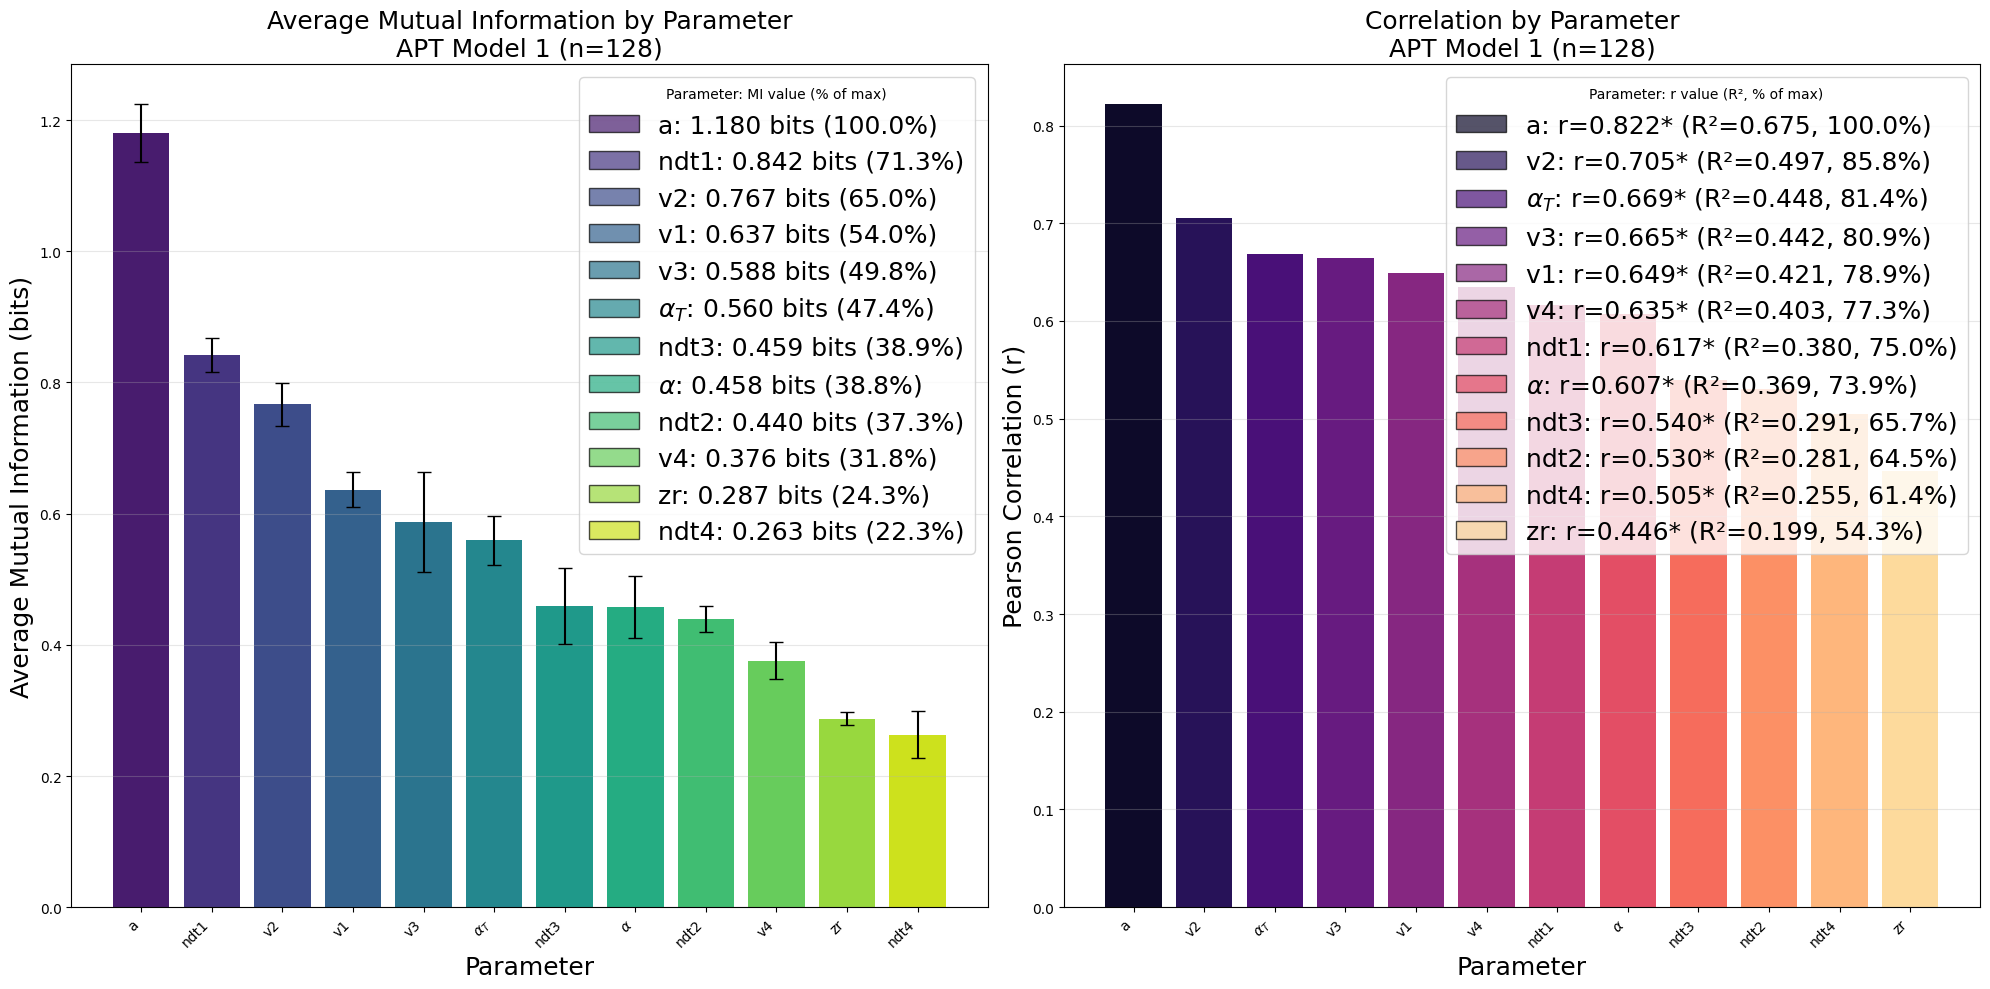


Comparison of MI and Correlation for APT Model 1:


,Average MI (bits),MI Ratio (%),Correlation (r),R-squared,Corr Ratio (%),MI p-value,Corr p-value
a_mean,1.179928,100.000000,0.821756,0.675283,100.000000,0.000999,1.443364e-32
ndt1_mean,0.841674,71.332690,0.616602,0.380198,75.034731,0.000999,9.277689e-15
v2_mean,0.766508,64.962239,0.705309,0.497461,85.829528,0.000999,1.488824e-20
v1_mean,0.636767,53.966573,0.648581,0.420657,78.926245,0.000999,1.256925e-16
v3_mean,0.587537,49.794278,0.664833,0.442003,80.903985,0.000999,1.152901e-17
alpha_mean_boxcox_after_arcsin,0.559533,47.420928,0.669023,0.447592,81.413893,0.000999,6.077411e-18
ndt3_mean,0.458720,38.876983,0.539880,0.291470,65.698333,0.000999,4.822355e-11
alpha_mean,0.457876,38.805445,0.607044,0.368502,73.871540,0.000999,3.058231e-14
ndt2_mean,0.439662,37.261768,0.529938,0.280834,64.488444,0.000999,1.254912e-10
v4_mean,0.375638,31.835681,0.635116,0.403373,77.287695,0.000999,8.174489e-16



Results exported to results_APT_Model_1 directory


/var/folders/pp/fzhfbv9573q1s621tfds29800000gn/T/ipykernel_58448/1901372342.py:334: RuntimeWarning: divide by zero encountered in log
  theoretical_mi = -0.5 * np.log(1 - r_range**2) / np.log(2)


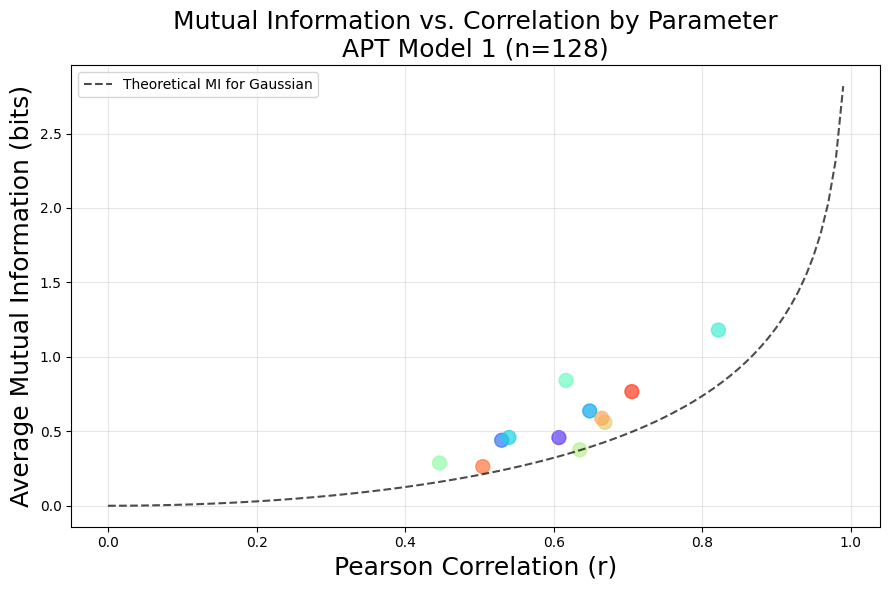

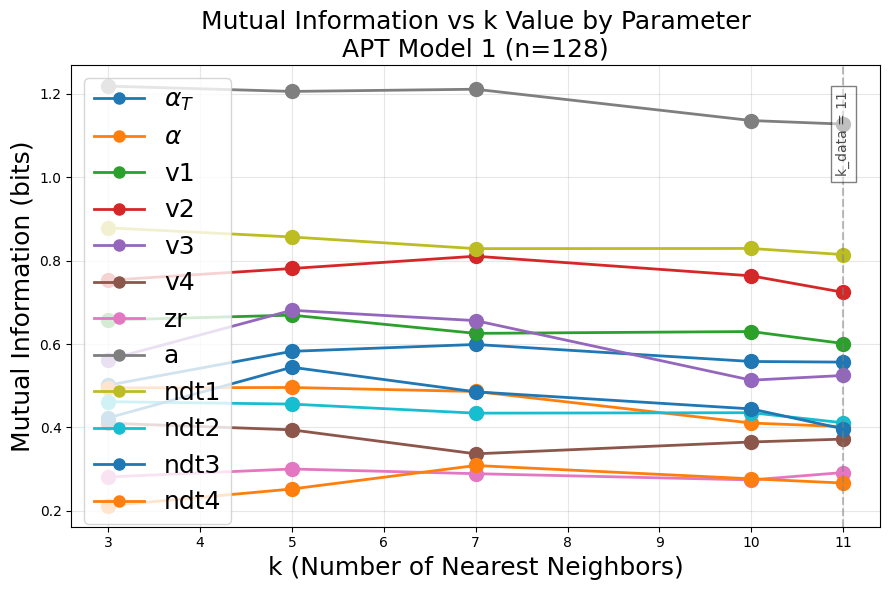

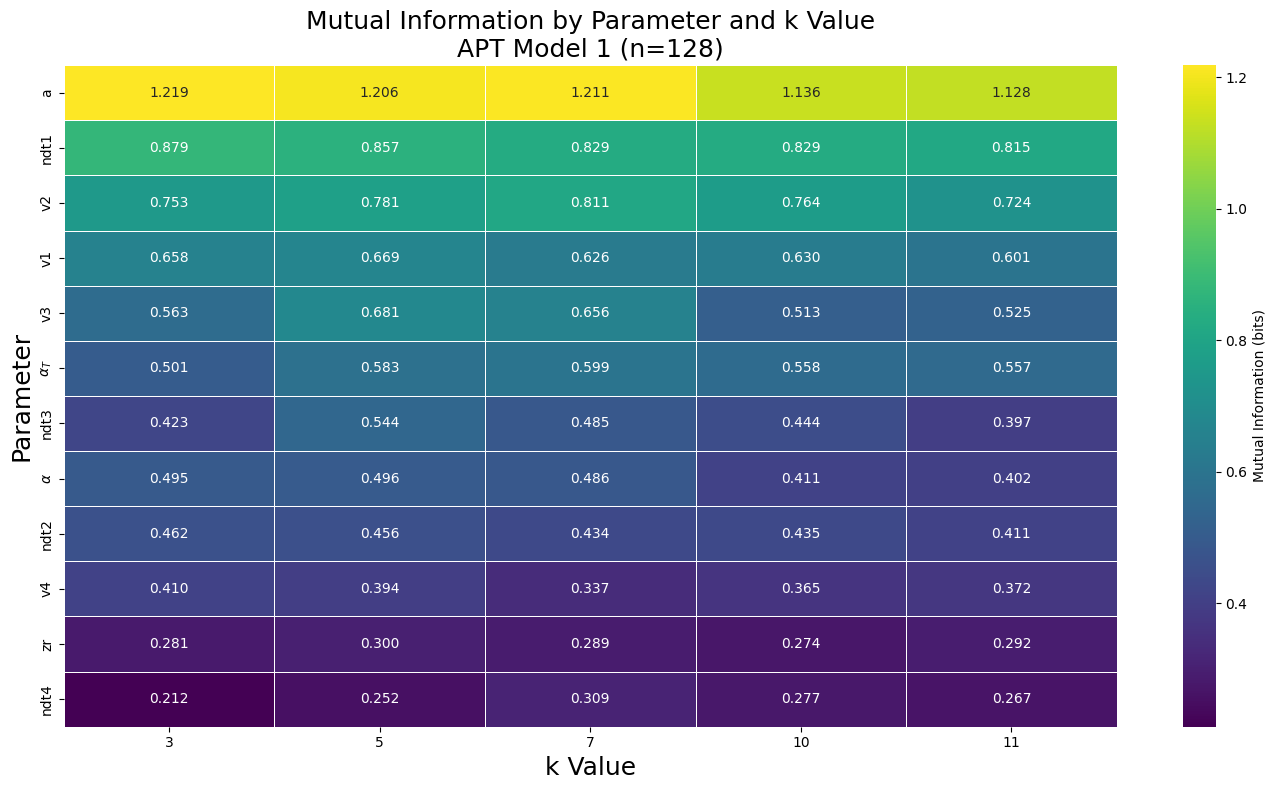

All analyses complete for APT Model 1. Results saved to results_APT_Model_1


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#plt.rcParams.update({'font.size': 16})  # 🔥 Add this line

from matplotlib.patches import Patch
from KSG_MI_First_reliability import KSGMutualInformationAnalyzer
from scipy import stats
import os

# Define the dataset name (modify this for different datasets)
Data_Name = "APT Model 1"

# Define paths to your data files
session1_path = 'Model1 APT/study2_associative_session_1_data_transformed.csv' # <--- CHANGE THIS
session2_path = 'Model1 APT/study2_associative_session_2_data_transformed.csv' # <--- CHANGE THIS

# Create a clean name for file paths (replace spaces with underscores)
file_name_prefix = Data_Name.replace(' ', '_')
# Create output directory
output_dir = f"results_{file_name_prefix}"
os.makedirs(output_dir, exist_ok=True)

# Read the CSV files
df1 = pd.read_csv(session1_path)
df2 = pd.read_csv(session2_path)

print(f"Analyzing dataset: {Data_Name}")
print("Dataset 1 shape:", df1.shape)
print("Dataset 2 shape:", df2.shape)

# List the parameters to analyze
parameters = [
    # Fallback if transformed not present
      'alpha_mean_boxcox_after_arcsin',
        'alpha_mean', # Fallback
        'v1_mean',
        'v2_mean',
        'v3_mean',
        'v4_mean',
        'zr_mean',
        'a_mean',
        'ndt1_mean',
        'ndt2_mean',
        'ndt3_mean',
        'ndt4_mean',
        # 'sndt_mean'
]

display_names = {
        'alpha_mean_boxcox_after_arcsin': r'$\alpha_T$',
        'alpha_mean': r'$\alpha$', # Fallback
        'v1_mean': 'v1',
        'v2_mean': 'v2',
        'v3_mean': 'v3',
        'v4_mean': 'v4',
        'zr_mean': 'zr',
        'a_mean': 'a',
        'ndt1_mean': 'ndt1',
        'ndt2_mean': 'ndt2',
        'ndt3_mean': 'ndt3',
        'ndt4_mean': 'ndt4',
        # 'sndt_mean': 'sndt'
    # Add other replacements if needed
}

# Function to apply display names
def get_display_name(param_name):
    return display_names.get(param_name, param_name)

# Find the common ID column
id_col = next((col for col in ['ID', 'participant', 'participant_ID' ] 
              if col in df1.columns and col in df2.columns), None)

print(f"Using identifier column: {id_col}")

# Create a new merged dataframe with only the columns we need
columns_to_keep1 = [id_col] + parameters
columns_to_keep2 = [id_col] + parameters

# Only keep columns that actually exist in the dataframes
columns_to_keep1 = [col for col in columns_to_keep1 if col in df1.columns]
columns_to_keep2 = [col for col in columns_to_keep2 if col in df2.columns]

# Create new dataframes with only needed columns
df1_subset = df1[columns_to_keep1].copy()
df2_subset = df2[columns_to_keep2].copy()

# Rename columns to add session suffix
for col in df1_subset.columns:
    if col != id_col:
        df1_subset = df1_subset.rename(columns={col: f"{col}_s1"})

for col in df2_subset.columns:
    if col != id_col:
        df2_subset = df2_subset.rename(columns={col: f"{col}_s2"})

# Merge the datasets
merged_df = pd.merge(df1_subset, df2_subset, on=id_col, how='inner')
print(f"Merged data shape: {merged_df.shape}")

# Define k values to analyze

# Calculate data-driven k (sqrt of sample size)
k_data_driven = int(np.sqrt(len(merged_df)))
k_values = [3, 5, 7, 10, k_data_driven]

if k_data_driven not in k_values:
    k_values.append(k_data_driven)
    k_values.sort()
    
print(f"Using k values: {k_values} (data-driven k = {k_data_driven})")

# Initialize the analyzer
analyzer = KSGMutualInformationAnalyzer(merged_df)

# Create parameter pairs
param_pairs = []
for param in parameters:
    s1 = f"{param}_s1"
    s2 = f"{param}_s2"
    if s1 in merged_df.columns and s2 in merged_df.columns:
        param_pairs.append((s1, s2, param))
    else:
        if s1 not in merged_df.columns:
            print(f"Warning: {s1} not found in merged dataset")
        if s2 not in merged_df.columns:
            print(f"Warning: {s2} not found in merged dataset")

print(f"Found {len(param_pairs)} valid parameter pairs")

# Calculate MI across k values and correlation for each parameter
all_mi_results = {}
correlation_results = {}

for s1, s2, param_name in param_pairs:
    print(f"\nAnalyzing {param_name} across k values...")
    
    # Calculate MI for different k values
    mi_results = analyzer.analyze_across_k_values(
        param1=s1,
        param2=s2,
        k_values=k_values,
        n_permutations=1000  # Reduced for faster results
    )
    all_mi_results[param_name] = mi_results
    
    # Calculate correlation (Pearson's r)
    if s1 in merged_df.columns and s2 in merged_df.columns:
        x = merged_df[s1].values
        y = merged_df[s2].values
        
        # Skip if any NaN values
        if np.isnan(x).any() or np.isnan(y).any():
            print(f"Skipping correlation for {param_name} due to NaN values")
            continue
            
        r, p_value = stats.pearsonr(x, y)
        correlation_results[param_name] = {
            'r': r,
            'p_value': p_value,
            'r_squared': r**2  # R-squared value
        }
        
        print(f"Correlation for {param_name}: r = {r:.4f} (p={p_value:.4f}), R² = {r**2:.4f}")

# Create a detailed DataFrame with all MI values
mi_data = {}
for param_name, results in all_mi_results.items():
    mi_data[param_name] = {k: results[k]['mi'] for k in k_values if k in results}

# Convert to DataFrame
mi_df = pd.DataFrame(mi_data).T

# Add average MI column
mi_df['Average'] = mi_df.mean(axis=1)

# Create correlation DataFrame
corr_df = pd.DataFrame({
    'r': {k: v['r'] for k, v in correlation_results.items()},
    'p_value': {k: v['p_value'] for k, v in correlation_results.items()},
    'r_squared': {k: v['r_squared'] for k, v in correlation_results.items()}
})

# Sort DataFrames by their respective metrics
mi_df = mi_df.sort_values('Average', ascending=False)
corr_df = corr_df.sort_values('r', ascending=False)

# Find maximum values
max_avg_mi = mi_df['Average'].max()
max_corr = corr_df['r'].max()

# Calculate ratios to maximum
mi_df['Ratio to Max'] = mi_df['Average'] / max_avg_mi * 100
corr_df['Ratio to Max'] = corr_df['r'] / max_corr * 100

# Create a figure with two subplots side by side
plt.figure(figsize=(20, 10))

# Plot 1: MI bar chart (left)
plt.subplot(1, 2, 1)
mi_colors = sns.color_palette("viridis", len(mi_df))
mi_bars = plt.bar(range(len(mi_df)), mi_df['Average'], color=mi_colors)

# Add error bars showing standard deviation across k values
for i, param in enumerate(mi_df.index):
    std_dev = mi_df.loc[param, k_values].std()
    plt.errorbar(i, mi_df.loc[param, 'Average'], yerr=std_dev, 
                 fmt='none', color='black', capsize=5)

# Customize MI plot
plt.xlabel('Parameter', fontsize=18)
plt.ylabel('Average Mutual Information (bits)', fontsize=18)
plt.title(f'Average Mutual Information by Parameter\n{Data_Name} (n={len(merged_df)})', fontsize=18)
# Use display names for x-axis labels
plt.xticks(range(len(mi_df)), [get_display_name(param) for param in mi_df.index], rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Create MI legend
mi_legend_elements = []
mi_legend_labels = []

for i, param in enumerate(mi_df.index):
    avg = mi_df.loc[param, 'Average']
    ratio = mi_df.loc[param, 'Ratio to Max']
    
    # Create color patch for legend
    mi_legend_elements.append(Patch(facecolor=mi_colors[i], edgecolor='black', alpha=0.7))
    
    # Create label with display parameter name, MI value and percentage
    mi_legend_labels.append(f"{get_display_name(param)}: {avg:.3f} bits ({ratio:.1f}%)")

# Add MI legend
plt.legend(mi_legend_elements, mi_legend_labels, 
           title="Parameter: MI value (% of max)",
           loc='upper right',
           frameon=True,
           fontsize=18)

# Plot 2: Correlation bar chart (right)
plt.subplot(1, 2, 2)
corr_colors = sns.color_palette("magma", len(corr_df))
corr_bars = plt.bar(range(len(corr_df)), corr_df['r'], color=corr_colors)

# Customize correlation plot
plt.xlabel('Parameter', fontsize=18)
plt.ylabel('Pearson Correlation (r)', fontsize=18)
plt.title(f'Correlation by Parameter\n{Data_Name} (n={len(merged_df)})', fontsize=18)
# Use display names for x-axis labels
plt.xticks(range(len(corr_df)), [get_display_name(param) for param in corr_df.index], rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Create correlation legend
corr_legend_elements = []
corr_legend_labels = []

for i, param in enumerate(corr_df.index):
    r = corr_df.loc[param, 'r']
    r_squared = corr_df.loc[param, 'r_squared']
    ratio = corr_df.loc[param, 'Ratio to Max']
    sig = '*' if corr_df.loc[param, 'p_value'] < 0.05 else ''
    
    # Create color patch for legend
    corr_legend_elements.append(Patch(facecolor=corr_colors[i], edgecolor='black', alpha=0.7))
    
    # Create label with display parameter name, r value, R² and percentage
    corr_legend_labels.append(f"{get_display_name(param)}: r={r:.3f}{sig} (R²={r_squared:.3f}, {ratio:.1f}%)")

# Add correlation legend
plt.legend(corr_legend_elements, corr_legend_labels, 
           title="Parameter: r value (R², % of max)",
           loc='upper right',
           frameon=True,
           fontsize=18)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, f'{file_name_prefix}_mi_vs_correlation_comparison.png'), bbox_inches='tight')
plt.show()

# Create a comparison DataFrame with both MI and correlation
comparison_df = pd.DataFrame({
    'Average MI (bits)': mi_df['Average'],
    'MI Ratio (%)': mi_df['Ratio to Max'],
    'Correlation (r)': corr_df['r'],
    'R-squared': corr_df['r_squared'],
    'Corr Ratio (%)': corr_df['Ratio to Max'],
    'MI p-value': {param: all_mi_results[param][k_data_driven]['p_value'] 
                   if param in all_mi_results and k_data_driven in all_mi_results[param] 
                   else np.nan 
                   for param in mi_df.index},
    'Corr p-value': corr_df['p_value']
})

# Sort by MI descending
comparison_df = comparison_df.sort_values('Average MI (bits)', ascending=False)

# Display the comparison table
print(f"\nComparison of MI and Correlation for {Data_Name}:")
display(comparison_df)

# Export results to CSV
comparison_df.to_csv(os.path.join(output_dir, f'{file_name_prefix}_mi_and_correlation_comparison.csv'))
print(f"\nResults exported to {output_dir} directory")

# Create a scatter plot of MI vs correlation
plt.figure(figsize=(9, 6))

# Extract correlation and MI values
params = [p for p in parameters if p in mi_df.index and p in corr_df.index]
mi_values = [mi_df.loc[param, 'Average'] for param in params]
corr_values = [corr_df.loc[param, 'r'] for param in params]
colors = sns.color_palette("rainbow", len(params))

# Create scatter plot with parameter labels
plt.scatter(corr_values, mi_values, s=100, c=colors, alpha=0.7)

# Use display names for annotation labels
# for i, param in enumerate(params):
#     plt.annotate(get_display_name(param), (corr_values[i], mi_values[i]), 
#                  fontsize=18, ha='center', va='bottom',
#                  xytext=(0, 7), textcoords='offset points')


from matplotlib.patches import Patch

# Create legend handles for parameters
param_legend_elements = [
    Patch(facecolor=colors[i], edgecolor='black', label=get_display_name(param))
    for i, param in enumerate(params)
]
# Add reference line for theoretical MI of Gaussian variables
r_range = np.linspace(0, 1, 100)
theoretical_mi = -0.5 * np.log(1 - r_range**2) / np.log(2)
plt.plot(r_range, theoretical_mi, 'k--', alpha=0.7, label='Theoretical MI for Gaussian')
# Second legend (parameter points)
plt.legend(handles=param_legend_elements,
           title="Parameters",
           loc='lower right',
           frameon=True,
           fontsize=18)

plt.xlabel('Pearson Correlation (r)', fontsize=18)
plt.ylabel('Average Mutual Information (bits)', fontsize=18)
plt.title(f'Mutual Information vs. Correlation by Parameter\n{Data_Name} (n={len(merged_df)})', fontsize=18)
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.savefig(os.path.join(output_dir, f'{file_name_prefix}_mi_vs_correlation_scatter.png'))
plt.show()

# Create line plot of MI across k values
plt.figure(figsize=(9, 6))

for param_name, results in all_mi_results.items():
    k_vals = list(results.keys())
    mi_vals = [results[k]['mi'] for k in k_vals]
    p_vals = [results[k]['p_value'] for k in k_vals]
    
    # Plot line with display parameter name
    line, = plt.plot(k_vals, mi_vals, marker='o', linewidth=2, markersize=8, label=get_display_name(param_name))
    
    # Mark significant points with filled markers
    for i, (k, p) in enumerate(zip(k_vals, p_vals)):
        if p < 0.05:
            plt.plot(k, mi_vals[i], marker='o', markersize=10, color=line.get_color(), markerfacecolor=line.get_color())
        else:
            plt.plot(k, mi_vals[i], marker='o', markersize=8, color=line.get_color(), markerfacecolor='white')

# Add data-driven k line
plt.axvline(x=k_data_driven, color='gray', linestyle='--', alpha=0.5)
plt.text(k_data_driven, plt.ylim()[1]*0.95, f'k_data = {k_data_driven}', 
         ha='center', va='top', rotation=90, alpha=0.7,
         bbox=dict(facecolor='white', alpha=0.5))

plt.xlabel('k (Number of Nearest Neighbors)', fontsize=18)
plt.ylabel('Mutual Information (bits)', fontsize=18)
plt.title(f'Mutual Information vs k Value by Parameter\n{Data_Name} (n={len(merged_df)})', fontsize=18)
plt.grid(True, alpha=0.3)
plt.legend(loc='best', fontsize=18)
plt.tight_layout()

# Save the plot
plt.savefig(os.path.join(output_dir, f'{file_name_prefix}_mi_vs_k_all_parameters.png'))
plt.show()

# Create a heatmap of MI values by k
plt.figure(figsize=(14, 8))
k_cols = [col for col in mi_df.columns if isinstance(col, (int, float))]

# Create a copy of the DataFrame with display names for the index
heatmap_df = mi_df[k_cols].copy()
heatmap_df.index = [get_display_name(param) for param in heatmap_df.index]

# Use the modified DataFrame for the heatmap
sns.heatmap(heatmap_df, annot=True, fmt='.3f', cmap='viridis', 
            linewidths=0.5, cbar_kws={'label': 'Mutual Information (bits)'})
plt.title(f'Mutual Information by Parameter and k Value\n{Data_Name} (n={len(merged_df)})', fontsize=18)
plt.xlabel('k Value', fontsize=18)
plt.ylabel('Parameter', fontsize=18)
plt.tight_layout()

# Save the heatmap
plt.savefig(os.path.join(output_dir, f'{file_name_prefix}_mi_heatmap_by_parameter.png'))
plt.show()

print(f"All analyses complete for {Data_Name}. Results saved to {output_dir}")


Analyzing dataset: APT Model 1
Dataset 1 shape: (128, 37)
Dataset 2 shape: (128, 37)
Using identifier column: ID
Merged data shape: (128, 25)
Using k values: [3, 5, 7, 10, 11] (data-driven k = 11)
Found 12 valid parameter pairs

Analyzing alpha_mean_boxcox_after_arcsin across k values...
Parameters: alpha_mean_boxcox_after_arcsin_s1 - alpha_mean_boxcox_after_arcsin_s2, k=3
MI: 0.5013 bits (p=0.0010)
----------------------------------------
Parameters: alpha_mean_boxcox_after_arcsin_s1 - alpha_mean_boxcox_after_arcsin_s2, k=5
MI: 0.5826 bits (p=0.0010)
----------------------------------------
Parameters: alpha_mean_boxcox_after_arcsin_s1 - alpha_mean_boxcox_after_arcsin_s2, k=7
MI: 0.5990 bits (p=0.0010)
----------------------------------------
Parameters: alpha_mean_boxcox_after_arcsin_s1 - alpha_mean_boxcox_after_arcsin_s2, k=10
MI: 0.5582 bits (p=0.0010)
----------------------------------------
Parameters: alpha_mean_boxcox_after_arcsin_s1 - alpha_mean_boxcox_after_arcsin_s2, k=11
MI

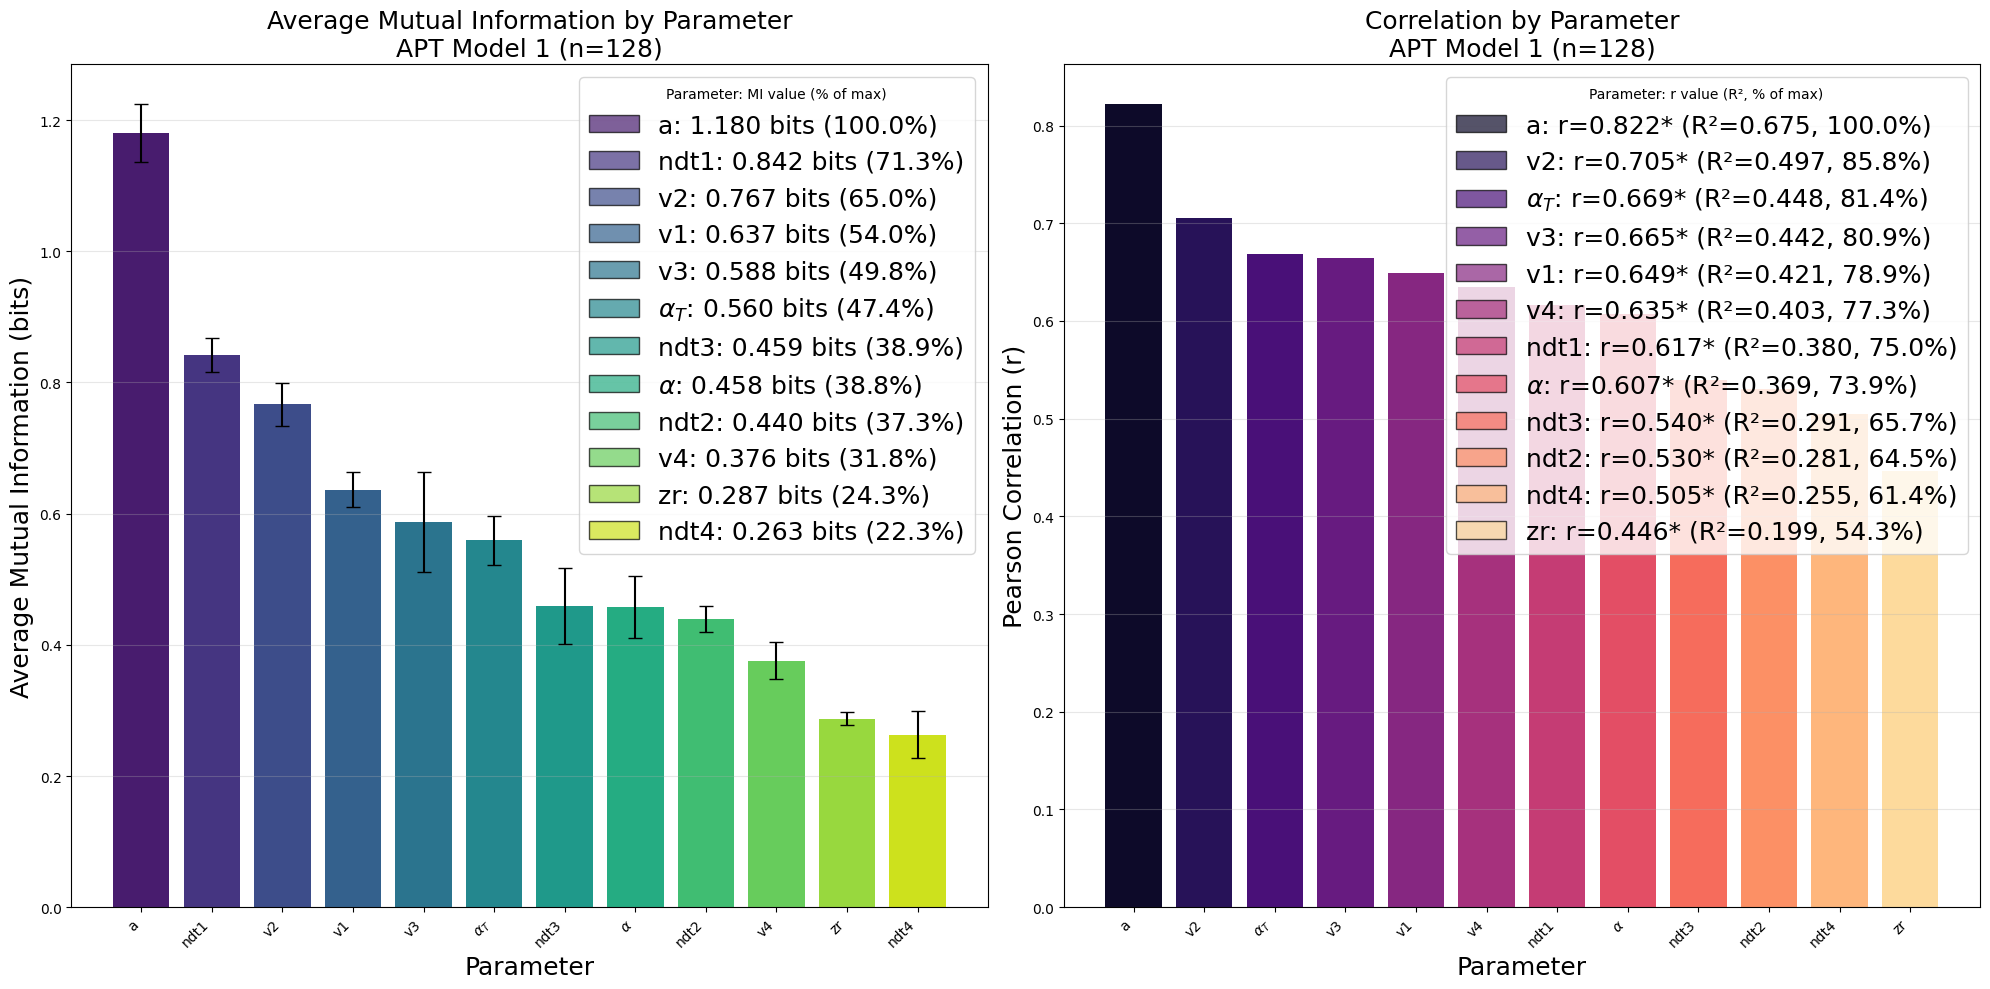


Comparison of MI and Correlation for APT Model 1:


,Average MI (bits),MI Ratio (%),Correlation (r),R-squared,Corr Ratio (%),MI p-value,Corr p-value
a_mean,1.179928,100.000000,0.821756,0.675283,100.000000,0.000999,1.443364e-32
ndt1_mean,0.841674,71.332690,0.616602,0.380198,75.034731,0.000999,9.277689e-15
v2_mean,0.766508,64.962239,0.705309,0.497461,85.829528,0.000999,1.488824e-20
v1_mean,0.636767,53.966573,0.648581,0.420657,78.926245,0.000999,1.256925e-16
v3_mean,0.587537,49.794278,0.664833,0.442003,80.903985,0.000999,1.152901e-17
alpha_mean_boxcox_after_arcsin,0.559533,47.420928,0.669023,0.447592,81.413893,0.000999,6.077411e-18
ndt3_mean,0.458720,38.876983,0.539880,0.291470,65.698333,0.000999,4.822355e-11
alpha_mean,0.457876,38.805445,0.607044,0.368502,73.871540,0.000999,3.058231e-14
ndt2_mean,0.439662,37.261768,0.529938,0.280834,64.488444,0.000999,1.254912e-10
v4_mean,0.375638,31.835681,0.635116,0.403373,77.287695,0.000999,8.174489e-16



Results exported to results_APT_Model_1 directory


/var/folders/pp/fzhfbv9573q1s621tfds29800000gn/T/ipykernel_58448/3195109828.py:337: RuntimeWarning: divide by zero encountered in log
  theoretical_mi = -0.5 * np.log(1 - r_range**2) / np.log(2)


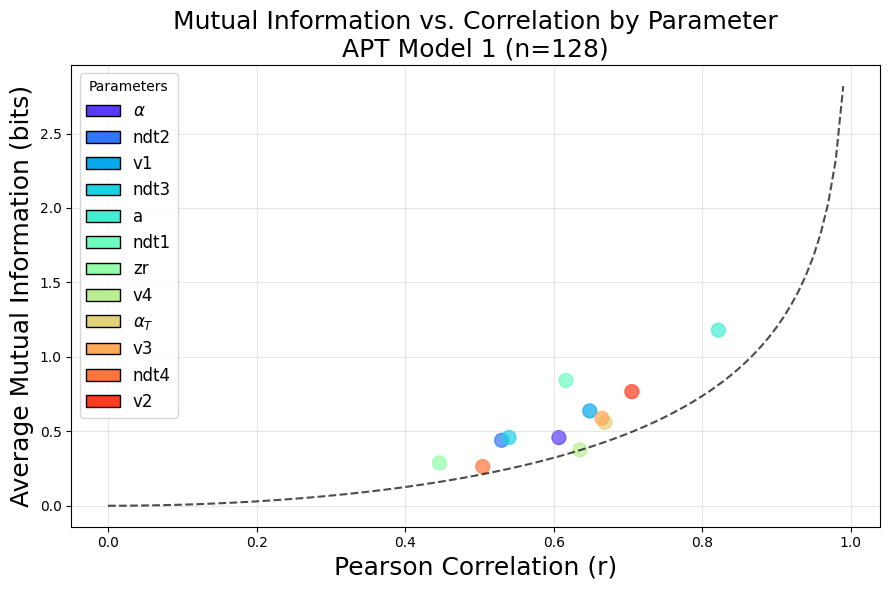

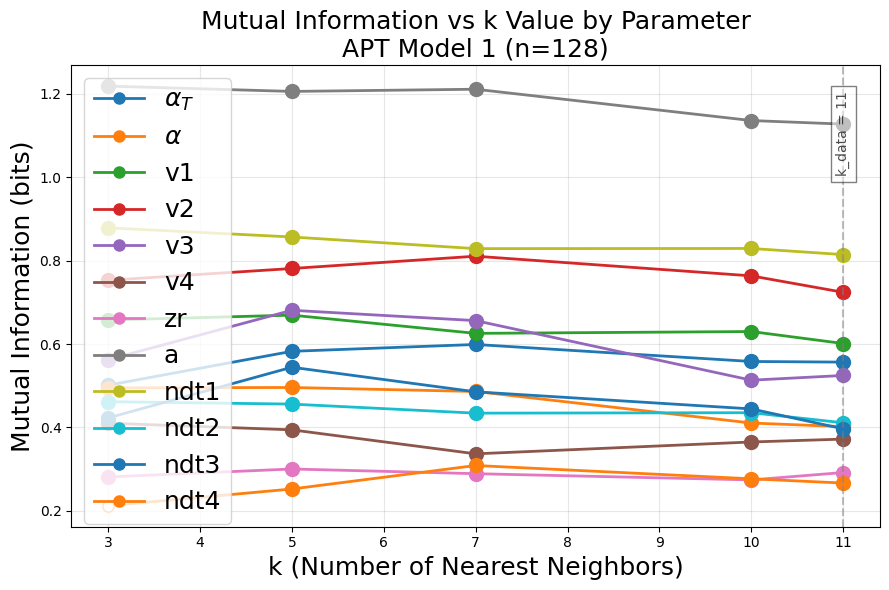

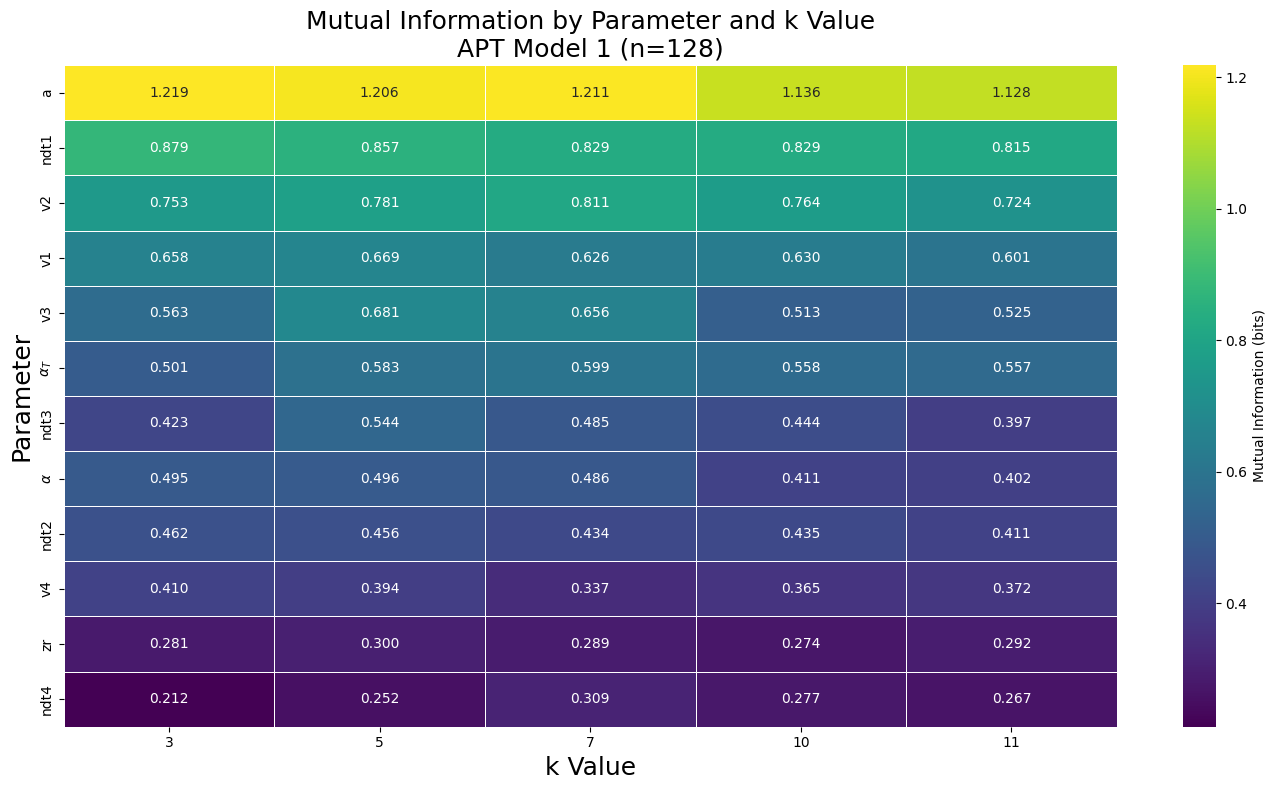

All analyses complete for APT Model 1. Results saved to results_APT_Model_1


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#plt.rcParams.update({'font.size': 16})  # 🔥 Add this line

from matplotlib.patches import Patch
from KSG_MI_First_reliability import KSGMutualInformationAnalyzer
from scipy import stats
import os

# Define the dataset name (modify this for different datasets)
Data_Name = "APT Model 1"

# Define paths to your data files
session1_path = 'Model1 APT/study2_associative_session_1_data_transformed.csv' # <--- CHANGE THIS
session2_path = 'Model1 APT/study2_associative_session_2_data_transformed.csv' # <--- CHANGE THIS

# Create a clean name for file paths (replace spaces with underscores)
file_name_prefix = Data_Name.replace(' ', '_')
# Create output directory
output_dir = f"results_{file_name_prefix}"
os.makedirs(output_dir, exist_ok=True)

# Read the CSV files
df1 = pd.read_csv(session1_path)
df2 = pd.read_csv(session2_path)

print(f"Analyzing dataset: {Data_Name}")
print("Dataset 1 shape:", df1.shape)
print("Dataset 2 shape:", df2.shape)

# List the parameters to analyze
parameters = [
    # Fallback if transformed not present
      'alpha_mean_boxcox_after_arcsin',
        'alpha_mean', # Fallback
        'v1_mean',
        'v2_mean',
        'v3_mean',
        'v4_mean',
        'zr_mean',
        'a_mean',
        'ndt1_mean',
        'ndt2_mean',
        'ndt3_mean',
        'ndt4_mean',
        # 'sndt_mean'
]

display_names = {
        'alpha_mean_boxcox_after_arcsin': r'$\alpha_T$',
        'alpha_mean': r'$\alpha$', # Fallback
        'v1_mean': 'v1',
        'v2_mean': 'v2',
        'v3_mean': 'v3',
        'v4_mean': 'v4',
        'zr_mean': 'zr',
        'a_mean': 'a',
        'ndt1_mean': 'ndt1',
        'ndt2_mean': 'ndt2',
        'ndt3_mean': 'ndt3',
        'ndt4_mean': 'ndt4',
        # 'sndt_mean': 'sndt'
    # Add other replacements if needed
}

# Function to apply display names
def get_display_name(param_name):
    return display_names.get(param_name, param_name)

# Find the common ID column
id_col = next((col for col in ['ID', 'participant', 'participant_ID' ] 
              if col in df1.columns and col in df2.columns), None)

print(f"Using identifier column: {id_col}")

# Create a new merged dataframe with only the columns we need
columns_to_keep1 = [id_col] + parameters
columns_to_keep2 = [id_col] + parameters

# Only keep columns that actually exist in the dataframes
columns_to_keep1 = [col for col in columns_to_keep1 if col in df1.columns]
columns_to_keep2 = [col for col in columns_to_keep2 if col in df2.columns]

# Create new dataframes with only needed columns
df1_subset = df1[columns_to_keep1].copy()
df2_subset = df2[columns_to_keep2].copy()

# Rename columns to add session suffix
for col in df1_subset.columns:
    if col != id_col:
        df1_subset = df1_subset.rename(columns={col: f"{col}_s1"})

for col in df2_subset.columns:
    if col != id_col:
        df2_subset = df2_subset.rename(columns={col: f"{col}_s2"})

# Merge the datasets
merged_df = pd.merge(df1_subset, df2_subset, on=id_col, how='inner')
print(f"Merged data shape: {merged_df.shape}")

# Define k values to analyze

# Calculate data-driven k (sqrt of sample size)
k_data_driven = int(np.sqrt(len(merged_df)))
k_values = [3, 5, 7, 10, k_data_driven]
#k_values = [3, 5, k_data_driven]


if k_data_driven not in k_values:
    k_values.append(k_data_driven)
    k_values.sort()
    
print(f"Using k values: {k_values} (data-driven k = {k_data_driven})")

# Initialize the analyzer
analyzer = KSGMutualInformationAnalyzer(merged_df)

# Create parameter pairs
param_pairs = []
for param in parameters:
    s1 = f"{param}_s1"
    s2 = f"{param}_s2"
    if s1 in merged_df.columns and s2 in merged_df.columns:
        param_pairs.append((s1, s2, param))
    else:
        if s1 not in merged_df.columns:
            print(f"Warning: {s1} not found in merged dataset")
        if s2 not in merged_df.columns:
            print(f"Warning: {s2} not found in merged dataset")

print(f"Found {len(param_pairs)} valid parameter pairs")

# Calculate MI across k values and correlation for each parameter
all_mi_results = {}
correlation_results = {}

for s1, s2, param_name in param_pairs:
    print(f"\nAnalyzing {param_name} across k values...")
    
    # Calculate MI for different k values
    mi_results = analyzer.analyze_across_k_values(
        param1=s1,
        param2=s2,
        k_values=k_values,
        n_permutations=1000  # Reduced for faster results
    )
    all_mi_results[param_name] = mi_results
    
    # Calculate correlation (Pearson's r)
    if s1 in merged_df.columns and s2 in merged_df.columns:
        x = merged_df[s1].values
        y = merged_df[s2].values
        
        # Skip if any NaN values
        if np.isnan(x).any() or np.isnan(y).any():
            print(f"Skipping correlation for {param_name} due to NaN values")
            continue
            
        r, p_value = stats.pearsonr(x, y)
        correlation_results[param_name] = {
            'r': r,
            'p_value': p_value,
            'r_squared': r**2  # R-squared value
        }
        
        print(f"Correlation for {param_name}: r = {r:.4f} (p={p_value:.4f}), R² = {r**2:.4f}")

# Create a detailed DataFrame with all MI values
mi_data = {}
for param_name, results in all_mi_results.items():
    mi_data[param_name] = {k: results[k]['mi'] for k in k_values if k in results}

# Convert to DataFrame
mi_df = pd.DataFrame(mi_data).T

# Add average MI column
mi_df['Average'] = mi_df.mean(axis=1)

# Create correlation DataFrame
corr_df = pd.DataFrame({
    'r': {k: v['r'] for k, v in correlation_results.items()},
    'p_value': {k: v['p_value'] for k, v in correlation_results.items()},
    'r_squared': {k: v['r_squared'] for k, v in correlation_results.items()}
})

# Sort DataFrames by their respective metrics
mi_df = mi_df.sort_values('Average', ascending=False)
corr_df = corr_df.sort_values('r', ascending=False)

# Find maximum values
max_avg_mi = mi_df['Average'].max()
max_corr = corr_df['r'].max()

# Calculate ratios to maximum
mi_df['Ratio to Max'] = mi_df['Average'] / max_avg_mi * 100
corr_df['Ratio to Max'] = corr_df['r'] / max_corr * 100

# Create a figure with two subplots side by side
plt.figure(figsize=(20, 10))

# Plot 1: MI bar chart (left)
plt.subplot(1, 2, 1)
mi_colors = sns.color_palette("viridis", len(mi_df))
mi_bars = plt.bar(range(len(mi_df)), mi_df['Average'], color=mi_colors)

# Add error bars showing standard deviation across k values
for i, param in enumerate(mi_df.index):
    std_dev = mi_df.loc[param, k_values].std()
    plt.errorbar(i, mi_df.loc[param, 'Average'], yerr=std_dev, 
                 fmt='none', color='black', capsize=5)

# Customize MI plot
plt.xlabel('Parameter', fontsize=18)
plt.ylabel('Average Mutual Information (bits)', fontsize=18)
plt.title(f'Average Mutual Information by Parameter\n{Data_Name} (n={len(merged_df)})', fontsize=18)
# Use display names for x-axis labels
plt.xticks(range(len(mi_df)), [get_display_name(param) for param in mi_df.index], rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Create MI legend
mi_legend_elements = []
mi_legend_labels = []

for i, param in enumerate(mi_df.index):
    avg = mi_df.loc[param, 'Average']
    ratio = mi_df.loc[param, 'Ratio to Max']
    
    # Create color patch for legend
    mi_legend_elements.append(Patch(facecolor=mi_colors[i], edgecolor='black', alpha=0.7))
    
    # Create label with display parameter name, MI value and percentage
    mi_legend_labels.append(f"{get_display_name(param)}: {avg:.3f} bits ({ratio:.1f}%)")

# Add MI legend
plt.legend(mi_legend_elements, mi_legend_labels, 
           title="Parameter: MI value (% of max)",
           loc='upper right',
           frameon=True,
           fontsize=18)

# Plot 2: Correlation bar chart (right)
plt.subplot(1, 2, 2)
corr_colors = sns.color_palette("magma", len(corr_df))
corr_bars = plt.bar(range(len(corr_df)), corr_df['r'], color=corr_colors)

# Customize correlation plot
plt.xlabel('Parameter', fontsize=18)
plt.ylabel('Pearson Correlation (r)', fontsize=18)
plt.title(f'Correlation by Parameter\n{Data_Name} (n={len(merged_df)})', fontsize=18)
# Use display names for x-axis labels
plt.xticks(range(len(corr_df)), [get_display_name(param) for param in corr_df.index], rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Create correlation legend
corr_legend_elements = []
corr_legend_labels = []

for i, param in enumerate(corr_df.index):
    r = corr_df.loc[param, 'r']
    r_squared = corr_df.loc[param, 'r_squared']
    ratio = corr_df.loc[param, 'Ratio to Max']
    sig = '*' if corr_df.loc[param, 'p_value'] < 0.05 else ''
    
    # Create color patch for legend
    corr_legend_elements.append(Patch(facecolor=corr_colors[i], edgecolor='black', alpha=0.7))
    
    # Create label with display parameter name, r value, R² and percentage
    corr_legend_labels.append(f"{get_display_name(param)}: r={r:.3f}{sig} (R²={r_squared:.3f}, {ratio:.1f}%)")

# Add correlation legend
plt.legend(corr_legend_elements, corr_legend_labels, 
           title="Parameter: r value (R², % of max)",
           loc='upper right',
           frameon=True,
           fontsize=18)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, f'{file_name_prefix}_mi_vs_correlation_comparison.png'), bbox_inches='tight')
plt.show()

# Create a comparison DataFrame with both MI and correlation
comparison_df = pd.DataFrame({
    'Average MI (bits)': mi_df['Average'],
    'MI Ratio (%)': mi_df['Ratio to Max'],
    'Correlation (r)': corr_df['r'],
    'R-squared': corr_df['r_squared'],
    'Corr Ratio (%)': corr_df['Ratio to Max'],
    'MI p-value': {param: all_mi_results[param][k_data_driven]['p_value'] 
                   if param in all_mi_results and k_data_driven in all_mi_results[param] 
                   else np.nan 
                   for param in mi_df.index},
    'Corr p-value': corr_df['p_value']
})

# Sort by MI descending
comparison_df = comparison_df.sort_values('Average MI (bits)', ascending=False)

# Display the comparison table
print(f"\nComparison of MI and Correlation for {Data_Name}:")
display(comparison_df)

# Export results to CSV
comparison_df.to_csv(os.path.join(output_dir, f'{file_name_prefix}_mi_and_correlation_comparison.csv'))
print(f"\nResults exported to {output_dir} directory")

# Create a scatter plot of MI vs correlation
plt.figure(figsize=(9, 6))

# Extract correlation and MI values
params = list(set(mi_df.index) & set(corr_df.index))
mi_values = [mi_df.loc[param, 'Average'] for param in params]
corr_values = [corr_df.loc[param, 'r'] for param in params]
colors = sns.color_palette("rainbow", len(params))

# Create scatter plot with parameter labels
plt.scatter(corr_values, mi_values, s=100, c=colors, alpha=0.7)

# Use display names for annotation labels
# for i, param in enumerate(params):
#     plt.annotate(get_display_name(param), (corr_values[i], mi_values[i]), 
#                  fontsize=18, ha='center', va='bottom',
#                  xytext=(0, 7), textcoords='offset points')


from matplotlib.patches import Patch
def get_display_name(param):
    return display_names.get(param, param)
# Create legend handles for parameters
param_legend_elements = [
    Patch(facecolor=colors[i], edgecolor='black', label=get_display_name(param))
    for i, param in enumerate(params)
]
# Add reference line for theoretical MI of Gaussian variables
r_range = np.linspace(0, 1, 100)
theoretical_mi = -0.5 * np.log(1 - r_range**2) / np.log(2)
plt.plot(r_range, theoretical_mi, 'k--', alpha=0.7, label='Theoretical MI for Gaussian')
# Second legend (parameter points)
plt.legend(handles=param_legend_elements,
           title="Parameters",
           loc='upper left',
           frameon=True,
           fontsize=12)

plt.xlabel('Pearson Correlation (r)', fontsize=18)
plt.ylabel('Average Mutual Information (bits)', fontsize=18)
plt.title(f'Mutual Information vs. Correlation by Parameter\n{Data_Name} (n={len(merged_df)})', fontsize=18)
plt.grid(True, alpha=0.3)
# plt.legend()

plt.tight_layout()
plt.savefig(os.path.join(output_dir, f'{file_name_prefix}_mi_vs_correlation_scatter.png'))
plt.show()

# Create line plot of MI across k values
plt.figure(figsize=(9, 6))

for param_name, results in all_mi_results.items():
    k_vals = list(results.keys())
    mi_vals = [results[k]['mi'] for k in k_vals]
    p_vals = [results[k]['p_value'] for k in k_vals]
    
    # Plot line with display parameter name
    line, = plt.plot(k_vals, mi_vals, marker='o', linewidth=2, markersize=8, label=get_display_name(param_name))
    
    # Mark significant points with filled markers
    for i, (k, p) in enumerate(zip(k_vals, p_vals)):
        if p < 0.05:
            plt.plot(k, mi_vals[i], marker='o', markersize=10, color=line.get_color(), markerfacecolor=line.get_color())
        else:
            plt.plot(k, mi_vals[i], marker='o', markersize=8, color=line.get_color(), markerfacecolor='white')

# Add data-driven k line
plt.axvline(x=k_data_driven, color='gray', linestyle='--', alpha=0.5)
plt.text(k_data_driven, plt.ylim()[1]*0.95, f'k_data = {k_data_driven}', 
         ha='center', va='top', rotation=90, alpha=0.7,
         bbox=dict(facecolor='white', alpha=0.5))

plt.xlabel('k (Number of Nearest Neighbors)', fontsize=18)
plt.ylabel('Mutual Information (bits)', fontsize=18)
plt.title(f'Mutual Information vs k Value by Parameter\n{Data_Name} (n={len(merged_df)})', fontsize=18)
plt.grid(True, alpha=0.3)
plt.legend(loc='best', fontsize=18)
plt.tight_layout()

# Save the plot
plt.savefig(os.path.join(output_dir, f'{file_name_prefix}_mi_vs_k_all_parameters.png'))
plt.show()

# Create a heatmap of MI values by k
plt.figure(figsize=(14, 8))
k_cols = [col for col in mi_df.columns if isinstance(col, (int, float))]

# Create a copy of the DataFrame with display names for the index
heatmap_df = mi_df[k_cols].copy()
heatmap_df.index = [get_display_name(param) for param in heatmap_df.index]

# Use the modified DataFrame for the heatmap
sns.heatmap(heatmap_df, annot=True, fmt='.3f', cmap='viridis', 
            linewidths=0.5, cbar_kws={'label': 'Mutual Information (bits)'})
plt.title(f'Mutual Information by Parameter and k Value\n{Data_Name} (n={len(merged_df)})', fontsize=18)
plt.xlabel('k Value', fontsize=18)
plt.ylabel('Parameter', fontsize=18)
plt.tight_layout()

# Save the heatmap
plt.savefig(os.path.join(output_dir, f'{file_name_prefix}_mi_heatmap_by_parameter.png'))
plt.show()

print(f"All analyses complete for {Data_Name}. Results saved to {output_dir}")


Analyzing dataset: APT Model 2
Dataset 1 shape: (128, 35)
Dataset 2 shape: (128, 35)
Using identifier column: ID
Merged data shape: (128, 23)
Using k values: [3, 5, 7, 10, 11] (data-driven k = 11)
Found 11 valid parameter pairs

Analyzing alpha_mean_boxcox_after_arcsin across k values...


Parameters: alpha_mean_boxcox_after_arcsin_s1 - alpha_mean_boxcox_after_arcsin_s2, k=3
MI: 0.5274 bits (p=0.0010)
----------------------------------------
Parameters: alpha_mean_boxcox_after_arcsin_s1 - alpha_mean_boxcox_after_arcsin_s2, k=5
MI: 0.6087 bits (p=0.0010)
----------------------------------------
Parameters: alpha_mean_boxcox_after_arcsin_s1 - alpha_mean_boxcox_after_arcsin_s2, k=7
MI: 0.7062 bits (p=0.0010)
----------------------------------------
Parameters: alpha_mean_boxcox_after_arcsin_s1 - alpha_mean_boxcox_after_arcsin_s2, k=10
MI: 0.7365 bits (p=0.0010)
----------------------------------------
Parameters: alpha_mean_boxcox_after_arcsin_s1 - alpha_mean_boxcox_after_arcsin_s2, k=11
MI: 0.7356 bits (p=0.0010)
----------------------------------------
Correlation for alpha_mean_boxcox_after_arcsin: r = 0.6949 (p=0.0000), R² = 0.4829

Analyzing alpha_mean across k values...
Parameters: alpha_mean_s1 - alpha_mean_s2, k=3
MI: 0.5108 bits (p=0.0010)
-------------------------

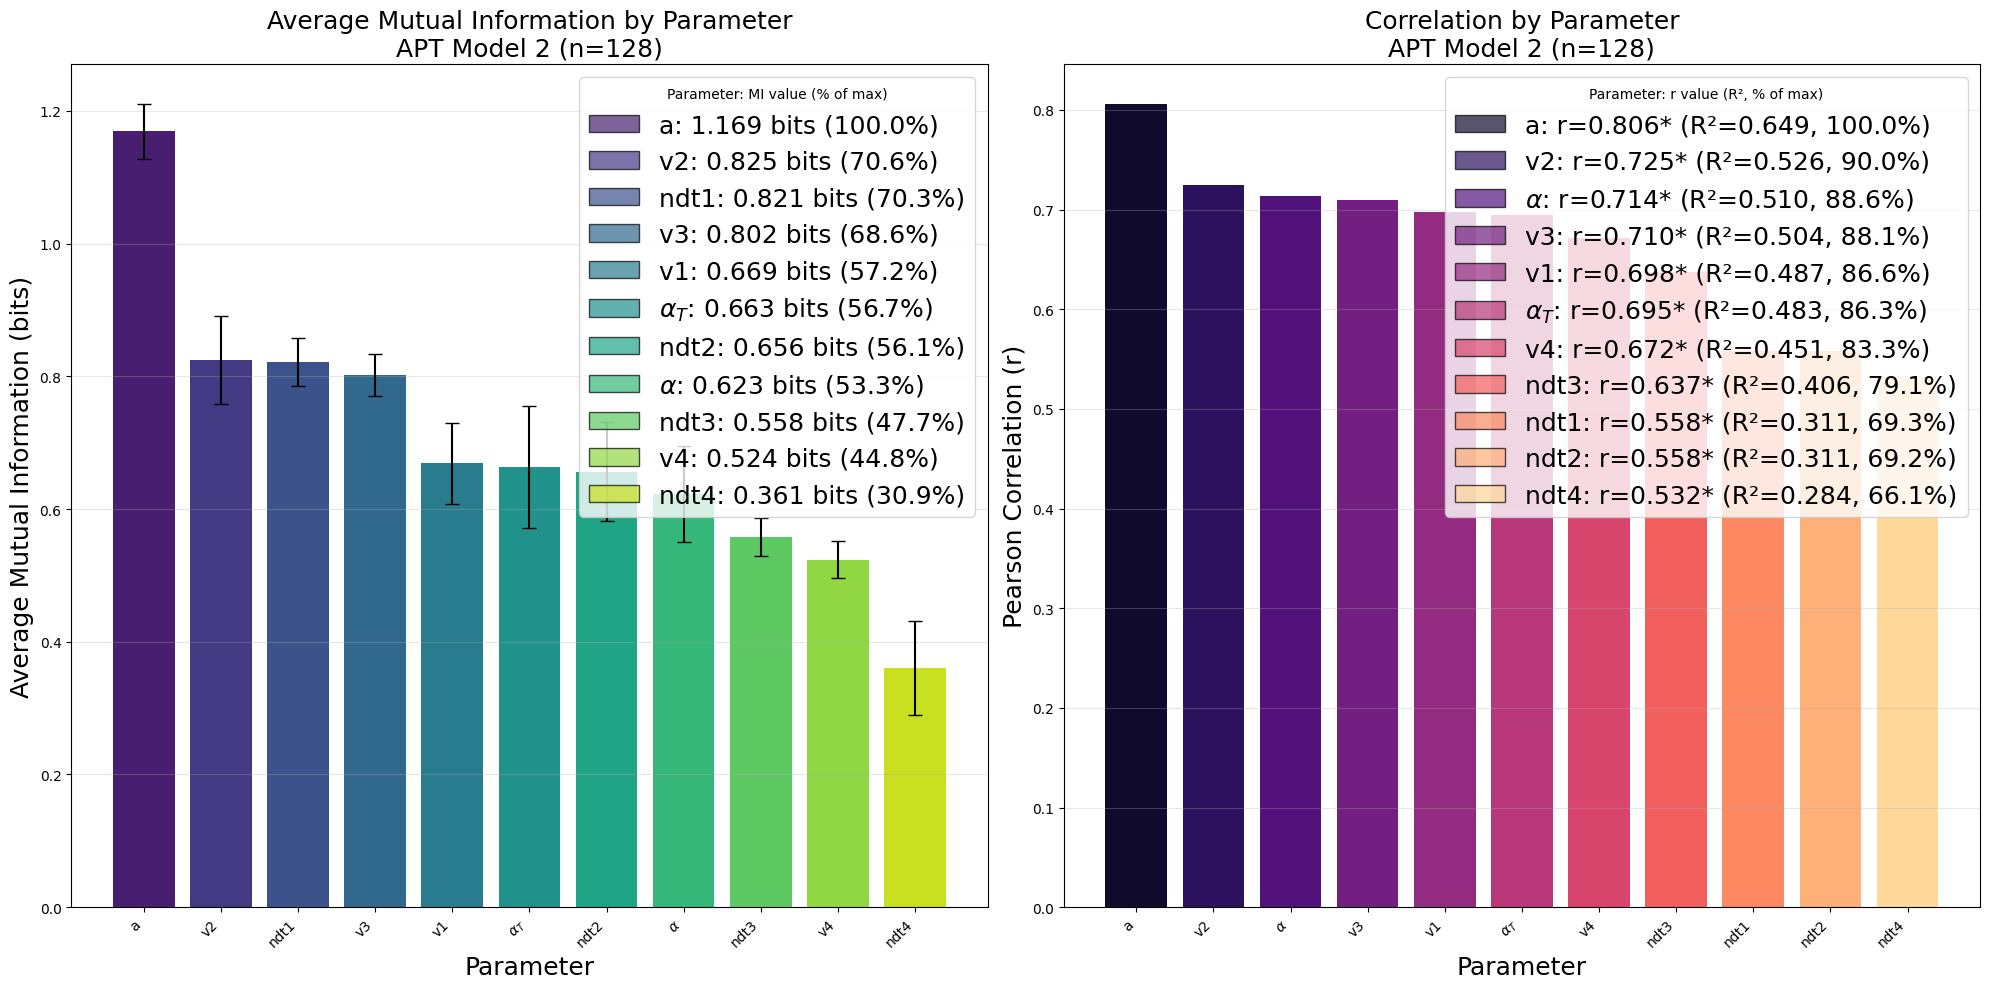


Comparison of MI and Correlation for APT Model 2:


,Average MI (bits),MI Ratio (%),Correlation (r),R-squared,Corr Ratio (%),MI p-value,Corr p-value
a_mean,1.169178,100.000000,0.805715,0.649176,100.000000,0.000999,1.920865e-30
v2_mean,0.824979,70.560610,0.725009,0.525638,89.983285,0.000999,3.823751e-22
ndt1_mean,0.821387,70.253371,0.558098,0.311474,69.267463,0.000999,7.690851e-12
v3_mean,0.801600,68.561009,0.710075,0.504207,88.129845,0.000999,6.313198e-21
v1_mean,0.669055,57.224360,0.697596,0.486640,86.580985,0.000999,5.759335e-20
alpha_mean_boxcox_after_arcsin,0.662872,56.695532,0.694943,0.482946,86.251760,0.000999,9.081193e-20
ndt2_mean,0.656145,56.120195,0.557659,0.310984,69.213002,0.000999,8.049126e-12
alpha_mean,0.622902,53.276867,0.713930,0.509695,88.608225,0.000999,3.114483e-21
ndt3_mean,0.558013,47.726895,0.637208,0.406034,79.086085,0.000999,6.148115e-16
v4_mean,0.523950,44.813558,0.671500,0.450913,83.342188,0.000999,4.142051e-18



Results exported to results_APT_Model_2 directory


/var/folders/pp/fzhfbv9573q1s621tfds29800000gn/T/ipykernel_58448/2356822798.py:337: RuntimeWarning: divide by zero encountered in log
  theoretical_mi = -0.5 * np.log(1 - r_range**2) / np.log(2)


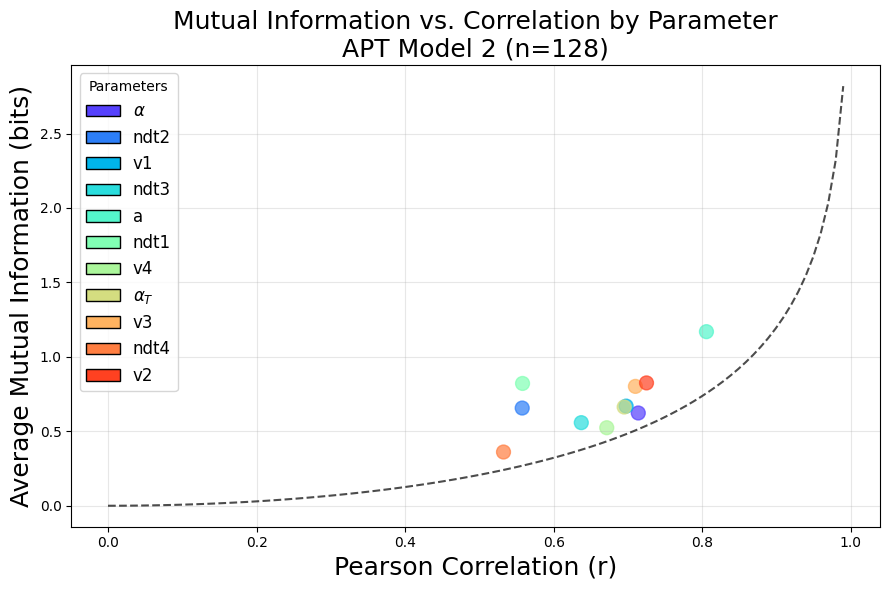

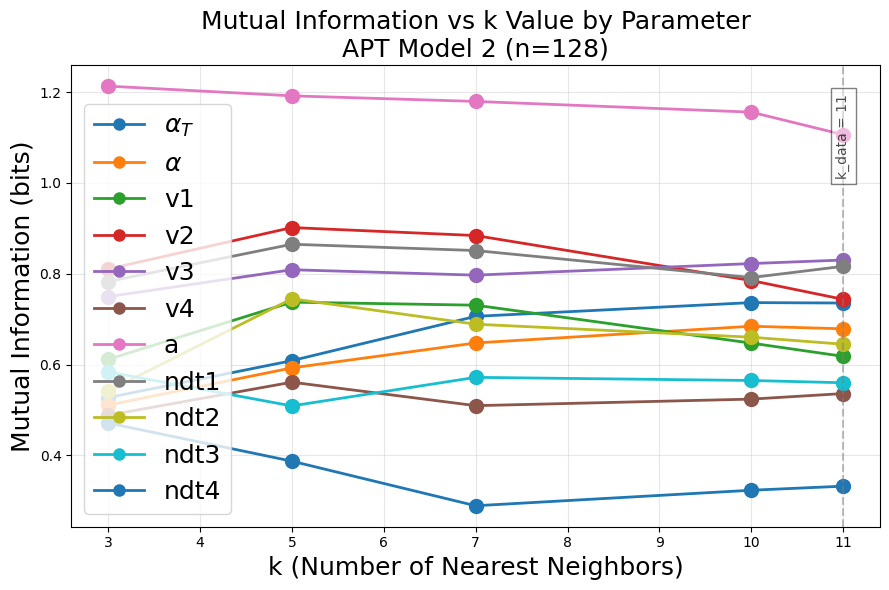

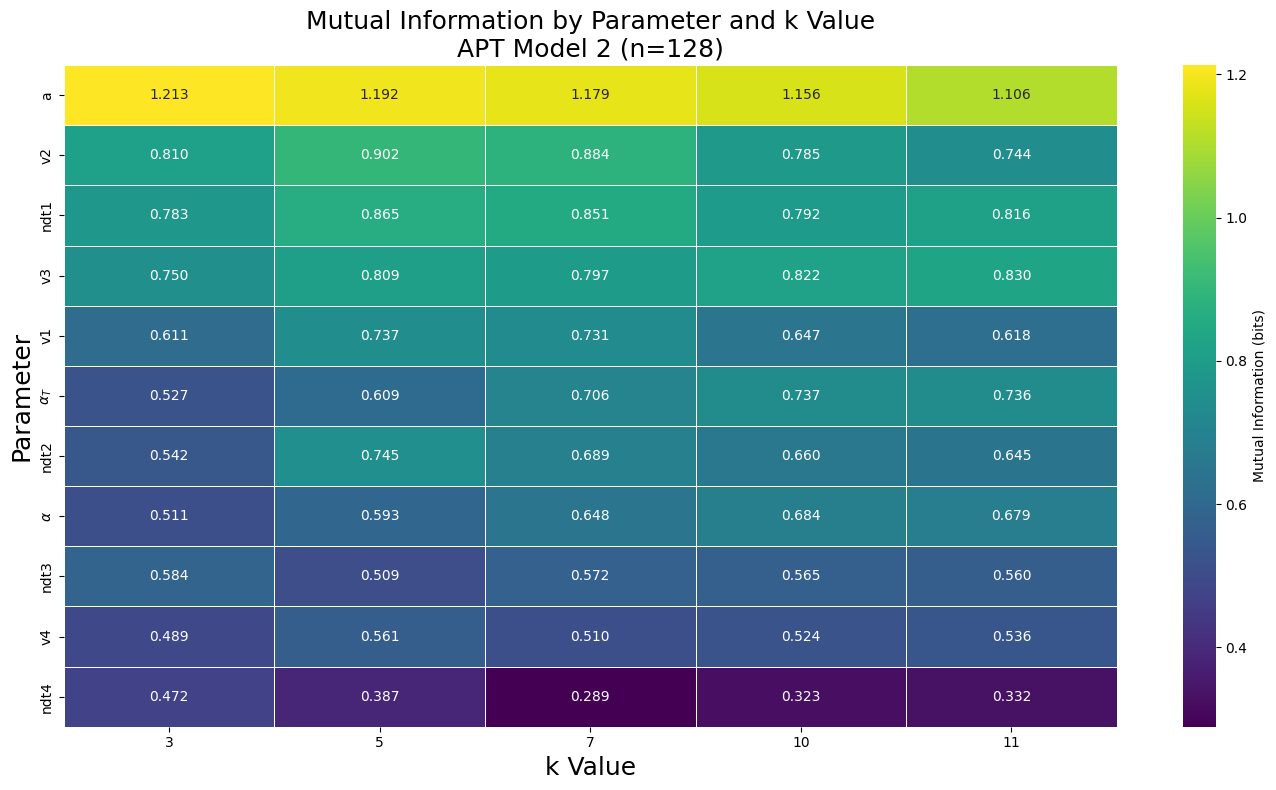

All analyses complete for APT Model 2. Results saved to results_APT_Model_2


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#plt.rcParams.update({'font.size': 16})  # 🔥 Add this line

from matplotlib.patches import Patch
from KSG_MI_First_reliability import KSGMutualInformationAnalyzer
from scipy import stats
import os

# Define the dataset name (modify this for different datasets)
Data_Name = "APT Model 2"

# Define paths to your data files
session1_path = 'Model2 APT/EZ_associative_learning_transformed_part_1.csv' # <--- CHANGE THIS
session2_path = 'Model2 APT/EZ_associative_learning_transformed_part_2.csv' # <--- CHANGE THIS

# Create a clean name for file paths (replace spaces with underscores)
file_name_prefix = Data_Name.replace(' ', '_')
# Create output directory
output_dir = f"results_{file_name_prefix}"
os.makedirs(output_dir, exist_ok=True)

# Read the CSV files
df1 = pd.read_csv(session1_path)
df2 = pd.read_csv(session2_path)

print(f"Analyzing dataset: {Data_Name}")
print("Dataset 1 shape:", df1.shape)
print("Dataset 2 shape:", df2.shape)

# List the parameters to analyze
parameters = [
    # Fallback if transformed not present
      'alpha_mean_boxcox_after_arcsin',
        'alpha_mean', # Fallback
        'v1_mean',
        'v2_mean',
        'v3_mean',
        'v4_mean',
        'zr_mean',
        'a_mean',
        'ndt1_mean',
        'ndt2_mean',
        'ndt3_mean',
        'ndt4_mean',
        # 'sndt_mean'
]

display_names = {
        'alpha_mean_boxcox_after_arcsin': r'$\alpha_T$',
        'alpha_mean': r'$\alpha$', # Fallback
        'v1_mean': 'v1',
        'v2_mean': 'v2',
        'v3_mean': 'v3',
        'v4_mean': 'v4',
        'zr_mean': 'zr',
        'a_mean': 'a',
        'ndt1_mean': 'ndt1',
        'ndt2_mean': 'ndt2',
        'ndt3_mean': 'ndt3',
        'ndt4_mean': 'ndt4',
        # 'sndt_mean': 'sndt'
    # Add other replacements if needed
}

# Function to apply display names
def get_display_name(param_name):
    return display_names.get(param_name, param_name)

# Find the common ID column
id_col = next((col for col in ['ID', 'participant', 'participant_ID' ] 
              if col in df1.columns and col in df2.columns), None)

print(f"Using identifier column: {id_col}")

# Create a new merged dataframe with only the columns we need
columns_to_keep1 = [id_col] + parameters
columns_to_keep2 = [id_col] + parameters

# Only keep columns that actually exist in the dataframes
columns_to_keep1 = [col for col in columns_to_keep1 if col in df1.columns]
columns_to_keep2 = [col for col in columns_to_keep2 if col in df2.columns]

# Create new dataframes with only needed columns
df1_subset = df1[columns_to_keep1].copy()
df2_subset = df2[columns_to_keep2].copy()

# Rename columns to add session suffix
for col in df1_subset.columns:
    if col != id_col:
        df1_subset = df1_subset.rename(columns={col: f"{col}_s1"})

for col in df2_subset.columns:
    if col != id_col:
        df2_subset = df2_subset.rename(columns={col: f"{col}_s2"})

# Merge the datasets
merged_df = pd.merge(df1_subset, df2_subset, on=id_col, how='inner')
print(f"Merged data shape: {merged_df.shape}")

# Define k values to analyze

# Calculate data-driven k (sqrt of sample size)
k_data_driven = int(np.sqrt(len(merged_df)))
k_values = [3, 5, 7, 10, k_data_driven]
#k_values = [3, 5, k_data_driven]


if k_data_driven not in k_values:
    k_values.append(k_data_driven)
    k_values.sort()
    
print(f"Using k values: {k_values} (data-driven k = {k_data_driven})")

# Initialize the analyzer
analyzer = KSGMutualInformationAnalyzer(merged_df)

# Create parameter pairs
param_pairs = []
for param in parameters:
    s1 = f"{param}_s1"
    s2 = f"{param}_s2"
    if s1 in merged_df.columns and s2 in merged_df.columns:
        param_pairs.append((s1, s2, param))
    else:
        if s1 not in merged_df.columns:
            print(f"Warning: {s1} not found in merged dataset")
        if s2 not in merged_df.columns:
            print(f"Warning: {s2} not found in merged dataset")

print(f"Found {len(param_pairs)} valid parameter pairs")

# Calculate MI across k values and correlation for each parameter
all_mi_results = {}
correlation_results = {}

for s1, s2, param_name in param_pairs:
    print(f"\nAnalyzing {param_name} across k values...")
    
    # Calculate MI for different k values
    mi_results = analyzer.analyze_across_k_values(
        param1=s1,
        param2=s2,
        k_values=k_values,
        n_permutations=1000  # Reduced for faster results
    )
    all_mi_results[param_name] = mi_results
    
    # Calculate correlation (Pearson's r)
    if s1 in merged_df.columns and s2 in merged_df.columns:
        x = merged_df[s1].values
        y = merged_df[s2].values
        
        # Skip if any NaN values
        if np.isnan(x).any() or np.isnan(y).any():
            print(f"Skipping correlation for {param_name} due to NaN values")
            continue
            
        r, p_value = stats.pearsonr(x, y)
        correlation_results[param_name] = {
            'r': r,
            'p_value': p_value,
            'r_squared': r**2  # R-squared value
        }
        
        print(f"Correlation for {param_name}: r = {r:.4f} (p={p_value:.4f}), R² = {r**2:.4f}")

# Create a detailed DataFrame with all MI values
mi_data = {}
for param_name, results in all_mi_results.items():
    mi_data[param_name] = {k: results[k]['mi'] for k in k_values if k in results}

# Convert to DataFrame
mi_df = pd.DataFrame(mi_data).T

# Add average MI column
mi_df['Average'] = mi_df.mean(axis=1)

# Create correlation DataFrame
corr_df = pd.DataFrame({
    'r': {k: v['r'] for k, v in correlation_results.items()},
    'p_value': {k: v['p_value'] for k, v in correlation_results.items()},
    'r_squared': {k: v['r_squared'] for k, v in correlation_results.items()}
})

# Sort DataFrames by their respective metrics
mi_df = mi_df.sort_values('Average', ascending=False)
corr_df = corr_df.sort_values('r', ascending=False)

# Find maximum values
max_avg_mi = mi_df['Average'].max()
max_corr = corr_df['r'].max()

# Calculate ratios to maximum
mi_df['Ratio to Max'] = mi_df['Average'] / max_avg_mi * 100
corr_df['Ratio to Max'] = corr_df['r'] / max_corr * 100

# Create a figure with two subplots side by side
plt.figure(figsize=(20, 10))

# Plot 1: MI bar chart (left)
plt.subplot(1, 2, 1)
mi_colors = sns.color_palette("viridis", len(mi_df))
mi_bars = plt.bar(range(len(mi_df)), mi_df['Average'], color=mi_colors)

# Add error bars showing standard deviation across k values
for i, param in enumerate(mi_df.index):
    std_dev = mi_df.loc[param, k_values].std()
    plt.errorbar(i, mi_df.loc[param, 'Average'], yerr=std_dev, 
                 fmt='none', color='black', capsize=5)

# Customize MI plot
plt.xlabel('Parameter', fontsize=18)
plt.ylabel('Average Mutual Information (bits)', fontsize=18)
plt.title(f'Average Mutual Information by Parameter\n{Data_Name} (n={len(merged_df)})', fontsize=18)
# Use display names for x-axis labels
plt.xticks(range(len(mi_df)), [get_display_name(param) for param in mi_df.index], rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Create MI legend
mi_legend_elements = []
mi_legend_labels = []

for i, param in enumerate(mi_df.index):
    avg = mi_df.loc[param, 'Average']
    ratio = mi_df.loc[param, 'Ratio to Max']
    
    # Create color patch for legend
    mi_legend_elements.append(Patch(facecolor=mi_colors[i], edgecolor='black', alpha=0.7))
    
    # Create label with display parameter name, MI value and percentage
    mi_legend_labels.append(f"{get_display_name(param)}: {avg:.3f} bits ({ratio:.1f}%)")

# Add MI legend
plt.legend(mi_legend_elements, mi_legend_labels, 
           title="Parameter: MI value (% of max)",
           loc='upper right',
           frameon=True,
           fontsize=18)

# Plot 2: Correlation bar chart (right)
plt.subplot(1, 2, 2)
corr_colors = sns.color_palette("magma", len(corr_df))
corr_bars = plt.bar(range(len(corr_df)), corr_df['r'], color=corr_colors)

# Customize correlation plot
plt.xlabel('Parameter', fontsize=18)
plt.ylabel('Pearson Correlation (r)', fontsize=18)
plt.title(f'Correlation by Parameter\n{Data_Name} (n={len(merged_df)})', fontsize=18)
# Use display names for x-axis labels
plt.xticks(range(len(corr_df)), [get_display_name(param) for param in corr_df.index], rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Create correlation legend
corr_legend_elements = []
corr_legend_labels = []

for i, param in enumerate(corr_df.index):
    r = corr_df.loc[param, 'r']
    r_squared = corr_df.loc[param, 'r_squared']
    ratio = corr_df.loc[param, 'Ratio to Max']
    sig = '*' if corr_df.loc[param, 'p_value'] < 0.05 else ''
    
    # Create color patch for legend
    corr_legend_elements.append(Patch(facecolor=corr_colors[i], edgecolor='black', alpha=0.7))
    
    # Create label with display parameter name, r value, R² and percentage
    corr_legend_labels.append(f"{get_display_name(param)}: r={r:.3f}{sig} (R²={r_squared:.3f}, {ratio:.1f}%)")

# Add correlation legend
plt.legend(corr_legend_elements, corr_legend_labels, 
           title="Parameter: r value (R², % of max)",
           loc='upper right',
           frameon=True,
           fontsize=18)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, f'{file_name_prefix}_mi_vs_correlation_comparison.png'), bbox_inches='tight')
plt.show()

# Create a comparison DataFrame with both MI and correlation
comparison_df = pd.DataFrame({
    'Average MI (bits)': mi_df['Average'],
    'MI Ratio (%)': mi_df['Ratio to Max'],
    'Correlation (r)': corr_df['r'],
    'R-squared': corr_df['r_squared'],
    'Corr Ratio (%)': corr_df['Ratio to Max'],
    'MI p-value': {param: all_mi_results[param][k_data_driven]['p_value'] 
                   if param in all_mi_results and k_data_driven in all_mi_results[param] 
                   else np.nan 
                   for param in mi_df.index},
    'Corr p-value': corr_df['p_value']
})

# Sort by MI descending
comparison_df = comparison_df.sort_values('Average MI (bits)', ascending=False)

# Display the comparison table
print(f"\nComparison of MI and Correlation for {Data_Name}:")
display(comparison_df)

# Export results to CSV
comparison_df.to_csv(os.path.join(output_dir, f'{file_name_prefix}_mi_and_correlation_comparison.csv'))
print(f"\nResults exported to {output_dir} directory")

# Create a scatter plot of MI vs correlation
plt.figure(figsize=(9, 6))

# Extract correlation and MI values
params = list(set(mi_df.index) & set(corr_df.index))
mi_values = [mi_df.loc[param, 'Average'] for param in params]
corr_values = [corr_df.loc[param, 'r'] for param in params]
colors = sns.color_palette("rainbow", len(params))

# Create scatter plot with parameter labels
plt.scatter(corr_values, mi_values, s=100, c=colors, alpha=0.7)

# Use display names for annotation labels
# for i, param in enumerate(params):
#     plt.annotate(get_display_name(param), (corr_values[i], mi_values[i]), 
#                  fontsize=18, ha='center', va='bottom',
#                  xytext=(0, 7), textcoords='offset points')


from matplotlib.patches import Patch
def get_display_name(param):
    return display_names.get(param, param)
# Create legend handles for parameters
param_legend_elements = [
    Patch(facecolor=colors[i], edgecolor='black', label=get_display_name(param))
    for i, param in enumerate(params)
]
# Add reference line for theoretical MI of Gaussian variables
r_range = np.linspace(0, 1, 100)
theoretical_mi = -0.5 * np.log(1 - r_range**2) / np.log(2)
plt.plot(r_range, theoretical_mi, 'k--', alpha=0.7, label='Theoretical MI for Gaussian')
# Second legend (parameter points)
plt.legend(handles=param_legend_elements,
           title="Parameters",
           loc='upper left',
           frameon=True,
           fontsize=12)

plt.xlabel('Pearson Correlation (r)', fontsize=18)
plt.ylabel('Average Mutual Information (bits)', fontsize=18)
plt.title(f'Mutual Information vs. Correlation by Parameter\n{Data_Name} (n={len(merged_df)})', fontsize=18)
plt.grid(True, alpha=0.3)
# plt.legend()

plt.tight_layout()
plt.savefig(os.path.join(output_dir, f'{file_name_prefix}_mi_vs_correlation_scatter.png'))
plt.show()

# Create line plot of MI across k values
plt.figure(figsize=(9, 6))

for param_name, results in all_mi_results.items():
    k_vals = list(results.keys())
    mi_vals = [results[k]['mi'] for k in k_vals]
    p_vals = [results[k]['p_value'] for k in k_vals]
    
    # Plot line with display parameter name
    line, = plt.plot(k_vals, mi_vals, marker='o', linewidth=2, markersize=8, label=get_display_name(param_name))
    
    # Mark significant points with filled markers
    for i, (k, p) in enumerate(zip(k_vals, p_vals)):
        if p < 0.05:
            plt.plot(k, mi_vals[i], marker='o', markersize=10, color=line.get_color(), markerfacecolor=line.get_color())
        else:
            plt.plot(k, mi_vals[i], marker='o', markersize=8, color=line.get_color(), markerfacecolor='white')

# Add data-driven k line
plt.axvline(x=k_data_driven, color='gray', linestyle='--', alpha=0.5)
plt.text(k_data_driven, plt.ylim()[1]*0.95, f'k_data = {k_data_driven}', 
         ha='center', va='top', rotation=90, alpha=0.7,
         bbox=dict(facecolor='white', alpha=0.5))

plt.xlabel('k (Number of Nearest Neighbors)', fontsize=18)
plt.ylabel('Mutual Information (bits)', fontsize=18)
plt.title(f'Mutual Information vs k Value by Parameter\n{Data_Name} (n={len(merged_df)})', fontsize=18)
plt.grid(True, alpha=0.3)
plt.legend(loc='best', fontsize=18)
plt.tight_layout()

# Save the plot
plt.savefig(os.path.join(output_dir, f'{file_name_prefix}_mi_vs_k_all_parameters.png'))
plt.show()

# Create a heatmap of MI values by k
plt.figure(figsize=(14, 8))
k_cols = [col for col in mi_df.columns if isinstance(col, (int, float))]

# Create a copy of the DataFrame with display names for the index
heatmap_df = mi_df[k_cols].copy()
heatmap_df.index = [get_display_name(param) for param in heatmap_df.index]

# Use the modified DataFrame for the heatmap
sns.heatmap(heatmap_df, annot=True, fmt='.3f', cmap='viridis', 
            linewidths=0.5, cbar_kws={'label': 'Mutual Information (bits)'})
plt.title(f'Mutual Information by Parameter and k Value\n{Data_Name} (n={len(merged_df)})', fontsize=18)
plt.xlabel('k Value', fontsize=18)
plt.ylabel('Parameter', fontsize=18)
plt.tight_layout()

# Save the heatmap
plt.savefig(os.path.join(output_dir, f'{file_name_prefix}_mi_heatmap_by_parameter.png'))
plt.show()

print(f"All analyses complete for {Data_Name}. Results saved to {output_dir}")
